# BirdSet probing results — XC + NASA soundscapes vs external baselines

Probing and finetuning on the 8 BirdSet downstream tasks. `POW` is the
conventional **validation** set: shown first, divided off in every plot, and
excluded from all test-set means.

**Backbones**

| backbone | pretraining |
| --- | --- |
| `AudioMAE (AS-2M)` | published AudioMAE, AudioSet-2M — external baseline, probed with its own 16 kHz fbank preprocessing |
| `Bird-MAE-Base` | published Bird-MAE-Base, XC — external baseline, probed with its own 32 kHz fbank preprocessing |
| `XC (400k)` | ours, XenoCanto only, 400k steps **from scratch** (`Pretrain-XC-400k`, `8l8fvpq3`) — the cold-start control, initialised like the 1M runs |
| `XC (400k, warm)` | the earlier 400k XC run, a **warm restart** from an earlier XC checkpoint (`Pretrain-XC-400kW`, `8wd545p2`). Superseded by the cold run above and kept for two reasons: it is the only 400k XC backbone with a *final-layer* probe (section 1), and warm-vs-cold is itself a row of the section-3 table |
| `XC (1M)` | ours, XenoCanto only, 1M steps, cold |
| `XC + NASA (400k)` | ours, XenoCanto + NASA soundscapes, 400k steps, cold — NASA stored as one fixed 5 s window per detection (`*_EVENTS_LOCAL`) |
| `XC + NASA v2 (400k)` | same curated granules, same mix weights, same 400k cold schedule — NASA stored as merged **detection regions** with a fresh random 5 s crop per access (`*_REGIONS_LOCAL`, `pretrain_xc_nasa_regions.yaml`). **Section 9** |
| `XC + NASA v2 50% (400k)` | the v2 region store at a **50/50** batch split instead of 75/25 (`pretrain_xc_nasa_regions_balanced.yaml`, `ii4317y5`) — a PAM-dose change on top of the windowing change, ~151 repeats of each distinct PAM window against v2's 76. Layerwise only, shown in **section 2** |
| `XC + NASA (1M)` | ours, events store, 1M steps, cold |
| `XC @{N}k`, `XC + NASA @{N}k` | intermediate checkpoints of the two 1M runs above — **section 5 only** |

The old A2O / Arbimon / NOAA-marine soundscape mixes are no longer used and are
not loaded here.

**Four heads, kept strictly separate.** The head is resolved from the logged
config — the pair (`module.model._target_`, `module.freeze_backbone`), because
the target alone no longer distinguishes them:

| head | target | encoder | what it reads |
| --- | --- | --- | --- |
| `final-layer` | `ViTProtoFloat` | frozen | cosine-prototype head on the last encoder block |
| `layerwise` | `ViTProtoLayerwise` | frozen | same head over a learned softmax-weighted sum of all 12 blocks |
| `linear` | `ViTClassifier` | frozen | a single `nn.Linear` on the CLS token |
| `finetune` | `ViTProtoFloat` | **trainable** | same head as `final-layer`, encoder unfrozen |
| `layerwise-finetune` | `ViTProtoLayerwise` | **trainable** | same head as `layerwise`, encoder unfrozen. **Section 10** |

Note the trap this replaces: each finetuning head shares its `_target_` with the
frozen probe it is built from, so resolving the head from the target alone
silently filed finetuning runs as frozen probes.

One more head is deliberately *not* in that table: the `layerwise` probe with
`PrototypicalFloat`'s `block_diagonal` mixer. It shares both its `_target_` and its
`freeze_backbone` with `layerwise` and differs only in `module.model.mixer`, so the
pair above cannot resolve it — its runs carry a `BD-` name prefix that keeps them out
of the loading cell entirely, so they are pulled in a cell of their own right after
the helpers below — **section 11** puts that probe next to the published SOTA and
**section 12** is the dense-vs-block-diagonal contrast.

The two 1M backbones were never probed `final-layer`, so they are absent from
section 1; the `linear`, `finetune` and `layerwise-finetune` heads were only ever
run **on those two backbones**, so sections 6–8 and 10–11 cover only them.

**Label spaces changed on 2026-08-20.** NES/PER/SNE were one class short
(88/131/55) because BirdSet's own GBIF linkage drops `runwre1`, `scbwoo5` and
`pasfly`; the configs now restore them, giving 89/132/56 — BirdSet's official
counts. Only the section-10 `layerwise-finetune` sweep and the three 400k
layerwise arms re-probed on 2026-08-19/20 ran under the repaired configs, so on
those three tasks a `layerwise-finetune` cell and a `layerwise` cell average cmAP
over *different class sets*. The audit at the bottom of the loading cell prints
the `data.num_classes` grid and warns where the eras are mixed; section 11 is
restricted to the repaired era for exactly this reason.

**Backbones are resolved by full checkpoint path, not basename.** The step sweep
introduced `outputs/XC-1M-steps/run/checkpoints/step_0400000.ckpt` and
`outputs/XC-NASA-1M-steps/…/step_0400000.ckpt`, whose basename collides with the
`XC (400k, warm)` backbone at `outputs/2026-07-01/…/step_0400000.ckpt` — three
different encoders, one basename.

**Seeds.** The two 1M-step layerwise cells have been probed with **two seeds**
(1 and 2); every other cell still has one (seed 1). Seeds are averaged into a
single number per (dataset, backbone, head), and the seed **min–max** is drawn as
a whisker — so bars and markers without a whisker are simply single-seed. Note
what this seed varies: the frozen backbone is byte-identical across the two runs,
so the spread is *probe-training* noise and is a lower bound on the real
run-to-run noise, not an estimate of pretraining variance.

**Ragged sweeps.** The step sweep (section 5) is mid-flight, and section 10's
sweep has one cell still running. Where a mean is taken across datasets, it is
restricted to the datasets that have a finished run for *every* series being
compared (`finished_everywhere`) — otherwise one backbone gets averaged over an
easier set of datasets than the other and the artefact reads as a real effect.

**Sections** — (1) final-layer baselines, (2) layerwise baselines,
(3) ablation: the full 2×2 of schedule (400k / 1M) × mix (XC / XC + NASA),
(4) learned layer-fusion weights — moved to `birdset_layer_weights_nasa.ipynb`,
(5) layerwise probing vs pretraining step,
(6) linear probing, (7) final-layer finetuning, (8) the heads side by side,
(9) NASA windowing: fixed 5 s events vs detection regions (`v2`),
(10) **layerwise finetuning** — the layerwise head with the encoder unfrozen,
(11) **our finetuning against the published state of the art** (Bird-MAE
fine-tuning, Perch 2.0) — plus the frozen block-diagonal probe,
(12) **the block-diagonal prototype mixer** — the constraint the full-XC release
head had to make, measured at BirdSet scale.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import wandb

In [2]:
# --- Pull probing results from W&B ---
# Run names are "{DATASET}-test_5s-{BACKBONE}-{SEED}[-{head}]", e.g.
# "HSN-test_5s-audiomae-1-layerwise". We nevertheless resolve everything from the
# logged CONFIG, not the name, because the config is the ground truth and survives
# any future renaming:
#   dataset  -> first token of the run name (the one thing only the name carries)
#   backbone -> the logged `trainer.resume_from_checkpoint`, matched as a FULL
#               repo-relative PATH, not a basename. This matters: the step sweep
#               added `outputs/XC-1M-steps/run/checkpoints/step_0400000.ckpt` and
#               `outputs/XC-NASA-1M-steps/.../step_0400000.ckpt`, whose basename
#               `step_0400000.ckpt` collides with the annealed 400k-schedule run
#               at `outputs/2026-07-01/.../step_0400000.ckpt`. Basename matching
#               silently folded three different encoders into `XC (400k)`.
#   head     -> (`module.model._target_`, `module.freeze_backbone`) -> HEADS. The
#               target alone is NOT enough any more: BOTH finetuning heads reuse a
#               probing head's `_target_` and differ only by the encoder being
#               trainable — `ViTProtoFloat` is shared with final-layer probing and
#               `ViTProtoLayerwise` with layerwise probing.
#   n_classes -> the logged `data.num_classes`, carried through purely as an AUDIT
#               field. The NES/PER/SNE label spaces were repaired on 2026-08-20
#               (88/131/55 -> 89/132/56, restoring `runwre1`/`scbwoo5`/`pasfly`,
#               which BirdSet's own GBIF linkage had dropped), so runs from before
#               and after that date score a DIFFERENT number of classes on those
#               three tasks and their cmAP is not strictly comparable. Nothing is
#               filtered on it; the audit at the bottom of this cell prints where
#               the eras disagree.
#   seed     -> the logged `seed`. EVERY seed is kept: the two 1M-step layerwise
#               cells have seeds 1 and 2, everything else has seed 1 only. Seeds
#               are averaged below and their min/max is carried through as an
#               error bar.
# Any checkpoint not resolved is ignored, which is what drops the retired
# A2O/Arbimon ("terrestrial") and NOAA ("marine") mixes, the short XC.ckpt run,
# and the one-off step_0280000/step_0360000 probes.
ENTITY = "mwirth"
PROJECT = "soundscape_ssl"

XC_400K = "XC (400k)"                    # cold start, 400k from scratch
XC_400K_WARM = "XC (400k, warm)"         # the superseded warm restart
XC_1M = "XC (1M)"
XC_NASA_400K = "XC + NASA (400k)"        # NASA = fixed 5 s events store
XC_NASA_400K_V2 = "XC + NASA v2 (400k)"  # NASA = region store + random crop
XC_NASA_400K_V2_50 = "XC + NASA v2 50% (400k)"  # same store, 50% PAM weight
XC_NASA_1M = "XC + NASA (1M)"
AUDIOMAE = "AudioMAE (AS-2M)"
BIRDMAE = "Bird-MAE-Base"
PAPER = "Bird-MAE-Base (paper)"

REPO = "/home/moritz_earthspecies_org/soundscape_mae/"

# Full repo-relative checkpoint path -> backbone.
#
# TWO 400k XC backbones exist and they are NOT the same run:
#   XC_400k_cold.ckpt  `Pretrain-XC-400k` (8l8fvpq3) — 400k FROM SCRATCH. This is
#                      `XC (400k)` everywhere below, because it is initialised the
#                      same way as the two 1M runs: it makes the section-3 2x2 a
#                      pure schedule x mix grid and the section-5 dotted 400k
#                      reference an LR-schedule contrast. Layerwise only.
#   XC_long.ckpt       `Pretrain-XC-400kW` (8wd545p2) — a WARM RESTART from an
#                      earlier XC checkpoint; this is what `XC (400k)` used to mean.
#                      Kept as `XC (400k, warm)`: it is the only 400k XC backbone
#                      with a final-layer probe (section 1), and warm-vs-cold is a
#                      row of the section-3 decomposition. Reachable by two paths
#                      that both appear in run configs (the raw outputs/... one and
#                      the copy under checkpoints/), so both are listed.
# The NASA mix has THREE 400k arms over the same curated soundscape: the fixed 5 s
# event store, the merged region store + random crop (`v2`, the windowing change —
# section 9), and that same region store at a 50/50 rather than 75/25 batch split
# (`pretrain_xc_nasa_regions_balanced.yaml`), which is a PAM-dose change on top of
# it: 25% -> 50% weight, so ~151 repeats of each distinct PAM window instead of 76.
CKPT_TO_BACKBONE = {
    "checkpoints/XC_400k_cold.ckpt": XC_400K,             # cold, from scratch
    "outputs/2026-07-01/09-53-05/checkpoints/step_0400000.ckpt": XC_400K_WARM,
    "checkpoints/XC_long.ckpt": XC_400K_WARM,             # same encoder, copied
    "checkpoints/XC_1M.ckpt": XC_1M,
    "checkpoints/XC_nasa_400k.ckpt": XC_NASA_400K,        # fixed 5 s event store
    "checkpoints/XC_nasa_400k_v2.ckpt": XC_NASA_400K_V2,  # region store, random crop
    "checkpoints/XC_nasa_50_400k.ckpt": XC_NASA_400K_V2_50,  # region store, 50/50 mix
    "checkpoints/XC_nasa_1M.ckpt": XC_NASA_1M,
    "checkpoints/audiomae.ckpt": AUDIOMAE,      # scripts/convert_external_ckpt.py
    "checkpoints/birdmae_base.ckpt": BIRDMAE,
}

# The step sweep probes intermediate checkpoints of the two 1M-step PRETRAINING
# runs, so a run directory identifies the data mix and the filename the step. The
# 1M endpoints (XC_1M.ckpt / XC_nasa_1M.ckpt) are the annealed final checkpoints
# of these same two runs, which is what lets section 5 close each curve at 1M.
XC_MIX = "XC"
XC_NASA_MIX = "XC + NASA"
STEP_RUN_DIRS = {
    "outputs/XC-1M-steps/run": XC_MIX,
    "outputs/XC-NASA-1M-steps/11-08-27": XC_NASA_MIX,
}
_STEP_RE = re.compile(r"^(?P<run>.*)/checkpoints/step_(?P<step>\d+)\.ckpt$")

MIXES = [XC_MIX, XC_NASA_MIX]
MIX_ENDPOINT = {XC_MIX: XC_1M, XC_NASA_MIX: XC_NASA_1M}       # step 1M, annealed
MIX_ANNEALED_400K = {XC_MIX: XC_400K, XC_NASA_MIX: XC_NASA_400K}  # separate run

# (model target, freeze_backbone) -> head. `birdset_eval.py` freezes unless
# `module.freeze_backbone` is explicitly false, so the default here is True.
HEADS = {
    ("soundscape_ssl.models.ViTProtoFloat", True): "final-layer",
    ("soundscape_ssl.models.ViTProtoLayerwise", True): "layerwise",
    ("soundscape_ssl.models.ViTClassifier", True): "linear",
    ("soundscape_ssl.models.ViTProtoFloat", False): "finetune",
    # section 10: the layerwise head with the encoder unfrozen
    # (`sweeps/finetune/birdset/vit_layerwise.yaml`).
    ("soundscape_ssl.models.ViTProtoLayerwise", False): "layerwise-finetune",
}

# logged summary key -> short metric name used throughout the notebook
METRIC_KEYS = {
    "test/MultilabelAveragePrecision": "cmAP",
    "test/MultilabelAUROC": "AUROC",
    "test/TopKAccuracy": "T1",
}
METRICS = list(METRIC_KEYS.values())

VAL_DATASETS = ["POW"]          # validation set -> excluded from the means
TEST_DATASETS = ["HSN", "NBP", "NES", "PER", "SNE", "SSW", "UHH"]
DATASETS = VAL_DATASETS + TEST_DATASETS


def _resolve_ckpt(ckpt):
    """(backbone, family, step) for a logged checkpoint path, or (None, None, nan).

    family "backbone" = one of the seven fixed encoders above (`step` is nan);
    family "step"     = an intermediate checkpoint of a 1M pretraining run, named
                        "{mix} @{step}k" and carrying its integer `step`.
    """
    rel = ckpt.replace(REPO, "")
    if rel in CKPT_TO_BACKBONE:
        return CKPT_TO_BACKBONE[rel], "backbone", np.nan
    m = _STEP_RE.match(rel)
    if m and m.group("run") in STEP_RUN_DIRS:
        step = int(m.group("step"))
        return f"{STEP_RUN_DIRS[m.group('run')]} @{step // 1000}k", "step", step
    return None, None, np.nan


api = wandb.Api()

raw = []
for run in api.runs(f"{ENTITY}/{PROJECT}"):
    parts = (run.name or "").split("-")
    if len(parts) < 4 or parts[1] != "test_5s" or parts[0] not in DATASETS:
        continue
    cfg = run.config
    ckpt = (cfg.get("trainer", {}) or {}).get("resume_from_checkpoint") or ""
    backbone, family, step = _resolve_ckpt(ckpt)
    module = cfg.get("module", {}) or {}
    head = HEADS.get(((module.get("model", {}) or {}).get("_target_"),
                      bool(module.get("freeze_backbone", True))))
    if backbone is None or head is None or cfg.get("seed") is None:
        continue
    rec = {"dataset": parts[0], "backbone": backbone, "family": family, "step": step,
           "probing": head, "seed": cfg["seed"], "state": run.state,
           "n_classes": (cfg.get("data", {}) or {}).get("num_classes"),
           "created": pd.to_datetime(run.created_at, utc=True), "run_id": run.id}
    rec.update({short: run.summary.get(key, np.nan) for key, short in METRIC_KEYS.items()})
    raw.append(rec)

raw_df = pd.DataFrame(raw)

# Step 1 — collapse to ONE run per (dataset, backbone, probing, SEED): prefer the
# most recent *finished* run; if none finished, keep the most recent run of any
# state so its status (e.g. running / crashed) stays visible instead of silently
# disappearing. This is what de-duplicates repeated evaluation batches. The seed is
# part of the key, so a genuine second seed is a new row, not a duplicate.
_d = raw_df.assign(_finished=(raw_df["state"] == "finished").astype(int))
runs_df = (_d.sort_values(["_finished", "created"])
             .drop_duplicates(["dataset", "backbone", "probing", "seed"], keep="last")
             .drop(columns="_finished")
             .sort_values(["probing", "backbone", "dataset", "seed"])
             .reset_index(drop=True))


def _cell_state(states):
    """A cell is finished only if every seed finished; else surface the odd one."""
    states = list(states)
    return ("finished" if all(s == "finished" for s in states)
            else next(s for s in states if s != "finished"))


# Step 2 — average over seeds -> ONE row per (dataset, backbone, probing). The
# per-metric min/max across seeds is kept as `{metric}_lo` / `{metric}_hi` and
# becomes the error bar in the plots; for single-seed cells lo == mean == hi, so
# those simply render without a bar.
_agg = {m: (m, "mean") for m in METRICS}
_agg.update({f"{m}_lo": (m, "min") for m in METRICS})
_agg.update({f"{m}_hi": (m, "max") for m in METRICS})
_agg.update(n_seeds=("seed", "nunique"), seeds=("seed", lambda s: sorted(s)),
            state=("state", _cell_state), run_ids=("run_id", list),
            family=("family", "first"), step=("step", "first"),
            n_classes=("n_classes", "first"))

collapsed = (runs_df.groupby(["dataset", "backbone", "probing"], as_index=False)
                    .agg(**_agg)
                    .sort_values(["probing", "backbone", "dataset"])
                    .reset_index(drop=True))

# One frame per head. The step sweep is layerwise but lives in its own frame so it
# cannot leak into the backbone-level layerwise plots (and so its 20-odd synthetic
# backbones don't flood the coverage audit below).
_backbone_level = collapsed[collapsed["family"] == "backbone"]
final_df = _backbone_level[_backbone_level["probing"] == "final-layer"].reset_index(drop=True)
layerwise_df = _backbone_level[_backbone_level["probing"] == "layerwise"].reset_index(drop=True)
linear_df = _backbone_level[_backbone_level["probing"] == "linear"].reset_index(drop=True)
finetune_df = _backbone_level[_backbone_level["probing"] == "finetune"].reset_index(drop=True)
lw_finetune_df = _backbone_level[
    _backbone_level["probing"] == "layerwise-finetune"].reset_index(drop=True)
step_df = collapsed[collapsed["family"] == "step"].reset_index(drop=True)

HEAD_FRAMES = {"final-layer": final_df, "layerwise": layerwise_df,
               "linear": linear_df, "finetune": finetune_df,
               "layerwise-finetune": lw_finetune_df}

print(f"{len(raw_df)} runs fetched -> {len(runs_df)} deduped -> {len(collapsed)} "
      f"(dataset, backbone, probing) cells\n")
print(collapsed.groupby(["probing", "family", "backbone"])
               .agg(n_datasets=("dataset", "size"),
                    seeds=("seeds", lambda s: sorted({x for lst in s for x in lst})),
                    states=("state", lambda s: sorted(set(s)))).to_string())

# Audit: kept-but-unfinished runs, missing (dataset, backbone) combos, and cells
# whose seed count is not constant across datasets (a half-finished seed sweep,
# which would make the per-dataset means silently incomparable).
for label, df in HEAD_FRAMES.items():
    if not len(df):
        print(f"\nNOTE — no {label} runs found.")
        continue
    unfinished = df.loc[df["state"] != "finished", ["dataset", "backbone", "state"]]
    if len(unfinished):
        print(f"\nWARNING — {label} cells kept that are not finished:")
        print(unfinished.to_string(index=False))
    missing = {(d, b) for d in DATASETS for b in df["backbone"].unique()} - set(
        zip(df["dataset"], df["backbone"]))
    if missing:
        print(f"\nMISSING {label} runs ({len(missing)}):", sorted(missing))
    ragged = df.groupby("backbone")["n_seeds"].nunique()
    ragged = ragged[ragged > 1]
    if len(ragged):
        print(f"\nWARNING — {label} backbones with an uneven number of seeds "
              f"across datasets: {list(ragged.index)}")
        print(df[df["backbone"].isin(ragged.index)]
              .pivot_table(index="dataset", columns="backbone", values="n_seeds").to_string())

# The step sweep is a (step x dataset) grid per mix rather than a set of backbones,
# so it gets its own coverage readout instead of the cross-product above: the two
# mixes were probed on DIFFERENT step grids, and only some datasets are done.
if len(step_df):
    _cov = step_df.assign(mix=step_df["backbone"].str.split(" @").str[0])
    print("\nstep-sweep coverage (state per step x dataset):")
    print(_cov.pivot_table(index="step", columns=["mix", "dataset"], values="state",
                           aggfunc="first").fillna("—").to_string())


# Label-space audit. `data.num_classes` is the runtime class count W&B logged, and
# it is the one thing that can differ between two runs which otherwise look
# identical: NES/PER/SNE were repaired from 88/131/55 to 89/132/56 on 2026-08-20.
# A dataset whose heads disagree here has a cmAP column that averages over
# different class sets, which is a silent apples-to-oranges — hence a warning
# rather than a filter, since the affected runs are still the only ones that exist.
OFFICIAL_N_CLASSES = {"HSN": 21, "POW": 48, "PER": 132, "NES": 89,
                      "UHH": 27, "NBP": 51, "SSW": 81, "SNE": 56}
_lab = (collapsed[collapsed["family"] == "backbone"]
        .pivot_table(index="dataset", columns="probing", values="n_classes",
                     aggfunc="first")
        .reindex(DATASETS))
_lab["OFFICIAL"] = pd.Series(OFFICIAL_N_CLASSES)
print("\nlogged data.num_classes per (dataset, head) vs BirdSet's official count:")
print(_lab.to_string())
_split = [d for d in DATASETS
          if _lab.drop(columns="OFFICIAL").loc[d].dropna().nunique() > 1]
if _split:
    print(f"\nWARNING — label-space eras MIXED on {_split}: the heads above do not "
          f"all score\nthe same number of classes, so their cmAP columns are not "
          f"strictly comparable\non those tasks (see the 2026-08-20 NES/PER/SNE "
          f"repair).")


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/moritz_earthspecies_org/.netrc.


220 runs fetched -> 210 deduped -> 194 (dataset, backbone, probing) cells

                                                     n_datasets   seeds               states
probing            family   backbone                                                        
final-layer        backbone AudioMAE (AS-2M)                  8     [1]           [finished]
                            Bird-MAE-Base                     8     [1]           [finished]
                            XC (400k, warm)                   8     [1]           [finished]
                            XC + NASA (400k)                  8     [1]           [finished]
finetune           backbone XC (1M)                           8     [1]           [finished]
                            XC + NASA (1M)                    8     [1]           [finished]
layerwise          backbone AudioMAE (AS-2M)                  8     [1]           [finished]
                            Bird-MAE-Base                     8     [1]           [finis

In [3]:
# --- Reference numbers, colors, and the shared table/plot helpers ---
# Bird-MAE paper (published prototypical-probing numbers for Bird-MAE-Base). Their
# proto head is a full PPNet and ours is a simplified cosine variant, so treat
# these as a band, not a target. The paper lists two ViT-B/16 rows; this is the
# lower (frozen) one. Shown as a GREY reference series in the final-layer section
# only (their probe is a final-layer probe): it is a published-number reference,
# not one of our backbone baselines, so it stays out of BASELINES.
paper_cmAP = {"HSN": 0.44, "NBP": 0.63, "NES": 0.28, "PER": 0.21, "POW": 0.38, "SNE": 0.22, "SSW": 0.23, "UHH": 0.26}
paper_auroc = {"HSN": 0.89, "NBP": 0.92, "NES": 0.92, "PER": 0.79, "POW": 0.85, "SNE": 0.84, "SSW": 0.94, "UHH": 0.92}
paper_t1 = {"HSN": 0.37, "NBP": 0.65, "NES": 0.41, "PER": 0.49, "POW": 0.74, "SNE": 0.35, "SSW": 0.49, "UHH": 0.32}
_paper = {"cmAP": paper_cmAP, "AUROC": paper_auroc, "T1": paper_t1}
# lo == hi == the value, so the paper series flows through the same seed-range
# plumbing as our runs and simply draws no error bar.
paper_df = pd.DataFrame([
    {"dataset": ds, "backbone": PAPER, "state": "reference", "n_seeds": 1,
     **{m: v[ds] for m, v in _paper.items()},
     **{f"{m}_lo": v[ds] for m, v in _paper.items()},
     **{f"{m}_hi": v[ds] for m, v in _paper.items()}}
    for ds in DATASETS
])

# --- Published FINE-TUNING state of the art on BirdSet (sections 10-11) ---
# Two papers, two very different protocols, both evaluated on BirdSet's own
# `{TASK}-test_5s` splits, which is also the split our runs test on — so the test
# side of the comparison is like-for-like and the metric definitions match
# (torchmetrics macro `MultilabelAveragePrecision` / `MultilabelAUROC`).
#
# Bird-MAE (arXiv:2504.12880), Table 6 for MAP% (== cmAP) and Table 11 for
# AUROC / T1-Acc: ViT-B/16 and ViT-L/16 MAEs pretrained on XCL-1.7M and then FULLY
# FINE-TUNED per task. `Bird-MAE-B (FT)` is the size- and data-matched reference
# for us: same architecture (ViT-B/16, 86M), same pretraining source (Xeno-Canto),
# same objective family (MAE). `Bird-MAE-L (FT)` is the paper's headline SOTA at
# 307M. Their AUROC/T1 are only published to 2 decimals.
#
# Perch 2.0 (arXiv:2508.04665), Table 4, the `Random` variant (the best of its
# three on all three metrics; `Phase I` and `Peak-select` are within 0.001 cmAP).
# NOT a fine-tune: "we forgo fine-tuning and simply use the predictions of our
# prototype learning classifier directly", i.e. a supervised EfficientNet-B3
# trained on XC + iNat + Tierstimmenarchiv + FSD50K with a pretrained head applied
# to BirdSet as-is. It is in this section because it is the number to beat on
# BirdSet, not because it is a comparable training protocol.
#
# Two asymmetries to keep in view when reading these rows:
#   * POW is Perch 2.0's VALIDATION set, so its Table 4 has no POW column — the
#     POW cell is NaN and draws an "x". Its published means are over exactly our
#     seven TEST_DATASETS, which is what `summary()` computes for us too.
#   * HSN is Bird-MAE's validation set (their tables write it HSN_val) and they
#     tuned hyperparameters on it, while for us and for Perch 2.0 it is a test set.
BIRDMAE_B_FT = "Bird-MAE-B (paper, FT)"
BIRDMAE_L_FT = "Bird-MAE-L (paper, FT)"
PERCH2 = "Perch 2.0 (paper, pretrained head)"

# Bird-MAE Table 6 (MAP%, 2 dp) -> cmAP; Table 11 (AUROC, T1-Acc, 2 dp).
_FT_SOTA = {
    BIRDMAE_B_FT: {
        "cmAP":  {"HSN": .5206, "POW": .4524, "PER": .2758, "NES": .3712,
                  "UHH": .2848, "NBP": .6286, "SSW": .3283, "SNE": .2804},
        "AUROC": {"HSN": .86, "POW": .86, "PER": .77, "NES": .90,
                  "UHH": .81, "NBP": .91, "SSW": .88, "SNE": .83},
        "T1":    {"HSN": .58, "POW": .83, "PER": .54, "NES": .47,
                  "UHH": .41, "NBP": .66, "SSW": .62, "SNE": .52}},
    BIRDMAE_L_FT: {
        "cmAP":  {"HSN": .5528, "POW": .5526, "PER": .3464, "NES": .4150,
                  "UHH": .3017, "NBP": .7169, "SSW": .4082, "SNE": .3382},
        "AUROC": {"HSN": .90, "POW": .90, "PER": .82, "NES": .91,
                  "UHH": .82, "NBP": .94, "SSW": .93, "SNE": .88},
        "T1":    {"HSN": .64, "POW": .91, "PER": .60, "NES": .52,
                  "UHH": .42, "NBP": .72, "SSW": .70, "SNE": .61}},
    # Perch 2.0 Table 4, `Perch 2.0 - Random`. POW absent (their val set).
    PERCH2: {
        "cmAP":  {"HSN": .533, "POW": np.nan, "PER": .232, "NES": .403,
                  "UHH": .380, "NBP": .661, "SSW": .469, "SNE": .341},
        "AUROC": {"HSN": .915, "POW": np.nan, "PER": .786, "NES": .953,
                  "UHH": .912, "NBP": .933, "SSW": .973, "SNE": .883},
        "T1":    {"HSN": .659, "POW": np.nan, "PER": .535, "NES": .562,
                  "UHH": .595, "NBP": .724, "SSW": .789, "SNE": .791}},
}
# Same shape as `paper_df`: lo == hi == the value, so published rows flow through
# the seed-range plumbing untouched and draw no error bar.
sota_df = pd.DataFrame([
    {"dataset": ds, "backbone": name, "state": "reference", "n_seeds": 1,
     **{m: mv[ds] for m, mv in metrics.items()},
     **{f"{m}_lo": mv[ds] for m, mv in metrics.items()},
     **{f"{m}_hi": mv[ds] for m, mv in metrics.items()}}
    for name, metrics in _FT_SOTA.items() for ds in DATASETS
])
FT_SOTA_SERIES = [BIRDMAE_B_FT, BIRDMAE_L_FT, PERCH2]

# externals first (reference), then ours. The LAYERWISE baselines use the
# cold-start `XC (400k)`; the final-layer section has to use the warm one, which is
# the only 400k XC backbone that was ever probed final-layer, so the two sections
# do not share a series list any more.
BASELINES = [AUDIOMAE, BIRDMAE, XC_400K, XC_NASA_400K]
# The layerwise panel also carries the two region-store NASA arms — `v2` at the
# same 25% PAM weight as the event store, and `v2 50%` at double that weight — so
# all three NASA arms sit side by side against the same baselines. Both are
# layerwise-only, which is why they cannot join FINAL_BACKBONES. Section 9 keeps
# the narrower windowing contrast and its decomposition rows.
LW_BASELINES = BASELINES + [XC_NASA_400K_V2, XC_NASA_400K_V2_50]
FINAL_BACKBONES = [PAPER, AUDIOMAE, BIRDMAE, XC_400K_WARM, XC_NASA_400K]
# section 3 is a 2x2: {XC, XC + NASA} x {400k, 1M}, ordered mix-major. All four
# cells are cold-start runs, so the schedule rows are schedule rows.
ABLATION = [XC_400K, XC_1M, XC_NASA_400K, XC_NASA_1M]
# section 9: the three NASA soundscape arms — two windowings at 25 % PAM weight and
# the region store at 50 % — against the XC-only control of equal length
WINDOWING = [XC_400K, XC_NASA_400K, XC_NASA_400K_V2, XC_NASA_400K_V2_50]

COLORS = {
    PAPER: "#888888",   # grey = published reference, not a run of ours
    AUDIOMAE: "#ff7f0e",
    BIRDMAE: "#2ca02c",
    XC_400K: "#9467bd",     # hue = data mix, dark shade = the 1M schedule,
    XC_1M: "#54278f",       # so the section-3 2x2 reads off the colors
    XC_400K_WARM: "#bcbddc",     # pale XC hue = the superseded warm restart
    XC_NASA_400K: "#5BC5DB",
    XC_NASA_400K_V2: "#e377c2",  # own hue: a different NASA store, not a shade of it
    XC_NASA_400K_V2_50: "#a1348a",  # dark shade of it = that store at 2x the weight
    XC_NASA_1M: "#1b7f9e",
    # published references: greys, like PAPER, so they never read as a run of ours
    BIRDMAE_B_FT: "#b0b0b0",
    BIRDMAE_L_FT: "#6e6e6e",
    PERCH2: "#3a3a3a",
}
FINISHED = {"finished", "reference"}
DIVIDER = len(VAL_DATASETS) - 0.5   # boundary between validation (POW) and test sets


def tables(df, backbones):
    """(metric -> wide table of the seed MEAN, state table, metric -> (lo, hi) seed
    min/max tables); rows = DATASETS, cols = backbones. Single-seed cells have
    lo == mean == hi, so they contribute a zero-width error bar."""
    def _wide(col, aggfunc="mean"):
        return (df.pivot_table(index="dataset", columns="backbone", values=col,
                               aggfunc=aggfunc)
                  .reindex(index=DATASETS, columns=backbones))
    metric_tables = {m: _wide(m) for m in METRICS}
    states = _wide("state", "first")
    ranges = {m: (_wide(f"{m}_lo", "min"), _wide(f"{m}_hi", "max")) for m in METRICS}
    return metric_tables, states, ranges


def summary(metric_tables, label):
    """Test-set means (POW excluded) for every metric, as one tidy frame."""
    out = pd.DataFrame({m: metric_tables[m].loc[TEST_DATASETS].mean() for m in METRICS})
    out.index.name = f"{label} (test-set mean, POW excluded)"
    return out.round(4)


def _seed_err(ranges, metric, backbone, vals):
    """Asymmetric yerr (mean-lo, hi-mean) = the seed min/max range around the seed
    mean. None when the backbone is single-seed everywhere, so matplotlib is not
    asked to draw invisible zero-length bars."""
    lo, hi = ranges[metric]
    err = np.nan_to_num(np.vstack([vals - lo[backbone].values,
                                   hi[backbone].values - vals]))
    return err if err.max() > 0 else None


def _has_seed_range(metric_tables, ranges, metric, backbones):
    return any(_seed_err(ranges, metric, b, metric_tables[metric][b].values) is not None
               for b in backbones)


def _finish_axis(ax, metric, title):
    ax.axvspan(-0.5, DIVIDER, color="black", alpha=0.05, zorder=0)
    ax.axvline(DIVIDER, color="black", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_xticks(np.arange(len(DATASETS)))
    ax.set_xticklabels([f"{d}\n(val)" if d in VAL_DATASETS else d for d in DATASETS])
    ax.set_ylabel(metric)
    ax.set_title(f"{title} — {metric}")


def bar_plot(metric_tables, states, ranges, backbones, title):
    """One subplot per metric. Bar height = mean over seeds; black whisker = seed
    min/max (absent where a cell has one seed); bar color = backbone; RED edge =
    run not finished; "x" at the baseline = no run for that (dataset, backbone)."""
    fig, axes = plt.subplots(len(METRICS), 1, figsize=(14, 4.5 * len(METRICS)))
    x = np.arange(len(DATASETS))
    width = 0.8 / len(backbones)
    for ax, metric in zip(axes, METRICS):
        for i, backbone in enumerate(backbones):
            offset = (i - (len(backbones) - 1) / 2) * width
            vals = metric_tables[metric][backbone].values
            bars = ax.bar(x + offset, vals, width, color=COLORS[backbone], linewidth=0.8,
                          yerr=_seed_err(ranges, metric, backbone, vals),
                          error_kw=dict(ecolor="black", elinewidth=1.0, capsize=2))
            for bar, s in zip(bars, states[backbone].values):
                bar.set_edgecolor("red" if s not in FINISHED else "black")
            for xi, v in enumerate(vals):
                if np.isnan(v):
                    ax.text(xi + offset, 0, "x", ha="center", va="bottom",
                            color=COLORS[backbone], fontsize=9, fontweight="bold")
        _finish_axis(ax, metric, title)
        ax.grid(axis="y", alpha=0.3)
        handles = [Patch(facecolor=COLORS[b], edgecolor="black", label=b) for b in backbones]
        handles.append(Patch(facecolor="white", edgecolor="red", label="running / crashed"))
        if _has_seed_range(metric_tables, ranges, metric, backbones):
            handles.append(Line2D([0], [0], color="black", marker="_", linestyle="-",
                                  label="seed min–max"))
        ax.legend(handles=handles, fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()


# --- Extra scales & helpers for the step sweep and the head comparison ---
# Step-sweep curves are colored by their PRETRAINING RUN, i.e. the same dark shade
# as that run's annealed 1M endpoint, because the intermediates and the endpoint
# come out of one run.
MIX_COLORS = {XC_MIX: COLORS[XC_1M], XC_NASA_MIX: COLORS[XC_NASA_1M]}

# Heads get their own scale, ordered weakest-to-richest readout of the encoder:
# a single linear layer on CLS, a prototype head on the last block, the same head
# over a learned mix of all 12 blocks, and then each of those two prototype heads
# again with the encoder unfrozen. Only the last two change the encoder, and they
# are the same two frozen heads plus `freeze_backbone: false` — so `finetune` pairs
# with `final-layer` and `layerwise-finetune` pairs with `layerwise`.
HEAD_ORDER = ["linear", "final-layer", "layerwise", "finetune", "layerwise-finetune"]
HEAD_COLORS = {"linear": "#c6dbef", "final-layer": "#6baed6",
               "layerwise": "#2171b5", "finetune": "#d62728",
               "layerwise-finetune": "#7f0d0d"}

ENDPOINT_STEP = 1_000_000   # where the annealed 1M checkpoint sits on the step axis


def finished_everywhere(backbones, heads, datasets=TEST_DATASETS):
    """The datasets on which EVERY (backbone, head) pair has a *finished* run.

    Any mean taken over a wider set is not apples-to-apples: the finetuning sweep
    is mid-flight, so `df.mean()` would silently average one backbone over more
    datasets than the other and read as a backbone effect."""
    ok = collapsed[(collapsed["family"] == "backbone")
                   & collapsed["state"].isin(FINISHED)
                   & collapsed["backbone"].isin(backbones)
                   & collapsed["probing"].isin(heads)]
    n = ok.groupby("dataset").size()
    return [d for d in datasets if n.get(d, 0) == len(backbones) * len(heads)]


def heads_present(backbones):
    """The heads in HEAD_ORDER that were actually run on any of these backbones.
    The 1M backbones were never probed final-layer, so that column is dropped
    rather than drawn as a row of empty slots."""
    have = set(collapsed[(collapsed["family"] == "backbone")
                         & collapsed["backbone"].isin(backbones)]["probing"])
    return [h for h in HEAD_ORDER if h in have]


def head_tables(backbones, heads=HEAD_ORDER):
    """(metric -> dataset x (backbone, head) table of seed means, state table).

    Columns are the full product, so a head that was never run on a dataset is an
    explicit NaN rather than a missing column."""
    sub = collapsed[(collapsed["family"] == "backbone")
                    & collapsed["backbone"].isin(backbones)
                    & collapsed["probing"].isin(heads)]
    cols = pd.MultiIndex.from_product([backbones, heads], names=["backbone", "probing"])

    def _wide(col, aggfunc="mean"):
        return (sub.pivot_table(index="dataset", columns=["backbone", "probing"],
                                values=col, aggfunc=aggfunc)
                   .reindex(index=DATASETS, columns=cols))
    return {m: _wide(m) for m in METRICS}, _wide("state", "first")


def head_plot(backbones, metric="cmAP", heads=HEAD_ORDER):
    """One subplot per backbone; grouped bars = the probing heads on that encoder.
    RED edge = run not finished, "x" at the baseline = no run for that cell."""
    tabs, states = head_tables(backbones, heads)
    fig, axes = plt.subplots(len(backbones), 1, figsize=(14, 4.5 * len(backbones)),
                             squeeze=False)
    x = np.arange(len(DATASETS))
    width = 0.8 / len(heads)
    for ax, backbone in zip(axes[:, 0], backbones):
        for i, head in enumerate(heads):
            offset = (i - (len(heads) - 1) / 2) * width
            vals = tabs[metric][(backbone, head)].values
            bars = ax.bar(x + offset, vals, width, color=HEAD_COLORS[head], linewidth=0.8)
            for bar, s in zip(bars, states[(backbone, head)].values):
                bar.set_edgecolor("black" if s in FINISHED else "red")
            for xi, v in enumerate(vals):
                if np.isnan(v):
                    ax.text(xi + offset, 0, "x", ha="center", va="bottom",
                            color=HEAD_COLORS[head], fontsize=9, fontweight="bold")
        _finish_axis(ax, metric, f"{backbone} — probing heads")
        ax.grid(axis="y", alpha=0.3)
        handles = [Patch(facecolor=HEAD_COLORS[h], edgecolor="black", label=h) for h in heads]
        handles.append(Patch(facecolor="white", edgecolor="red", label="running / crashed"))
        ax.legend(handles=handles, fontsize=7, ncol=2)
    fig.tight_layout()
    plt.show()


def step_long():
    """Tidy (mix, dataset, step, state, metrics...) frame for the step sweep, with
    each run's annealed 1M checkpoint appended at step 1_000_000.

    The append is the one assumption in section 5: `XC_1M.ckpt` / `XC_nasa_1M.ckpt`
    are taken to be the final checkpoints of the same two pretraining runs whose
    intermediates were probed. They are drawn with a distinct marker and a dashed
    connector so that, if that ever stops holding, the joint is visible."""
    keep = ["mix", "dataset", "step", "state"] + METRICS
    mid = step_df.assign(mix=step_df["backbone"].str.split(" @").str[0])
    end = layerwise_df[layerwise_df["backbone"].isin(MIX_ENDPOINT.values())].assign(
        mix=lambda d: d["backbone"].map({v: k for k, v in MIX_ENDPOINT.items()}),
        step=ENDPOINT_STEP)
    return (pd.concat([mid[keep], end[keep]], ignore_index=True)
              .sort_values(["mix", "dataset", "step"]).reset_index(drop=True))


def step_plot(long, datasets, metrics=METRICS):
    """Grid of metric (rows) x dataset (cols). Per mix: a solid curve over the probed
    intermediates, a dashed hop to the annealed 1M endpoint (square marker), and a
    dotted horizontal line at the SEPARATELY trained, annealed 400k-schedule run of
    the same mix. Hollow markers are runs that have not finished."""
    fig, axes = plt.subplots(len(metrics), len(datasets),
                            figsize=(4.6 * len(datasets), 3.8 * len(metrics)),
                            squeeze=False, sharex=True)
    for r, metric in enumerate(metrics):
        for c, ds in enumerate(datasets):
            ax = axes[r, c]
            for mix in MIXES:
                g = long[(long["mix"] == mix) & (long["dataset"] == ds)].dropna(subset=[metric])
                if not len(g):
                    continue
                color = MIX_COLORS[mix]
                mid, end = g[g["step"] < ENDPOINT_STEP], g[g["step"] == ENDPOINT_STEP]
                ax.plot(mid["step"], mid[metric], color=color, marker="o", markersize=4,
                        label=f"{mix} (1M run)", zorder=2)
                if len(mid) and len(end):
                    ax.plot([mid["step"].iloc[-1], ENDPOINT_STEP],
                            [mid[metric].iloc[-1], end[metric].iloc[0]],
                            color=color, linestyle="--", zorder=2)
                ax.scatter(end["step"], end[metric], color=color, marker="s", s=45,
                           zorder=3, label=f"{mix} @1M (annealed)")
                todo = g[~g["state"].isin(FINISHED)]
                ax.scatter(todo["step"], todo[metric], facecolors="white",
                           edgecolors=color, s=70, linewidths=1.6, zorder=4)
                ref = layerwise_df[(layerwise_df["backbone"] == MIX_ANNEALED_400K[mix])
                                   & (layerwise_df["dataset"] == ds)][metric]
                if len(ref):
                    ax.axhline(ref.iloc[0], color=color, linestyle=":", linewidth=1.2,
                               alpha=0.8, label=f"{mix} 400k schedule")
            # 400k guide: where the curve can be read against the dotted line of
            # the separately trained 400k-schedule run at the same step count.
            ax.axvline(400_000, color="black", linestyle="-", linewidth=0.9, alpha=0.35)
            ax.set_title(f"{ds}{' (val)' if ds in VAL_DATASETS else ''} — {metric}", fontsize=10)
            ax.grid(alpha=0.3)
            ax.set_xticks([200_000, 400_000, 600_000, 800_000, ENDPOINT_STEP])
            ax.set_xticklabels(["200k", "400k", "600k", "800k", "1M"])
            if r == len(metrics) - 1:
                ax.set_xlabel("pretraining step")
            if c == 0:
                ax.set_ylabel(metric)
    # tight_layout first, with room reserved top and bottom, so the shared legend
    # does not land on the bottom row's x-labels.
    fig.suptitle("BirdSet LAYERWISE probing vs pretraining step")
    fig.tight_layout(rect=[0, 0.05, 1, 0.98])
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8)
    plt.show()

In [4]:
# --- One more head: the block-diagonal prototype mixer, pulled separately ---
# `PrototypicalFloat`'s `block_diagonal` mixer (sections 11 and 12) CANNOT be resolved
# by the loader above. Those runs log the same `module.model._target_` and the same
# `freeze_backbone` as the dense layerwise probes and differ only in
# `module.model.mixer`, so `HEADS` would file them as plain `layerwise` cells and —
# being the newest finished runs — let them SUPERSEDE the published dense numbers in
# the per-seed dedup above. The `BD-` run-name prefix is what keeps them out of it (it
# makes `parts[1] != "test_5s"`); here that prefix is stripped to parse the name, and
# the mixer is then read from the CONFIG, never from the name.
#
# Pulled HERE, next to the loader, because two sections need it: section 11 puts the
# block-diagonal probe next to the published SOTA, and section 12 is the
# dense-vs-block-diagonal contrast itself.
#
# SEED 1 ONLY, both arms. The block-diagonal sweep is seed 1, while `layerwise_df`
# averages seeds 1 and 2 on the two 1M encoders — where, on NES/PER/SNE, seed 1 is a
# post-repair 89/132/56 run and seed 2 a pre-repair 88/131/55 one. Averaging those is
# an apples-to-oranges inside a single cell; seed 1 of both mixers is label-space clean
# and like-for-like at once.
DENSE, BLOCKDIAG = "dense", "block-diag"
BD_BACKBONES = [XC_400K, XC_1M, XC_NASA_1M]
BD_SERIES = [f"{b} {mx}" for b in BD_BACKBONES for mx in (DENSE, BLOCKDIAG)]

_rows = []
for run in api.runs(f"{ENTITY}/{PROJECT}"):
    parts = (run.name or "").split("-")
    parts = parts[1:] if parts[0] == "BD" else parts
    if len(parts) < 4 or parts[1] != "test_5s" or parts[0] not in DATASETS:
        continue
    cfg = run.config
    module = cfg.get("module", {}) or {}
    model = module.get("model", {}) or {}
    if (model.get("_target_") != "soundscape_ssl.models.ViTProtoLayerwise"
            or not bool(module.get("freeze_backbone", True))
            or cfg.get("seed") != 1):
        continue
    encoder, family, _ = _resolve_ckpt(
        (cfg.get("trainer", {}) or {}).get("resume_from_checkpoint") or "")
    if family != "backbone" or encoder not in BD_BACKBONES:
        continue
    mixer = BLOCKDIAG if model.get("mixer") == "block_diagonal" else DENSE
    rec = {"dataset": parts[0], "encoder": encoder, "mixer": mixer,
           "backbone": f"{encoder} {mixer}",   # the series name `tables` keys on
           "state": run.state, "n_seeds": 1,
           "n_classes": (cfg.get("data", {}) or {}).get("num_classes"),
           "created": pd.to_datetime(run.created_at, utc=True), "run_id": run.id}
    rec.update({short: run.summary.get(key, np.nan) for key, short in METRIC_KEYS.items()})
    _rows.append(rec)

# Same dedup rule as the main loader: prefer the most recent FINISHED run, else keep
# the most recent of any state so its status stays visible instead of disappearing.
_bd = pd.DataFrame(_rows)
_bd = (_bd.assign(_f=(_bd["state"] == "finished").astype(int))
          .sort_values(["_f", "created"])
          .drop_duplicates(["dataset", "encoder", "mixer"], keep="last")
          .drop(columns="_f"))
# One seed everywhere, so lo == mean == hi and the plots draw no error bars.
for m in METRICS:
    _bd[f"{m}_lo"] = _bd[f"{m}_hi"] = _bd[m]
mix_df = _bd.sort_values(["mixer", "encoder", "dataset"]).reset_index(drop=True)


# Palette for the six series: same hue = same encoder, PALE = the block-diagonal
# mixer. The dense series keep each encoder's own notebook color, so a dense bar reads
# as the same encoder here as it does in every other panel.
def _pale(hex_color, f=0.55):
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    return "#%02x%02x%02x" % tuple(int(c + (255 - c) * f) for c in (r, g, b))


COLORS.update({f"{b} {DENSE}": COLORS[b] for b in BD_BACKBONES})
COLORS.update({f"{b} {BLOCKDIAG}": _pale(COLORS[b]) for b in BD_BACKBONES})

print(f"{len(mix_df)} seed-1 layerwise cells pulled for the mixer contrast: "
      f"{mix_df.groupby('mixer').size().astype(int).to_dict()}")
_gap = sorted({(d, s) for d in DATASETS for s in BD_SERIES}
              - set(zip(mix_df["dataset"], mix_df["backbone"])))
print(f"no run for: {_gap if _gap else 'nothing — the grid is complete'}")

47 seed-1 layerwise cells pulled for the mixer contrast: {'block-diag': 23, 'dense': 24}
no run for: [('HSN', 'XC (400k) block-diag')]


## 1. Final-layer probing — baselines

Probing only the last encoder block (`ViTProtoFloat`). Baselines are the two
published external encoders (`AudioMAE`, `Bird-MAE-Base`) and our two 400k-step
backbones. The 1M-step runs are layerwise-only and live in section 3.

**The XC arm here is `XC (400k, warm)`,** the warm-restarted run: the cold-start
`XC (400k)` used in every other section was only ever probed **layerwise**, so it
cannot appear in this section. That matters when reading this section against
section 2 — cold beats warm by +0.014 cmAP on the layerwise test mean (section 3,
`init` row), so the XC bar here is the weaker of the two 400k XC encoders.

`Bird-MAE-Base (paper)` is included here as the **grey** series: the published
prototypical-probing numbers, which are also a final-layer probe. It is a
literature reference rather than a run of ours — their head is a full PPNet and
ours a simplified cosine variant — so read the offset to our own
`Bird-MAE-Base` bar as a head/protocol difference, not a backbone difference.

In [4]:
# The paper reference is a plain extra "backbone" column here (state="reference",
# so it renders with normal edges/markers like a finished run).
final_tables, final_states, final_ranges = tables(
    pd.concat([paper_df, final_df], ignore_index=True), FINAL_BACKBONES)

print("Run states:")
print(final_states.to_string())
print()
print(summary(final_tables, "final-layer").to_string())
final_tables["cmAP"].round(4)

Run states:
backbone Bird-MAE-Base (paper) AudioMAE (AS-2M) Bird-MAE-Base XC (400k, warm) XC + NASA (400k)
dataset                                                                                       
POW                  reference         finished      finished        finished         finished
HSN                  reference         finished      finished        finished         finished
NBP                  reference         finished      finished        finished         finished
NES                  reference         finished      finished        finished         finished
PER                  reference         finished      finished        finished         finished
SNE                  reference         finished      finished        finished         finished
SSW                  reference         finished      finished        finished         finished
UHH                  reference         finished      finished        finished         finished

                                     

backbone,Bird-MAE-Base (paper),AudioMAE (AS-2M),Bird-MAE-Base,"XC (400k, warm)",XC + NASA (400k)
dataset,,,,,
POW,0.38,0.3748,0.5214,0.5529,0.5412
HSN,0.44,0.4013,0.5182,0.4894,0.5011
NBP,0.63,0.5230,0.6729,0.7019,0.6963
NES,0.28,0.3512,0.4022,0.4123,0.3955
PER,0.21,0.2579,0.3237,0.2982,0.3044
SNE,0.22,0.2685,0.3404,0.3617,0.3777
SSW,0.23,0.3304,0.4589,0.4327,0.4526
UHH,0.26,0.2384,0.2881,0.2759,0.2908


In [5]:
# Sanity check on the external-baseline pipeline: our Bird-MAE-Base probe vs the
# published numbers. Our proto head is a simplified cosine variant of their PPNet,
# so an offset is expected — this is checking the checkpoint conversion and
# preprocessing land in the right ballpark, not reproducing the paper exactly.
check = final_tables["cmAP"][[PAPER, BIRDMAE]].set_axis(["paper", "ours"], axis=1)
check["delta"] = check["ours"] - check["paper"]
print("Bird-MAE-Base cmAP — published vs our probe")
print(check.round(3).to_string())
print(f"\ntest-set mean delta: {check['delta'].loc[TEST_DATASETS].mean():+.3f}")

Bird-MAE-Base cmAP — published vs our probe
         paper   ours  delta
dataset                     
POW       0.38  0.521  0.141
HSN       0.44  0.518  0.078
NBP       0.63  0.673  0.043
NES       0.28  0.402  0.122
PER       0.21  0.324  0.114
SNE       0.22  0.340  0.120
SSW       0.23  0.459  0.229
UHH       0.26  0.288  0.028

test-set mean delta: +0.105


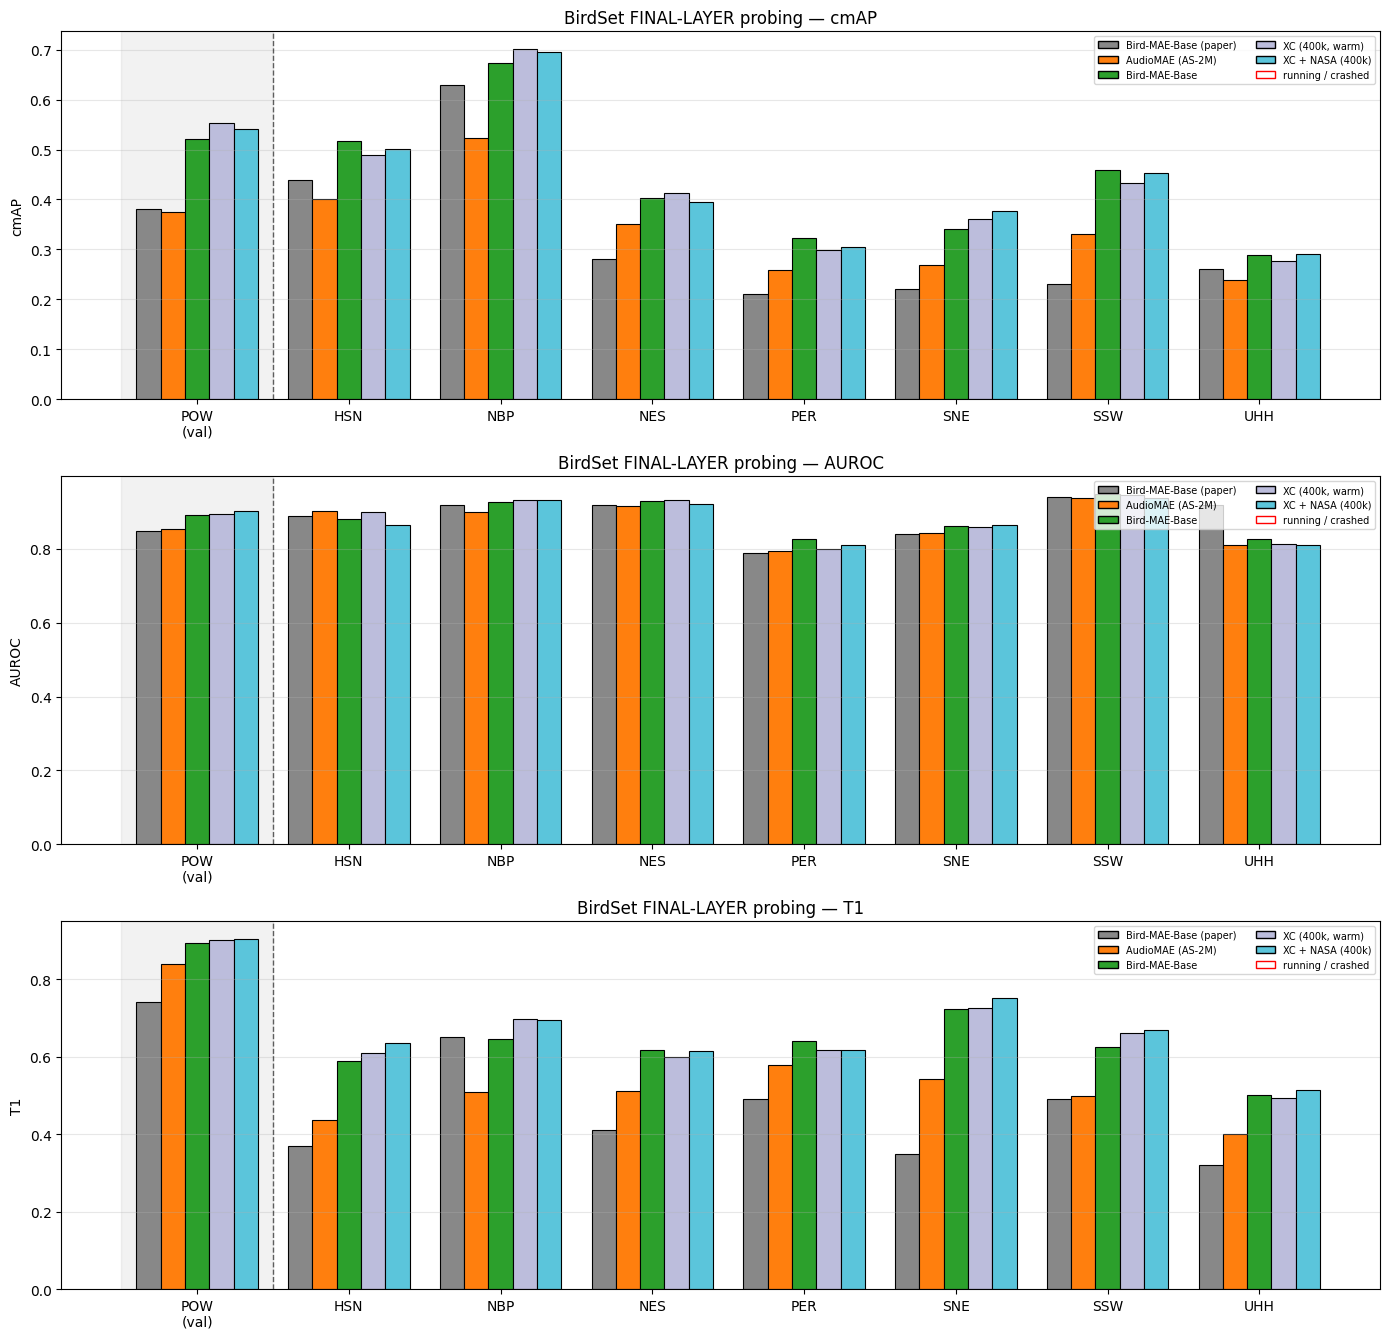

In [6]:
bar_plot(final_tables, final_states, final_ranges, FINAL_BACKBONES,
         "BirdSet FINAL-LAYER probing")

## 2. Layerwise probing — baselines

Same backbones and protocol, but the head learns a softmax-weighted sum over all
12 encoder blocks (`ViTProtoLayerwise`) instead of reading out the last one. For
an MAE the final blocks specialise for reconstruction, so this is the fairer
readout of how much transferable signal the encoder holds — and it applies
equally to the external encoders. The learned weights themselves are in
`birdset_layer_weights_nasa.ipynb`.

`XC (400k)` here is the **cold-start** 400k run, which is the one used from this
point on; the warm restart that used to hold this slot is `XC (400k, warm)` and
appears in section 1 (its only final-layer probe) and in the section-3 `init` row.
All three 400k NASA arms are included here, since this is the only head they
share: the fixed-event store, the `v2` region store at the same 25 % PAM weight,
and that region store at 50 %. So the panel reads as one windowing change and one
dose change against the same baselines and the same equal-length XC-only control.
Section 9 keeps the narrower events-vs-regions contrast and its marginal-effect
rows.

In [7]:
lw_tables, lw_states, lw_ranges = tables(layerwise_df, LW_BASELINES)

print("Run states:")
print(lw_states.to_string())
print()
print(summary(lw_tables, "layerwise").to_string())
lw_tables["cmAP"].round(4)

Run states:
backbone AudioMAE (AS-2M) Bird-MAE-Base XC (400k) XC + NASA (400k) XC + NASA v2 (400k) XC + NASA v2 50% (400k)
dataset                                                                                                       
POW              finished      finished  finished         finished            finished                finished
HSN              finished      finished  finished         finished            finished                finished
NBP              finished      finished  finished         finished            finished                finished
NES              finished      finished  finished         finished            finished                finished
PER              finished      finished  finished         finished            finished                finished
SNE              finished      finished  finished         finished            finished                finished
SSW              finished      finished  finished         finished            finished              

backbone,AudioMAE (AS-2M),Bird-MAE-Base,XC (400k),XC + NASA (400k),XC + NASA v2 (400k),XC + NASA v2 50% (400k)
dataset,,,,,,
POW,0.3977,0.5136,0.5377,0.5414,0.5176,0.5312
HSN,0.4250,0.5203,0.5202,0.5312,0.4949,0.5056
NBP,0.5363,0.6813,0.7192,0.6970,0.6953,0.7186
NES,0.3631,0.4044,0.4067,0.4009,0.4004,0.4047
PER,0.2579,0.3121,0.3068,0.3007,0.3022,0.2994
SNE,0.2627,0.3473,0.3556,0.3716,0.3552,0.3672
SSW,0.3361,0.4395,0.4541,0.4596,0.4431,0.4476
UHH,0.2542,0.2944,0.3079,0.2891,0.3119,0.3218


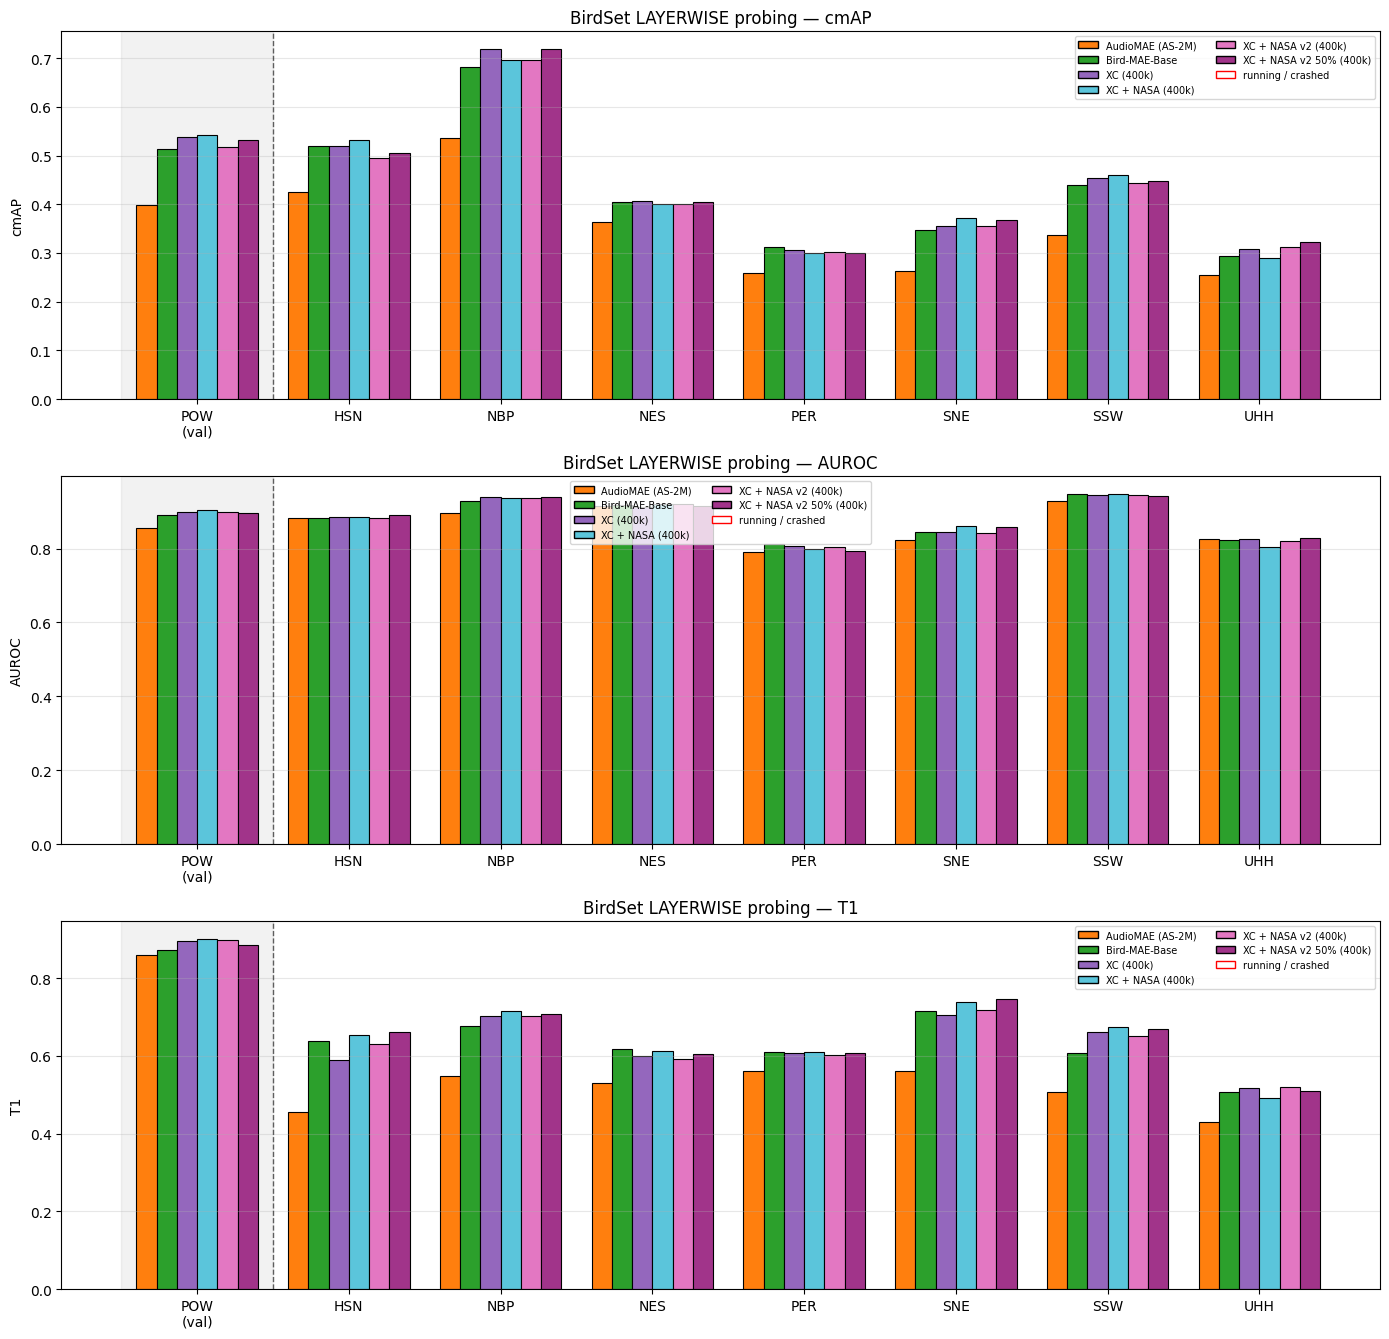

In [8]:
bar_plot(lw_tables, lw_states, lw_ranges, LW_BASELINES,
         "BirdSet LAYERWISE probing")

In [9]:
# How much the two heads differ per backbone (test-set means, POW excluded).
# The heads are evaluated separately above; this is just the two summaries placed
# side by side, not a merged comparison. Restricted to BASELINES rather than
# LW_BASELINES: the v2 arm has no final-layer probe, so it has no delta.
head_summary = pd.concat(
    {"final-layer": summary(final_tables, "final-layer"),
     "layerwise": summary(lw_tables, "layerwise")},
    axis=1).reindex(BASELINES)
head_summary[("delta", "cmAP")] = (head_summary[("layerwise", "cmAP")]
                                   - head_summary[("final-layer", "cmAP")])
head_summary.round(4)

final-layer                 layerwise                   delta
                        cmAP   AUROC      T1      cmAP   AUROC      T1    cmAP
AudioMAE (AS-2M)      0.3387  0.8729  0.4966    0.3479  0.8667  0.5131  0.0092
Bird-MAE-Base         0.4292  0.8866  0.6200    0.4285  0.8800  0.6246 -0.0007
XC (400k)                NaN     NaN     NaN    0.4386  0.8804  0.6263     NaN
XC + NASA (400k)      0.4312  0.8774  0.6425    0.4357  0.8799  0.6421  0.0045

## 3. Ablation — 2×2: pretraining length × NASA soundscapes

Both 1M-step backbones were only ever evaluated with the **layerwise** head, so
this section is layerwise throughout and is kept out of the baseline plots above.

All four cells exist, and as of 2026-08-13 all four are **cold-start** runs:

|  | XC only | XC + NASA |
| --- | --- | --- |
| **400k steps** | `XC (400k)` (cold, `8l8fvpq3`) | `XC + NASA (400k)` |
| **1M steps** | `XC (1M)` (2 seeds) | `XC + NASA (1M)` (2 seeds) |

That is the second confound removed from this table. The first was that the only
long-schedule run also had NASA data in it, so its gain over the 400k arm was a
sum of two changes with no way to split them; the 2×2 fixed that. The second was
that the 400k XC cell was a **warm restart** from an earlier XC checkpoint, so
both the schedule column and the NASA row were measured against a differently
initialised baseline. `XC (400k)` is now the cold-start run trained from scratch
for 400k steps, initialised exactly like the two 1M runs.

The superseded warm run is still fetched, as `XC (400k, warm)`, and enters the
decomposition below as an `init` row: same data, same 400k steps, same anneal,
only the starting weights differ. That row is the size of the confound that used
to sit inside the other rows — and it is bigger than either NASA row.

The NASA cells here are the **fixed 5 s event** store. The v2 region store, a
single-factor change to how the same curated soundscape is windowed, is in
section 9 rather than in this grid.

The two 1M cells now carry a **second probe seed**. Plotted values are the seed
mean and the whiskers are the seed min–max; the 400k cells are still single-seed
and so have no whisker. The second seed does more than tighten those two points:
because the backbone is held fixed between the two runs, seed 1 vs seed 2 is a
contrast whose true effect is *zero by construction*, which gives the
decomposition table a measured noise floor to read every other row against.

In [10]:
ab_tables, ab_states, ab_ranges = tables(layerwise_df, ABLATION)

print("Run states (layerwise):")
print(ab_states.to_string())
print()
print("seeds per cell (the 1M cells were probed twice):")
print(layerwise_df[layerwise_df["backbone"].isin(ABLATION)]
      .pivot_table(index="dataset", columns="backbone", values="n_seeds")
      .reindex(index=DATASETS, columns=ABLATION).astype(int).to_string())
print()
print(summary(ab_tables, "layerwise ablation").to_string())
ab_tables["cmAP"].round(4)

Run states (layerwise):
backbone XC (400k)   XC (1M) XC + NASA (400k) XC + NASA (1M)
dataset                                                     
POW       finished  finished         finished       finished
HSN       finished  finished         finished       finished
NBP       finished  finished         finished       finished
NES       finished  finished         finished       finished
PER       finished  finished         finished       finished
SNE       finished  finished         finished       finished
SSW       finished  finished         finished       finished
UHH       finished  finished         finished       finished

seeds per cell (the 1M cells were probed twice):
backbone  XC (400k)  XC (1M)  XC + NASA (400k)  XC + NASA (1M)
dataset                                                       
POW               1        2                 1               2
HSN               1        2                 1               2
NBP               1        2                 1               2
N

backbone,XC (400k),XC (1M),XC + NASA (400k),XC + NASA (1M)
dataset,,,,
POW,0.5377,0.5865,0.5414,0.5718
HSN,0.5202,0.5344,0.5312,0.5320
NBP,0.7192,0.7541,0.6970,0.7385
NES,0.4067,0.4224,0.4009,0.4252
PER,0.3068,0.3465,0.3007,0.3273
SNE,0.3556,0.3771,0.3716,0.3818
SSW,0.4541,0.4770,0.4596,0.4812
UHH,0.3079,0.3117,0.2891,0.3136


In [11]:
# --- The two seeds, unaveraged, and what they say about the noise floor ---
# IMPORTANT about what this seed is: the probe seed, not a pretraining seed. Both
# runs of a 1M cell load the SAME frozen checkpoint and differ only in probe-head
# init / data order, so this spread measures probe-training noise ONLY. It is a
# LOWER bound on the noise a backbone-vs-backbone delta must clear — pretraining
# variance, which we have not measured, sits on top of it.
_multi = runs_df[(runs_df["probing"] == "layerwise")
                 & (runs_df["backbone"].isin(ABLATION))]
_multi = _multi[_multi["backbone"].isin(
    _multi.groupby("backbone")["seed"].nunique().loc[lambda s: s > 1].index)]

print("per-seed cmAP for the multi-seed cells")
print(_multi.pivot_table(index="dataset", columns=["backbone", "seed"], values="cmAP")
            .reindex(DATASETS).round(4).to_string())


def seed_spread(backbones, probing="layerwise"):
    """Seed-to-seed spread on the TEST sets for every cell that has >1 seed."""
    sub = runs_df[(runs_df["probing"] == probing) & (runs_df["backbone"].isin(backbones))]
    rows = {}
    for backbone, g in sub.groupby("backbone"):
        if g["seed"].nunique() < 2:
            continue
        rec = {}
        for m in METRICS:
            p = g.pivot_table(index="dataset", columns="seed", values=m).loc[TEST_DATASETS]
            rec[(m, "mean per-dataset range")] = (p.max(axis=1) - p.min(axis=1)).mean()
            rec[(m, "range of test mean")] = p.mean().max() - p.mean().min()
        rows[backbone] = rec
    out = pd.DataFrame.from_dict(rows, orient="index")
    out.columns = pd.MultiIndex.from_tuples(out.columns)
    return out


print("\nprobe-seed spread (test sets only, POW excluded)")
seed_spread(ABLATION).round(4)

per-seed cmAP for the multi-seed cells
backbone XC (1M)         XC + NASA (1M)        
seed           1       2              1       2
dataset                                        
POW       0.5809  0.5921         0.5708  0.5728
HSN       0.5364  0.5324         0.5346  0.5294
NBP       0.7526  0.7556         0.7413  0.7357
NES       0.4230  0.4217         0.4246  0.4258
PER       0.3467  0.3463         0.3282  0.3264
SNE       0.3784  0.3758         0.3793  0.3843
SSW       0.4763  0.4777         0.4771  0.4853
UHH       0.3123  0.3110         0.3148  0.3125

probe-seed spread (test sets only, POW excluded)


cmAP                     \
               mean per-dataset range range of test mean   
XC (1M)                        0.0020             0.0007   
XC + NASA (1M)                 0.0042             0.0001   

                                AUROC                     \
               mean per-dataset range range of test mean   
XC (1M)                        0.0069             0.0013   
XC + NASA (1M)                 0.0047             0.0025   

                                   T1                     
               mean per-dataset range range of test mean  
XC (1M)                        0.0129             0.0040  
XC + NASA (1M)                 0.0123             0.0036

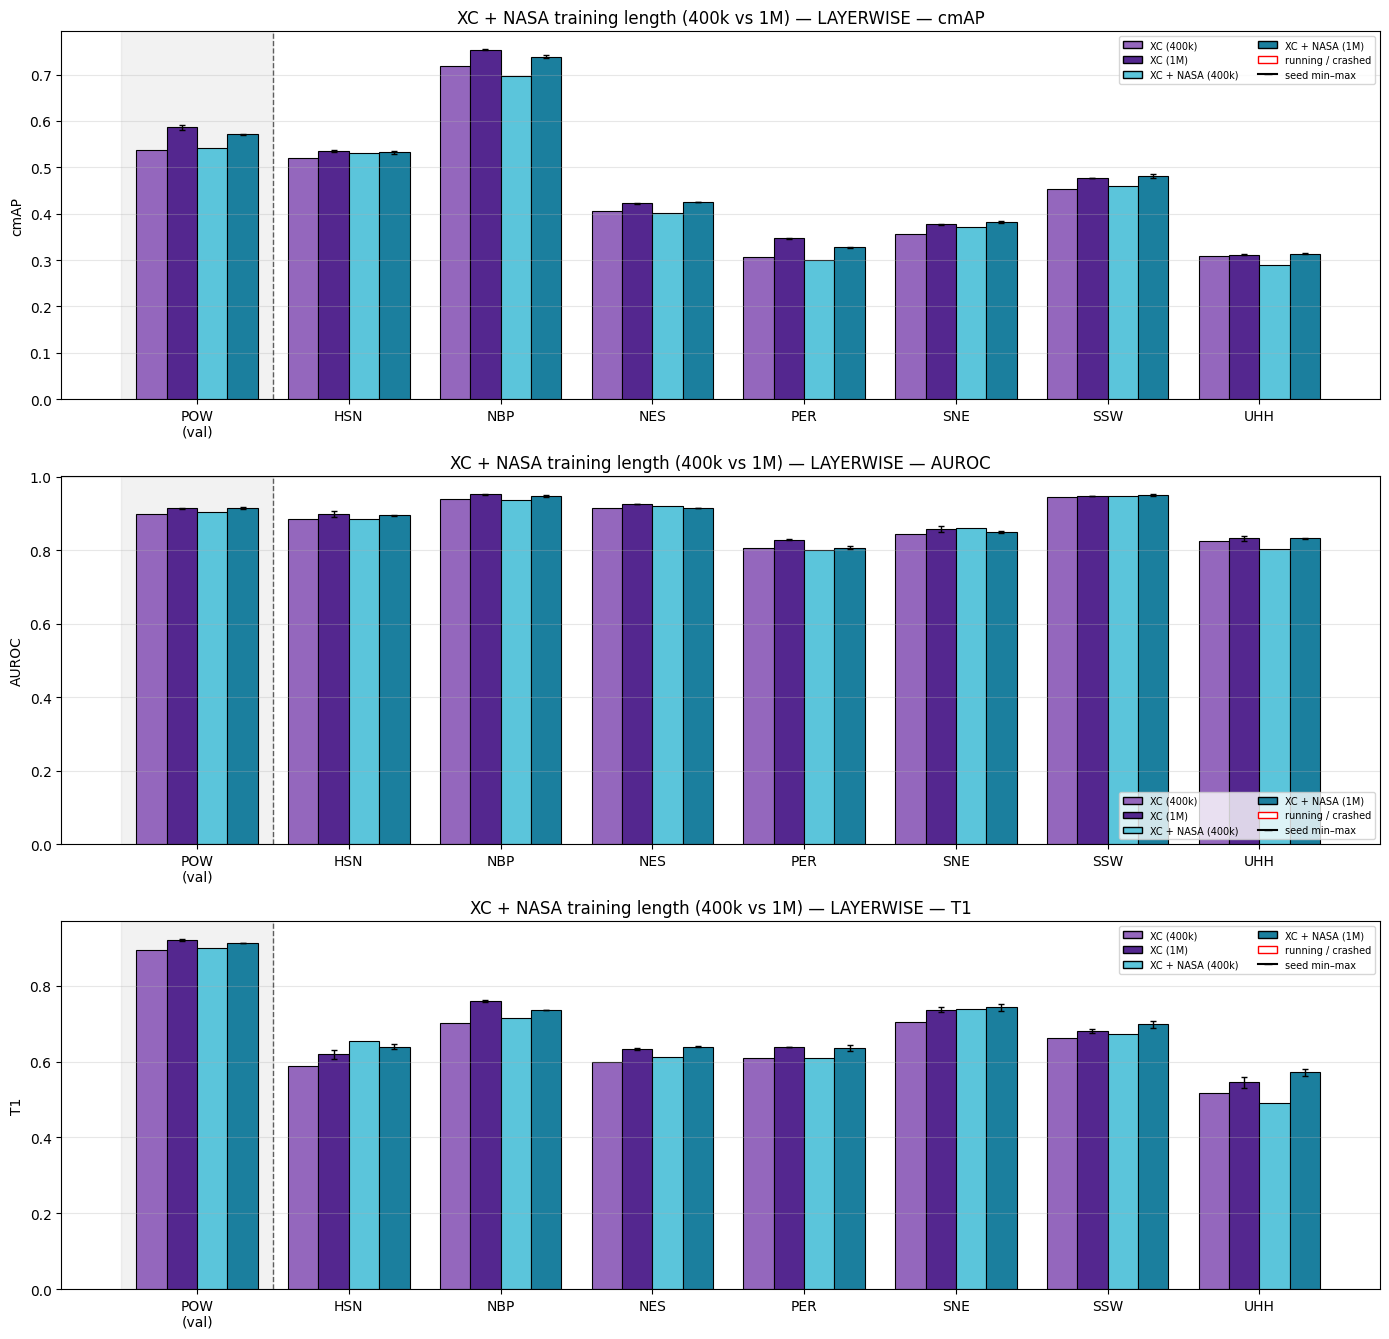

In [12]:
bar_plot(ab_tables, ab_states, ab_ranges, ABLATION,
         "XC + NASA training length (400k vs 1M) — LAYERWISE")

In [13]:
# --- 2x2 decomposition: what is the longer schedule worth, and what is NASA worth? ---
# Each row is a contrast with the OTHER factor held fixed, which is the only way to
# attribute a delta to one factor. `wins` counts how many of the 7 test datasets
# improve (POW excluded, as everywhere else), so a mean delta driven by one dataset
# is visible as a weak win count. Effect rows use the SEED MEAN of each cell.
def _contrast(tables, a, b):
    out = {}
    for m in METRICS:
        d = tables[m].loc[TEST_DATASETS, b] - tables[m].loc[TEST_DATASETS, a]
        out[(m, "delta")] = d.mean()
        out[(m, "wins")] = f"{int((d > 0).sum())}/{len(TEST_DATASETS)}"
    return out


CONTRASTS = [
    ("schedule", "400k -> 1M | XC only",   XC_400K,      XC_1M),
    ("schedule", "400k -> 1M | XC + NASA", XC_NASA_400K, XC_NASA_1M),
    ("NASA",     "+NASA | 400k steps",     XC_400K,      XC_NASA_400K),
    ("NASA",     "+NASA | 1M steps",       XC_1M,        XC_NASA_1M),
]
rows = [_contrast(ab_tables, a, b) for _, _, a, b in CONTRASTS]
index = [(f, lbl) for f, lbl, _, _ in CONTRASTS]

# INIT: the superseded warm restart vs the cold-start run that replaced it as
# `XC (400k)`. Same data, same 400k steps, same anneal — only the starting weights
# differ. Until 2026-08-13 every row above was measured against the warm run, so
# this is the size of the confound they carried. It needs its own `tables` call
# because the warm arm is deliberately not a column of the 2x2.
_init_tables = tables(layerwise_df, [XC_400K_WARM, XC_400K])[0]
rows.append(_contrast(_init_tables, XC_400K_WARM, XC_400K))
index.append(("init", "warm -> cold | XC 400k"))

# Noise floor: the SAME machinery run on the two probe seeds of each multi-seed
# cell, i.e. a contrast whose true effect is zero by construction. Read every row
# above against these: a delta of the same magnitude, or a `wins` near 3.5/7, is
# indistinguishable from probe noise.
def _seed_tables(backbone, probing="layerwise"):
    """metric -> table whose COLUMNS are seeds, so `_contrast` can treat
    seed-vs-seed as just another contrast."""
    g = runs_df[(runs_df["probing"] == probing) & (runs_df["backbone"] == backbone)]
    return {m: g.pivot_table(index="dataset", columns="seed", values=m) for m in METRICS}


for backbone in ABLATION:
    st = _seed_tables(backbone)
    seeds = sorted(st[METRICS[0]].columns)
    if len(seeds) < 2:
        continue
    rows.append(_contrast(st, seeds[0], seeds[-1]))
    index.append(("noise floor", f"seed {seeds[0]} -> {seeds[-1]} | {backbone}"))

decomp = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(
    index, names=["factor", "contrast"]))
decomp.columns = pd.MultiIndex.from_tuples(decomp.columns)
print("marginal effects on the test-set mean (POW excluded)")
decomp.round(4)

marginal effects on the test-set mean (POW excluded)


cmAP        AUROC           T1  \
                                           delta wins   delta wins   delta   
factor      contrast                                                         
schedule    400k -> 1M | XC only          0.0218  7/7  0.0117  7/7  0.0329   
            400k -> 1M | XC + NASA        0.0213  7/7  0.0055  5/7  0.0246   
NASA        +NASA | 400k steps           -0.0029  3/7 -0.0005  4/7  0.0158   
            +NASA | 1M steps             -0.0033  4/7 -0.0067  2/7  0.0075   
init        warm -> cold | XC 400k        0.0135  6/7  0.0034  5/7 -0.0060   
noise floor seed 1 -> 2 | XC (1M)        -0.0007  2/7 -0.0013  3/7  0.0040   
            seed 1 -> 2 | XC + NASA (1M) -0.0001  3/7 -0.0025  3/7  0.0036   

                                               
                                         wins  
factor      contrast                           
schedule    400k -> 1M | XC only          7/7  
            400k -> 1M | XC + NASA        6/7  
NASA        +NASA | 400k steps            6/7  
            +NASA | 1M steps              5/7  
init        warm -> cold | XC 400k        3/7  
noise floor seed 1 -> 2 | XC (1M)         5/7  
            seed 1 -> 2 | XC + NASA (1M)  4/7

### Reading the 2×2

The decomposition above separates the two factors that used to be tangled, and
the two `noise floor` rows say how much of any row is readable. Those rows are
the seed-1-vs-seed-2 contrast within a single 1M cell — same frozen backbone,
so the true effect is zero — and they come out at **|Δ| ≤ 0.001 cmAP on the test
mean** (per-dataset range 0.002–0.004) with win counts of 2/7 and 3/7, i.e.
coin-flip.

* **Pretraining length is doing the work, and it clears the noise floor by a wide
  margin.** 400k → 1M is worth **+0.022** cmAP on XC only and **+0.021** with
  NASA, at 7/7 test datasets both times. That is ~20× the measured seed range. The
  two schedule rows now agree to 0.0002 — they did not when the 400k XC cell was
  the warm restart (+0.035 vs +0.021), and a schedule effect that depends on the
  data mix was always the suspicious part of that pair.
* **NASA soundscapes are null-to-slightly-negative, at both schedules.**
  **−0.003** cmAP at 400k (3/7) and **−0.003** at 1M (4/7): same sign, same
  magnitude, both at the noise floor sitting right under them. The +0.011 (5/7)
  this row used to show at 400k was not a NASA gain — it was the warm-restart
  handicap on the XC baseline it was measured against.
* **The `init` row says how large that handicap was: +0.014 cmAP (6/7) for cold
  over warm** at identical data and step count. It is larger than either NASA row
  and two thirds of a schedule row, so any earlier reading in which a 400k number
  was compared against `XC (400k)` needs it subtracted. Note it is a cmAP effect
  specifically: AUROC moves +0.002 and T1 −0.002, so the two encoders are close in
  ranking quality and differ mainly in precision on the rare positives.
* Consequently the earlier `XC + NASA (1M)` gain over `XC (400k)` was a
  **schedule** effect and nothing else, and the XC-only column is now the stronger
  one at both lengths. `XC (400k)` cold reaches **0.439** on the test mean, above
  our own probe of `Bird-MAE-Base` (0.429) and within 0.021 of `XC (1M)` (0.460).

What the second seed does and does not buy: it makes the *schedule* claim solid —
the effect is orders of magnitude above probe noise — and it removes the "maybe
one of these numbers is just a lucky probe" reading of the NASA rows. It does
**not** turn the NASA null into a measured zero, because it varies only the probe
seed; the backbone is identical between the two runs. Pretraining variance is
unmeasured, and the `init` row is a first, crude lower bound on how large it can
be: two XC-only 400k runs that differ only in initialisation are 0.014 cmAP apart,
which is 14× the probe-seed floor and larger than every NASA effect in the table.


## 4. Learned layer-fusion weights (layerwise probe)

**Moved to `birdset_layer_weights_nasa.ipynb`.** The layerwise head learns one
softmax weight per encoder block; those profiles, the heatmaps and the centroid
table now live in that notebook (which also covers the §9 windowing arms). The
section number is kept so the cross-references from §2, §9 and
`birdset_results_external.ipynb` still land.


## 5. Layerwise probing vs pretraining step

Section 3 could only compare the *endpoints* 400k and 1M. This sweep probes the
intermediate checkpoints of the two 1M pretraining runs themselves, so the
schedule axis becomes a curve instead of two points: it answers when probing
performance saturates, and whether the 400k → 1M gain is accumulated pretraining
or something else.

All layerwise, seed 1. **Read the coverage first** — the sweep is not finished:

* only **POW (val), HSN, PER** have step runs, so there are just **two test
  datasets**; there is no meaningful test-set mean yet.
* the two mixes were probed on **different step grids** — XC every 100k,
  XC + NASA at 200/400/600/700/900k — so mix-vs-mix is read only at the five
  shared steps.

**What the three series in each panel are.**

* **solid curve + round markers** — intermediates of the 1M run, mid-cosine.
* **square at 1M, reached by a dashed hop** — that run's final, *annealed*
  checkpoint (`XC_1M.ckpt` / `XC_nasa_1M.ckpt`). Drawn distinctly because the
  last segment is not just 100k more steps, it is also the end of the LR decay.
  This assumes those two files are the final checkpoints of these same two runs.
* **dotted horizontal line** — the separately trained 400k-schedule backbone of
  the same mix, i.e. the `XC (400k)` / `XC + NASA (400k)` of sections 2–3. The
  grey vertical at 400k is where it can be read against the curve at equal step
  count.

That last comparison is now clean for both mixes: `XC (400k)` is the cold-start
`Pretrain-XC-400k` and `XC + NASA (400k)` was always cold, so at the grey 400k
line the dotted line and the curve differ **only in LR schedule** (a finished
cosine vs mid-cosine) and not in initialisation. Until 2026-08-13 the XC dotted
line was the warm-restarted run, which sits ~0.02 cmAP lower on HSN — that gap is
what the old "the 400k baseline is not the 1M run truncated" caveat was about, and
it is now measured directly as the `init` row of section 3.

In [14]:
# --- The step sweep: layerwise probing at every 100k of pretraining ---
# Only the datasets that have step runs are shown; the sweep is still filling in.
# The two mixes were probed on DIFFERENT step grids (XC every 100k, XC + NASA at
# 200/400/600/700/900k), so mix-vs-mix is only read at the shared steps.
step_state = step_long()
STEP_DATASETS = [d for d in DATASETS if d in set(step_df["dataset"])]
STEP_TEST_DATASETS = [d for d in STEP_DATASETS if d in TEST_DATASETS]

print(f"datasets with step runs: {STEP_DATASETS}  "
      f"(of which test sets: {STEP_TEST_DATASETS})")
print(f"missing entirely: {[d for d in DATASETS if d not in STEP_DATASETS]}\n")
print("cmAP vs pretraining step (1M = the annealed final checkpoint):")
print(step_state.pivot_table(index="step", columns=["mix", "dataset"], values="cmAP")
                .reindex(columns=pd.MultiIndex.from_product([MIXES, STEP_DATASETS]))
                .round(4).to_string())

datasets with step runs: ['POW', 'HSN', 'PER']  (of which test sets: ['HSN', 'PER'])
missing entirely: ['NBP', 'NES', 'SNE', 'SSW', 'UHH']

cmAP vs pretraining step (1M = the annealed final checkpoint):
               XC                 XC + NASA                
              POW     HSN     PER       POW     HSN     PER
step                                                       
100000.0   0.5247  0.4721  0.2764       NaN     NaN     NaN
200000.0   0.5423  0.5014  0.3023    0.5308  0.4959  0.2862
300000.0   0.5653  0.4908  0.3183       NaN     NaN     NaN
400000.0   0.5514  0.5207  0.3287    0.5411  0.5248  0.3131
500000.0   0.5604  0.5027  0.3252       NaN     NaN     NaN
600000.0   0.5641  0.5180  0.3377    0.5634  0.5174  0.3228
700000.0   0.5883  0.5276  0.3412    0.5581  0.5215  0.3207
800000.0   0.5901  0.5282  0.3427       NaN     NaN     NaN
900000.0   0.5781  0.5193  0.3466    0.5724  0.5210  0.3296
1000000.0  0.5865  0.5344  0.3465    0.5718  0.5320  0.3273


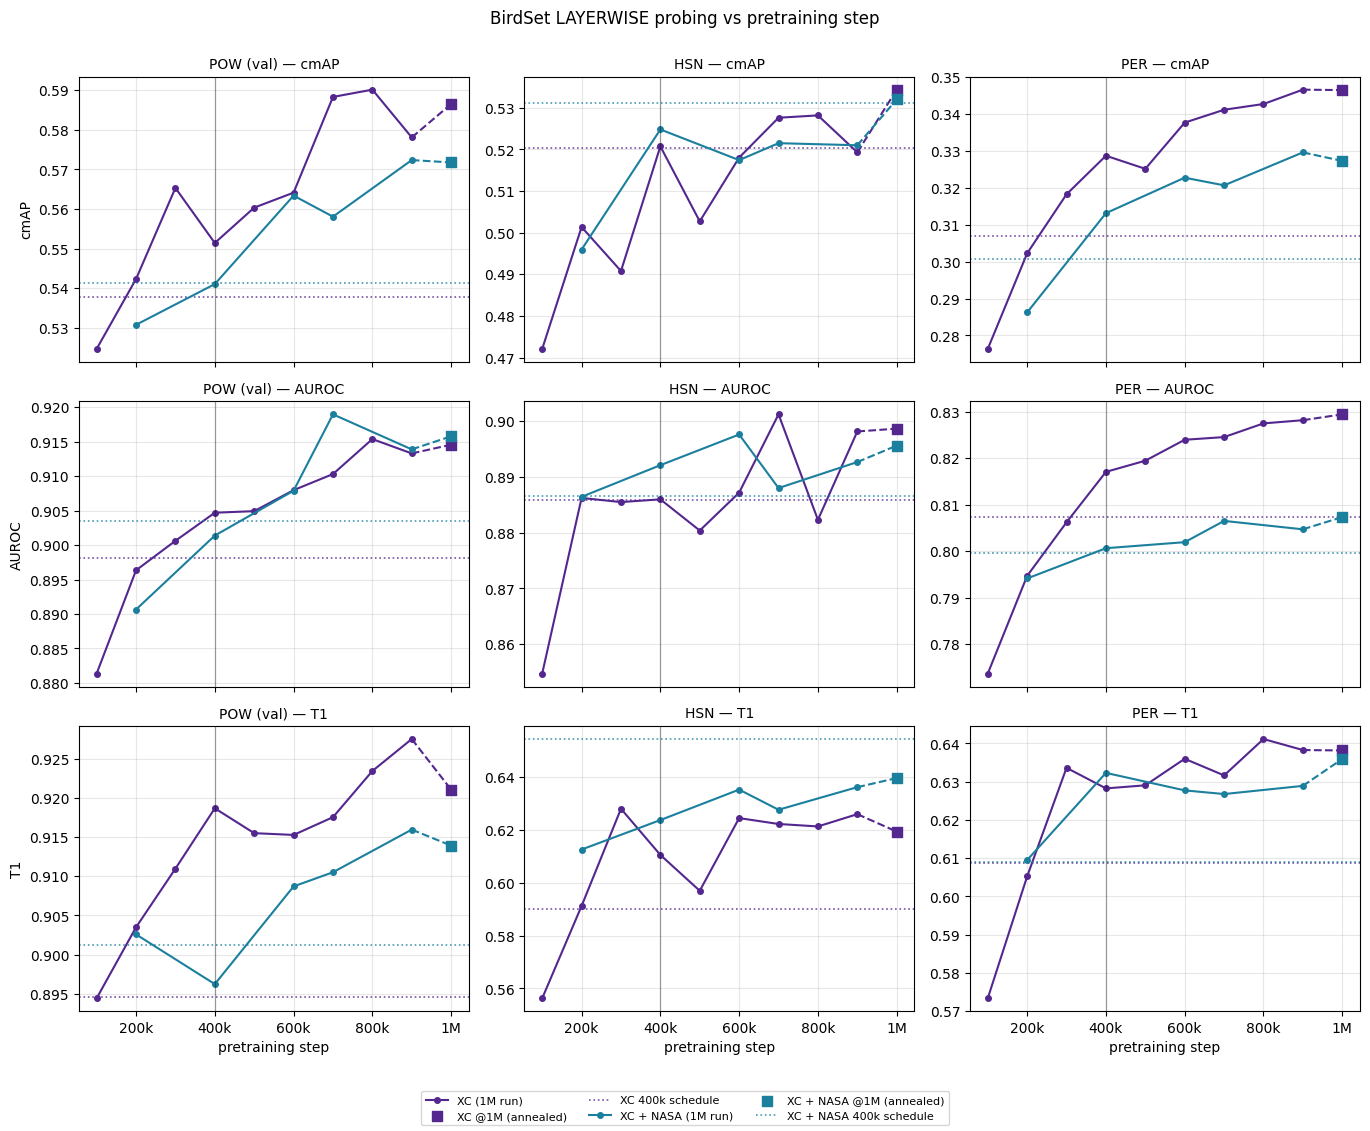

In [15]:
step_plot(step_state, STEP_DATASETS)

In [16]:
# --- What the step curves say, as three contrasts ---
# 1. SATURATION: how much of the 900k value is already there at 400k, and whether
#    the curve is still rising over its last 300k.
# 2. ANNEAL: the separately trained, cosine-annealed 400k-schedule run vs the SAME
#    mix mid-flight at step 400k of the 1M schedule. Same data, same step count,
#    different LR schedule — so this isolates the schedule from the step count, and
#    is the one thing section 3's 2x2 could not separate.
# 3. MIX: XC vs XC + NASA at the shared steps, i.e. the section-3 NASA contrast
#    resolved along pretraining time instead of only at the endpoints.
def _at(mix, ds, step, metric="cmAP"):
    v = step_state[(step_state["mix"] == mix) & (step_state["dataset"] == ds)
                   & (step_state["step"] == step)][metric]
    return v.iloc[0] if len(v) else np.nan


def _annealed_400k(mix, ds, metric="cmAP"):
    v = layerwise_df[(layerwise_df["backbone"] == MIX_ANNEALED_400K[mix])
                     & (layerwise_df["dataset"] == ds)][metric]
    return v.iloc[0] if len(v) else np.nan


rows = []
for mix in MIXES:
    for ds in STEP_DATASETS:
        rows.append({
            "mix": mix, "dataset": ds,
            "@400k (1M sched)": _at(mix, ds, 400_000),
            "@900k": _at(mix, ds, 900_000),
            "@1M (annealed)": _at(mix, ds, ENDPOINT_STEP),
            "400k -> 900k": _at(mix, ds, 900_000) - _at(mix, ds, 400_000),
            "900k -> 1M anneal": _at(mix, ds, ENDPOINT_STEP) - _at(mix, ds, 900_000),
            "400k sched (own run)": _annealed_400k(mix, ds),
            "anneal@400k advantage": _annealed_400k(mix, ds) - _at(mix, ds, 400_000),
        })
saturation = pd.DataFrame(rows).set_index(["mix", "dataset"])
print("cmAP — saturation and the effect of annealing (POW is the val set)")
print(saturation.round(4).to_string())

# Mix contrast at every step both arms were probed at.
shared = sorted(set(step_state[step_state["mix"] == XC_MIX]["step"])
                & set(step_state[step_state["mix"] == XC_NASA_MIX]["step"]))
mix_delta = pd.DataFrame({
    ds: {s: _at(XC_NASA_MIX, ds, s) - _at(XC_MIX, ds, s) for s in shared}
    for ds in STEP_DATASETS})
mix_delta.index.name = "step"
print("\ncmAP delta (XC + NASA) - (XC) at the shared steps — positive = NASA helps")
print(mix_delta.round(4).to_string())
print(f"\nmean over the {len(STEP_TEST_DATASETS)} available TEST datasets "
      f"({', '.join(STEP_TEST_DATASETS)}):")
print(mix_delta[STEP_TEST_DATASETS].mean(axis=1).round(4).to_string())

cmAP — saturation and the effect of annealing (POW is the val set)
                   @400k (1M sched)   @900k  @1M (annealed)  400k -> 900k  900k -> 1M anneal  400k sched (own run)  anneal@400k advantage
mix       dataset                                                                                                                        
XC        POW                0.5514  0.5781          0.5865        0.0266             0.0084                0.5377                -0.0137
          HSN                0.5207  0.5193          0.5344       -0.0014             0.0151                0.5202                -0.0005
          PER                0.3287  0.3466          0.3465        0.0179            -0.0001                0.3068                -0.0219
XC + NASA POW                0.5411  0.5724          0.5718        0.0313            -0.0006                0.5414                 0.0003
          HSN                0.5248  0.5210          0.5320       -0.0038             0.0110             

### Reading the step curves

Three things fall out, all on **HSN and PER only** (the two test datasets the
sweep has reached) — so treat them as strong hints, not settled numbers.

* **Probing performance saturates early.** Both mixes climb steeply to ~200–400k
  and then flatten. From 400k to 900k, cmAP moves by **−0.001 (HSN) / +0.018
  (PER)** for XC and **−0.004 / +0.016** for XC + NASA. More than half a million
  extra steps buys roughly what section 3 measured as the probe-seed noise floor
  on one dataset and a modest gain on the other. POW (val) keeps rising a little
  longer (+0.027 / +0.031), which is worth remembering when POW is used to pick
  checkpoints.
* **The last leg is the anneal, not the steps.** 900k → 1M adds **+0.015 (HSN)**
  for XC and **+0.011** for XC + NASA while PER is flat — and that segment is
  where the LR finishes decaying. A cosine tail appears to be worth about as much
  as the preceding 500k steps of mid-schedule training.
* **At equal step count the annealed 400k run and the 1M run mid-flight agree.**
  On HSN, XC reads `0.520` (the cold-start 400k backbone) against `0.521` (the 1M
  run *at step 400k*), rising to `0.534` at 1M; on PER, `0.308` → `0.329` →
  `0.347`. So there is no consistent anneal advantage at 400k (HSN ~0, PER
  −0.021), and section 3's schedule row is left as an accumulated-pretraining
  effect. This bullet used to read "~60% of the 400k → 1M gain is already present
  at equal step count" — that artefact was the warm restart, which scores `0.500`
  on HSN where the cold-start run scores `0.520`.

And the mix contrast, now resolved along pretraining time rather than only at the
endpoints: **XC + NASA is below XC at every one of the shared steps**, by 0.006
to 0.013 cmAP on the HSN/PER mean, 6/6 steps including the 1M endpoint. With the
cold-start baseline in place section 3 now finds the NASA effect *negative* at
both schedules (−0.003 / −0.003), so the two views agree: a small, persistent
*dilution* rather than a sign-unstable null. It is a
weak claim on two datasets — the per-dataset probe-noise range measured in
section 3 was 0.002–0.004, so these deltas are only just clear of it — but the
consistency across nine checkpoints is not what pure noise looks like.

## 6. Linear probing

The cheap standard probe: frozen encoder, a single `nn.Linear` on the CLS token
(`ViTClassifier`, `configs/experiment/sweeps/eval_linear_probing.yaml`). Same
protocol as the prototypical probes — same transforms, same 1250 steps, same
`base_lr * batch_size / 256`, with `prototype_lr` / `layer_weights_lr` nulled out
since no params match them. Only the head differs, so the gap to sections 2–3 is a
statement about the head, not the backbone.

Run on `XC (1M)` and `XC + NASA (1M)` only, all 8 datasets, seed 1 — complete.

In [17]:
# === SECTION 6: linear probing ===
NEW_HEAD_BACKBONES = [XC_1M, XC_NASA_1M]   # the only two backbones these heads ran on

lin_tables, lin_states, lin_ranges = tables(linear_df, NEW_HEAD_BACKBONES)
print("Run states:")
print(lin_states.to_string())
print()
print(summary(lin_tables, "linear").to_string())
lin_tables["cmAP"].round(4)


Run states:
backbone   XC (1M) XC + NASA (1M)
dataset                          
POW       finished       finished
HSN       finished       finished
NBP       finished       finished
NES       finished       finished
PER       finished       finished
SNE       finished       finished
SSW       finished       finished
UHH       finished       finished

                                        cmAP   AUROC      T1
linear (test-set mean, POW excluded)                        
XC (1M)                               0.1313  0.7330  0.1481
XC + NASA (1M)                        0.1270  0.7081  0.1343


backbone,XC (1M),XC + NASA (1M)
dataset,,
POW,0.1767,0.1798
HSN,0.0934,0.0866
NBP,0.3218,0.2920
NES,0.1165,0.1060
PER,0.0630,0.0637
SNE,0.1397,0.1481
SSW,0.0862,0.0915
UHH,0.0989,0.1009


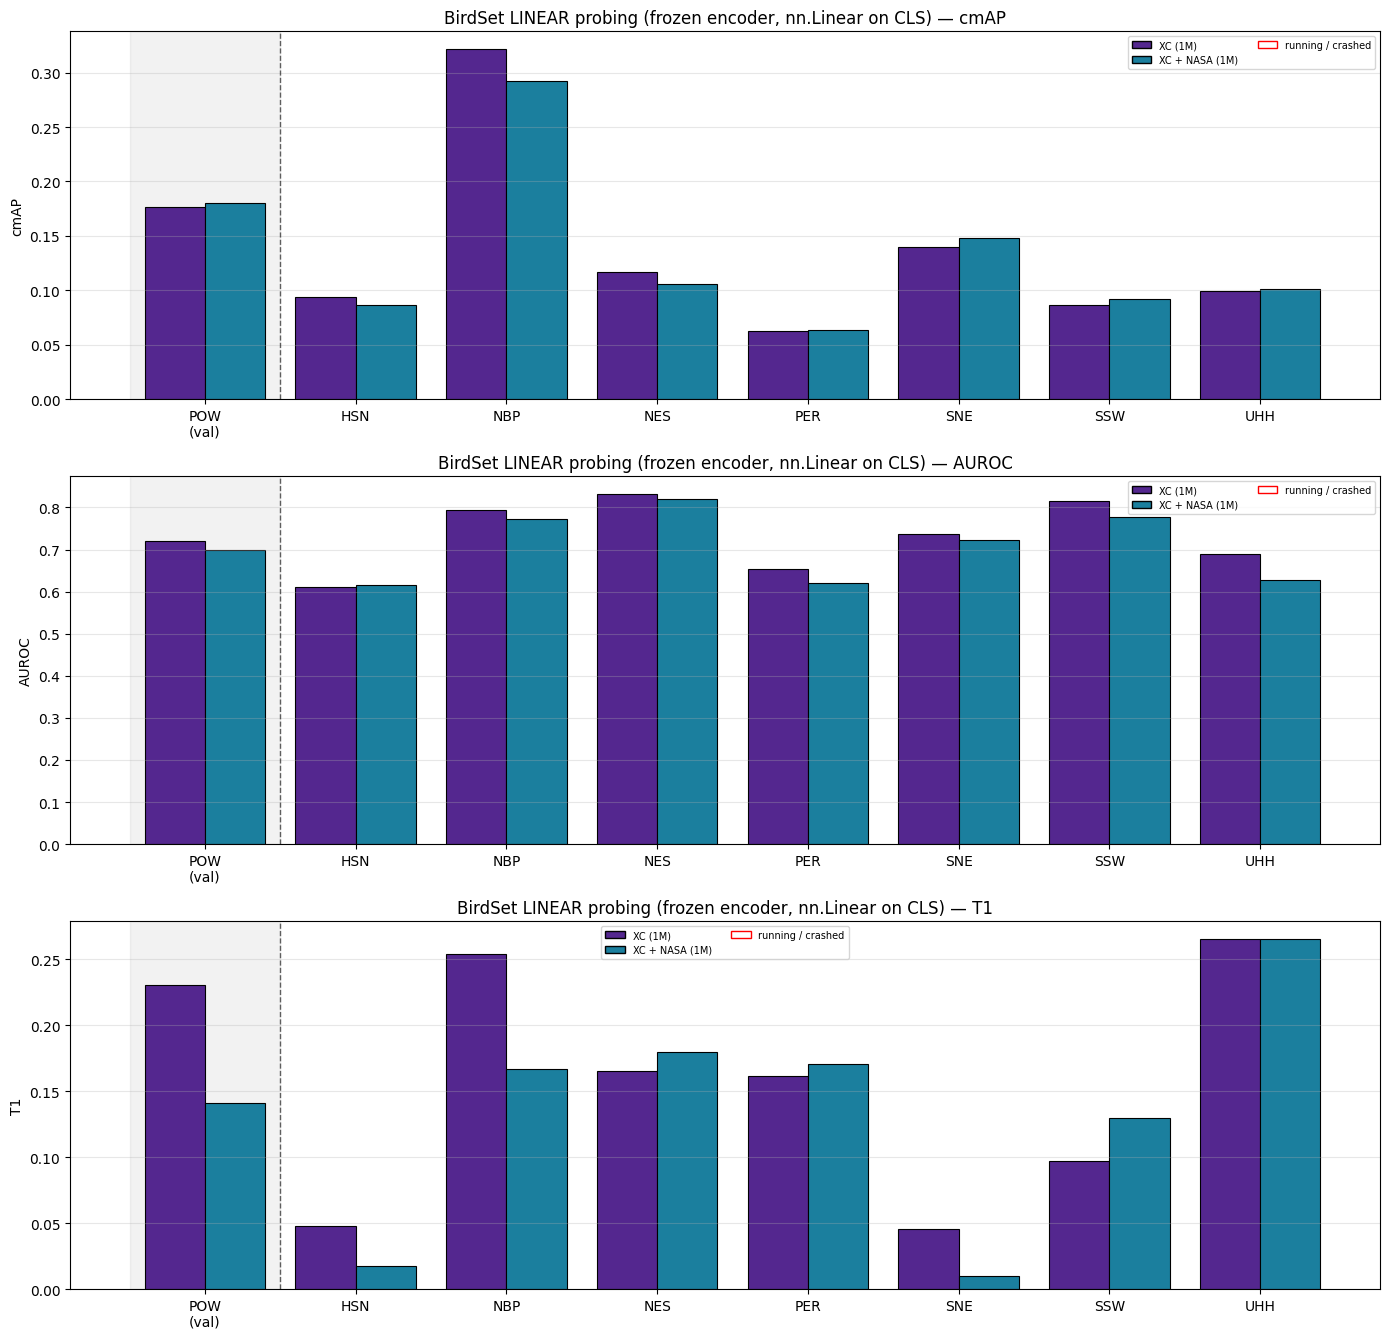

In [18]:
bar_plot(lin_tables, lin_states, lin_ranges, NEW_HEAD_BACKBONES,
         "BirdSet LINEAR probing (frozen encoder, nn.Linear on CLS)")


In [19]:
# How far below the prototypical heads the linear probe sits, on the same encoders.
# Both frozen, both 1250 steps — the only difference is the head, so the gap is a
# statement about the head, not the backbone.
lin_vs_proto = pd.concat(
    {"linear": summary(lin_tables, "linear"),
     "layerwise": summary(tables(layerwise_df, NEW_HEAD_BACKBONES)[0], "layerwise")},
    axis=1).reindex(NEW_HEAD_BACKBONES)
lin_vs_proto.index.name = "backbone"
lin_vs_proto[("ratio", "cmAP")] = (lin_vs_proto[("linear", "cmAP")]
                                   / lin_vs_proto[("layerwise", "cmAP")])
print("test-set mean (POW excluded) — linear vs layerwise on the same encoder")
print(lin_vs_proto.round(4).to_string())


test-set mean (POW excluded) — linear vs layerwise on the same encoder
                linear                 layerwise                   ratio
                  cmAP   AUROC      T1      cmAP   AUROC      T1    cmAP
backbone                                                                
XC (1M)         0.1313  0.7330  0.1481    0.4604  0.8921  0.6592  0.2852
XC + NASA (1M)  0.1270  0.7081  0.1343    0.4571  0.8854  0.6667  0.2778


**The linear head is not a usable readout of these encoders.** On the test mean
it reaches cmAP **0.131** where the layerwise prototype probe on the *same frozen
weights* reaches **0.460** — 29% of it — with AUROC 0.733 vs 0.892 and T1 0.148
vs 0.659. That is the expected shape for an MAE: nothing in the reconstruction
objective pushes class information into a linearly separable CLS direction, which
is why the MAE/AudioMAE line of work reports weak linear probes and leans on
finetuning. It may also simply be under-trained — 1250 steps at the layer-decay
group's LR was chosen for the prototype heads, not re-tuned here.

The practical consequence: at this level the **head is the bottleneck, not the
encoder**, so linear probing cannot rank backbones. It does put `XC (1M)` ahead of
`XC + NASA (1M)` (0.131 vs 0.127), the same sign as every other head, but nothing
should be built on a 0.004 gap between two probes that are both mostly failing.

## 7. Full finetuning

The same prototypical head as `final-layer` probing with the encoder **unfrozen**
(`configs/experiment/sweeps/eval_proto_finetune.yaml`). `module.freeze_backbone:
false` is the only change: transforms, `base_lr`, `prototype_lr`, `layer_decay`
and the 1250-step budget are inherited unchanged. So this is a clean
probing-vs-finetuning contrast rather than a re-tuned finetuning recipe — and
with the backbone trainable, `param_groups_lrd` finally applies its layer-wise LR
decay (0.75^(13−layer_id)) to the encoder.

`XC (1M)` and `XC + NASA (1M)`, seed 1 — **now complete on all 8 datasets** (it was
mid-flight when this section was written). The ragged-sweep machinery below is kept
anyway: it costs nothing when nothing is ragged, and section 10's sweep still has a
cell running. Only the datasets finished on *both* backbones enter the means —
with a ragged sweep the naive `df.mean()` averages one backbone over a different,
easier set of datasets than the other.

This is the **final-layer** finetune. Section 10 runs the same experiment from the
layerwise head, which is the fairer starting point for an MAE and turns out to be
the better finetune too.

In [20]:
# === SECTION 7: full finetuning ===
ft_tables, ft_states, ft_ranges = tables(finetune_df, NEW_HEAD_BACKBONES)
print("Run states (the sweep is still filling in — NaN/'x' = not started):")
print(ft_states.to_string())
print()

FT_DATASETS = sorted(set(finetune_df["dataset"]), key=DATASETS.index)
FT_COMMON = finished_everywhere(NEW_HEAD_BACKBONES, ["finetune"])
print(f"attempted:        {FT_DATASETS}")
print(f"not started:      {[d for d in DATASETS if d not in FT_DATASETS]}")
print(f"finished on BOTH backbones (the only comparable subset): {FT_COMMON}")
print("\nThe `summary` below spans whatever exists per backbone, so it is NOT a "
      "like-for-like\nbackbone comparison and NOT comparable to the 7-dataset "
      "probing means above — use\nthe restricted table under it for that.\n")
print(summary(ft_tables, "finetune (RAGGED — see note)").to_string())
print()
print(f"restricted to {FT_COMMON} — mean over the datasets finished on both backbones")
print(pd.DataFrame({m: ft_tables[m].loc[FT_COMMON].mean() for m in METRICS}).round(4).to_string())
ft_tables["cmAP"].round(4)


Run states (the sweep is still filling in — NaN/'x' = not started):
backbone   XC (1M) XC + NASA (1M)
dataset                          
POW       finished       finished
HSN       finished       finished
NBP       finished       finished
NES       finished       finished
PER       finished       finished
SNE       finished       finished
SSW       finished       finished
UHH       finished       finished

attempted:        ['POW', 'HSN', 'NBP', 'NES', 'PER', 'SNE', 'SSW', 'UHH']
not started:      []
finished on BOTH backbones (the only comparable subset): ['HSN', 'NBP', 'NES', 'PER', 'SNE', 'SSW', 'UHH']

The `summary` below spans whatever exists per backbone, so it is NOT a like-for-like
backbone comparison and NOT comparable to the 7-dataset probing means above — use
the restricted table under it for that.

                                                              cmAP   AUROC      T1
finetune (RAGGED — see note) (test-set mean, POW excluded)                        
XC (1M)      

backbone,XC (1M),XC + NASA (1M)
dataset,,
POW,0.5439,0.5499
HSN,0.5409,0.5457
NBP,0.7591,0.7599
NES,0.4264,0.4230
PER,0.3415,0.3250
SNE,0.3648,0.3577
SSW,0.4753,0.4782
UHH,0.3358,0.3353


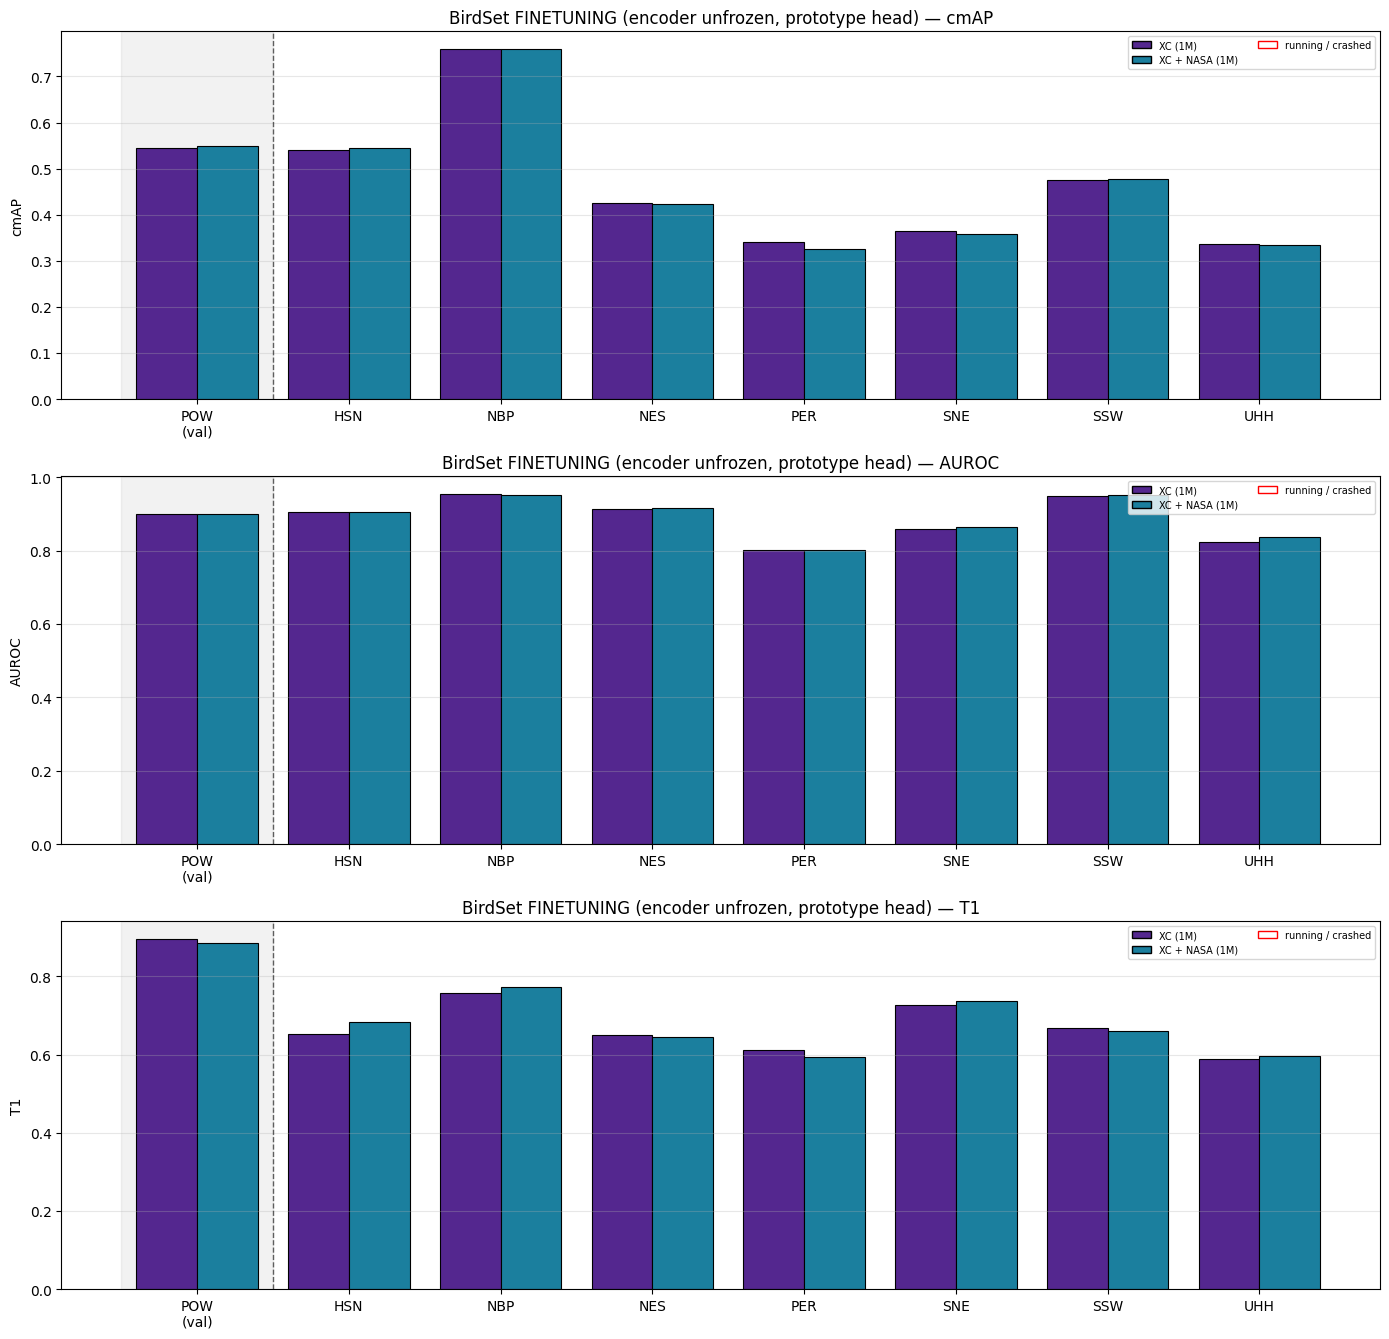

In [21]:
bar_plot(ft_tables, ft_states, ft_ranges, NEW_HEAD_BACKBONES,
         "BirdSet FINETUNING (encoder unfrozen, prototype head)")


## 8. The heads side by side

All heads that ran on the two 1M backbones, on the datasets where every
(backbone, head) pair has a **finished** run. `final-layer` is absent because the
1M backbones were never probed that way; the four that remain are `linear`,
`layerwise`, `finetune` and `layerwise-finetune`.

The common set was two datasets (HSN, NBP) while section 7 was mid-sweep. Both
finetuning sweeps are now essentially complete, so it covers the test sets
outright — with one caveat that the plot cannot show: on **NES/PER/SNE** the
`layerwise-finetune` column is scored on the repaired 89/132/56-class label space
and every other column on the old 88/131/55, so the *head* deltas on those three
tasks carry a label-space change as well (see the audit in the loading cell).

heads available on ['XC (1M)', 'XC + NASA (1M)']: ['linear', 'layerwise', 'finetune', 'layerwise-finetune']
absent:            ['final-layer']


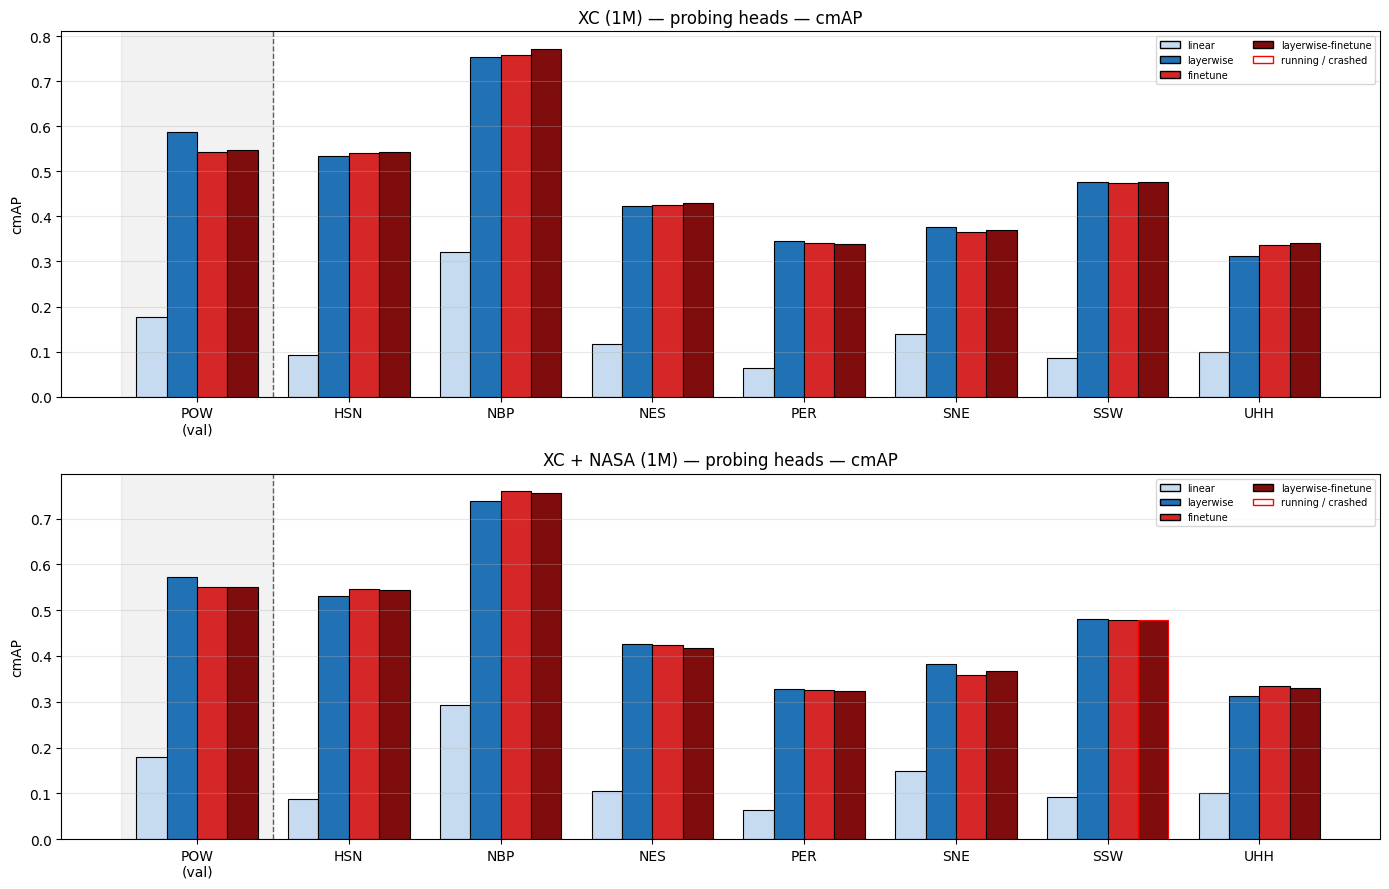

In [22]:
# === SECTION 8: the heads side by side ===
# `final-layer` never ran on the 1M backbones (they are layerwise-only, see
# section 3), so it is dropped rather than drawn as a row of empty slots.
AVAILABLE_HEADS = heads_present(NEW_HEAD_BACKBONES)
print(f"heads available on {NEW_HEAD_BACKBONES}: {AVAILABLE_HEADS}")
print(f"absent:            {[h for h in HEAD_ORDER if h not in AVAILABLE_HEADS]}")
head_plot(NEW_HEAD_BACKBONES, "cmAP", AVAILABLE_HEADS)


In [23]:
# All heads on a common footing: restricted to the test datasets where EVERY
# (backbone, head) pair has a finished run, which is what makes the column means
# comparable while finetuning is still mid-sweep.
_ht, _hs = head_tables(NEW_HEAD_BACKBONES, AVAILABLE_HEADS)
HEAD_COMMON = finished_everywhere(NEW_HEAD_BACKBONES, AVAILABLE_HEADS)
print(f"compared on the {len(HEAD_COMMON)} test datasets where all of "
      f"{AVAILABLE_HEADS} finished on both backbones: {HEAD_COMMON}")
print(f"excluded for want of a finished run: "
      f"{[d for d in TEST_DATASETS if d not in HEAD_COMMON]}\n")

head_cmp = pd.concat(
    {m: _ht[m].loc[HEAD_COMMON].mean().unstack("probing")[AVAILABLE_HEADS]
     for m in METRICS}, axis=1)
print("mean over the common datasets, per head")
print(head_cmp.round(4).to_string())

# The contrast worth naming: what unfreezing the encoder buys over the best frozen
# probe, and how far the linear head falls behind it.
_c = {h: _ht["cmAP"].xs(h, level="probing", axis=1).loc[HEAD_COMMON].mean()
      for h in AVAILABLE_HEADS}
gain = pd.DataFrame({f"{a} - layerwise": _c[a] - _c["layerwise"]
                     for a in AVAILABLE_HEADS if a != "layerwise"})
print("\ncmAP delta vs the layerwise probe (same encoder, same datasets)")
print(gain.round(4).to_string())

# And the question every section asks: does NASA change anything, per head?
nasa = pd.DataFrame({
    m: (_ht[m].loc[HEAD_COMMON, XC_NASA_1M] - _ht[m].loc[HEAD_COMMON, XC_1M]).mean()
    for m in METRICS}).reindex(AVAILABLE_HEADS)
nasa.index.name = "head"
print("\n(XC + NASA) - (XC) at 1M steps, per head — the NASA contrast, common datasets")
print(nasa.round(4).to_string())

compared on the 6 test datasets where all of ['linear', 'layerwise', 'finetune', 'layerwise-finetune'] finished on both backbones: ['HSN', 'NBP', 'NES', 'PER', 'SNE', 'UHH']
excluded for want of a finished run: ['SSW']

mean over the common datasets, per head
                  cmAP                                         AUROC                                            T1                                      
probing         linear layerwise finetune layerwise-finetune  linear layerwise finetune layerwise-finetune  linear layerwise finetune layerwise-finetune
backbone                                                                                                                                                
XC (1M)         0.1389    0.4577   0.4614             0.4655  0.7195    0.8827   0.8761             0.8768  0.1566    0.6555   0.6650             0.6676
XC + NASA (1M)  0.1329    0.4531   0.4578             0.4563  0.6964    0.8746   0.8794             0.8763  0.1351    0.6614   0

### Reading the head comparison

**linear ≪ layerwise ≲ finetune ≲ layerwise-finetune.** On the six test datasets
where all four heads have finished on both backbones (HSN, NBP, NES, PER, SNE, UHH
— SSW is excluded while one section-10 run is going), cmAP reads:

| head | `XC (1M)` | `XC + NASA (1M)` |
| --- | --- | --- |
| `linear` | 0.1389 | 0.1329 |
| `layerwise` (frozen) | 0.4577 | 0.4531 |
| `finetune` (final-layer, unfrozen) | 0.4614 | 0.4578 |
| `layerwise-finetune` (unfrozen) | **0.4655** | 0.4563 |

* **Unfreezing 86M parameters is worth ~0.005 cmAP.** +0.0037 (final-layer head)
  and +0.0078 (layerwise head) over the frozen layerwise probe on `XC (1M)`; +0.0047
  and +0.0032 on `XC + NASA (1M)`. At 1250 steps with an LR inherited from the
  probing recipe that is close to a null result, and it says the frozen features are
  already most of the story. Section 10 breaks the layerwise column down and removes
  the label-space confound that sits inside the NES/PER/SNE cells here.
* **The ordering is stable, the gaps are not.** `layerwise-finetune` is top on
  `XC (1M)` but *below* plain `finetune` on `XC + NASA (1M)` (0.4563 vs 0.4578), a
  0.0015 flip. Only the linear-vs-everything gap is large enough to be safe.
* **The NASA contrast is negative under all four heads now** — −0.0060 (linear),
  −0.0046 (layerwise), −0.0037 (finetune), −0.0092 (layerwise-finetune) cmAP. It
  used to disagree on sign; with section 7 finished and section 10 added it no
  longer does. Consistent with sections 3, 5 and 9: whatever the NASA mix does to
  BirdSet, none of these four readouts resolves it as a benefit.
* **Caveat on the finetuning columns.** Both unfrozen heads lose to the frozen probe
  on **POW** (section 10), and PER finetunes below its own probed value under both.
  A finetune landing under its frozen probe on the smaller tasks is the signature of
  too high an LR, so these columns are a lower bound on what a re-tuned finetuning
  recipe would give — they are a probing-vs-finetuning contrast at fixed
  hyperparameters, not a finetuning upper bound.

## 9. NASA windowing and PAM dose — events, regions (`v2`), regions at 50 %

Every NASA arm above draws its soundscape from the **event** store: one fixed 5 s
window per detection at confidence ≥ 0.7, 216 h over 69,369 granules
(`materialize_nasa_events.py`, `*_EVENTS_LOCAL`). At 25 % PAM weight a 400k-step
run at batch 512 draws ~205M samples, so each of those identical windows is seen
**~330×**, against ~20× for XenoCanto — whose crop offset is redrawn from a 66 s
mean recording every epoch. The NASA arm therefore differs from the XC arm in two
ways at once: *what* audio it adds, and how often it repeats the exact same view.

`v2` removes the second one. `materialize_nasa_regions.py` keeps the **same seed
granules** (every granule with a ≥ 0.7 detection), but stores a contiguous
*region* around the merged ≥ 0.4 detections instead of a fixed slice — ~136.5k
regions / ~932 h — and the loader draws a fresh random 5 s crop inside the region
at every access. Repeats of a distinct 5 s view drop to ~76×.

The third arm changes the **dose** instead of the windowing: same region store,
same granules, same 400k cold schedule, but a 50/50 rather than 75/25 batch split
(`pretrain_xc_nasa_regions_balanced.yaml`). That is a deliberate ~6× oversample of
PAM — by content the pool is 10,890 h XC against 941 h NASA, i.e. NASA is 8 % of
the audio — and it is only affordable because the region store absorbs it: PAM
repeats rise to ~151×, still under half the event store's ~330×, while XC repeats
fall from ~20× to ~13×.

| | `XC + NASA (400k)` | `XC + NASA v2 (400k)` | `XC + NASA v2 50% (400k)` |
| --- | --- | --- | --- |
| store | fixed 5 s per detection | merged detection regions | merged detection regions |
| crop | fixed | fresh random 5 s per access | fresh random 5 s per access |
| PAM repeats @400k | ~330× | ~76× | ~151× |
| XC repeats @400k | ~20× | ~20× | ~13× |
| granules / hours | 69,369 / 216 h | same 69,369 / 932 h | same 69,369 / 932 h |
| mix weights | `[384, 43, 85]` (75 % XC) | `[384, 43, 85]` (75 % XC) | `[256, 85, 171]` (50 % XC) |
| steps / init | 400k, cold | 400k, cold | 400k, cold |
| run | `1ddx8a1e` | `zsler3oi` → `bam1fdfd` (resumed @180k) | `ii4317y5` |

Each step is a **single factor**, so the decomposition below can attribute a delta
to one of them: `events → regions` moves only the windowing at fixed 25 % weight,
`25 % → 50 %` moves only the dose at fixed region store. The hypotheses they test
are specific — *if the NASA null on BirdSet is an artefact of the repetition
asymmetry, the windowing row shows it; if it is an artefact of too small a PAM
dose, the dose row shows it.* `XC (400k)` (cold, XC only) is the no-NASA control at
the same length, which is what makes all three NASA arms readable as effects
rather than as three numbers. All layerwise, seed 1, 8/8 finished.
`pretrain_xc_nasa_regions.yaml`, `pretrain_xc_nasa_regions_balanced.yaml`.


In [24]:
# === SECTION 9: NASA windowing and PAM dose ===
win_tables, win_states, win_ranges = tables(layerwise_df, WINDOWING)

print("Run states (layerwise):")
print(win_states.to_string())
print()
print(summary(win_tables, "NASA windowing / dose").to_string())
win_tables["cmAP"].round(4)


Run states (layerwise):
backbone XC (400k) XC + NASA (400k) XC + NASA v2 (400k) XC + NASA v2 50% (400k)
dataset                                                                        
POW       finished         finished            finished                finished
HSN       finished         finished            finished                finished
NBP       finished         finished            finished                finished
NES       finished         finished            finished                finished
PER       finished         finished            finished                finished
SNE       finished         finished            finished                finished
SSW       finished         finished            finished                finished
UHH       finished         finished            finished                finished

                                                       cmAP   AUROC      T1
NASA windowing / dose (test-set mean, POW excluded)                        
XC (400k)              

backbone,XC (400k),XC + NASA (400k),XC + NASA v2 (400k),XC + NASA v2 50% (400k)
dataset,,,,
POW,0.5377,0.5414,0.5176,0.5312
HSN,0.5202,0.5312,0.4949,0.5056
NBP,0.7192,0.6970,0.6953,0.7186
NES,0.4067,0.4009,0.4004,0.4047
PER,0.3068,0.3007,0.3022,0.2994
SNE,0.3556,0.3716,0.3552,0.3672
SSW,0.4541,0.4596,0.4431,0.4476
UHH,0.3079,0.2891,0.3119,0.3218


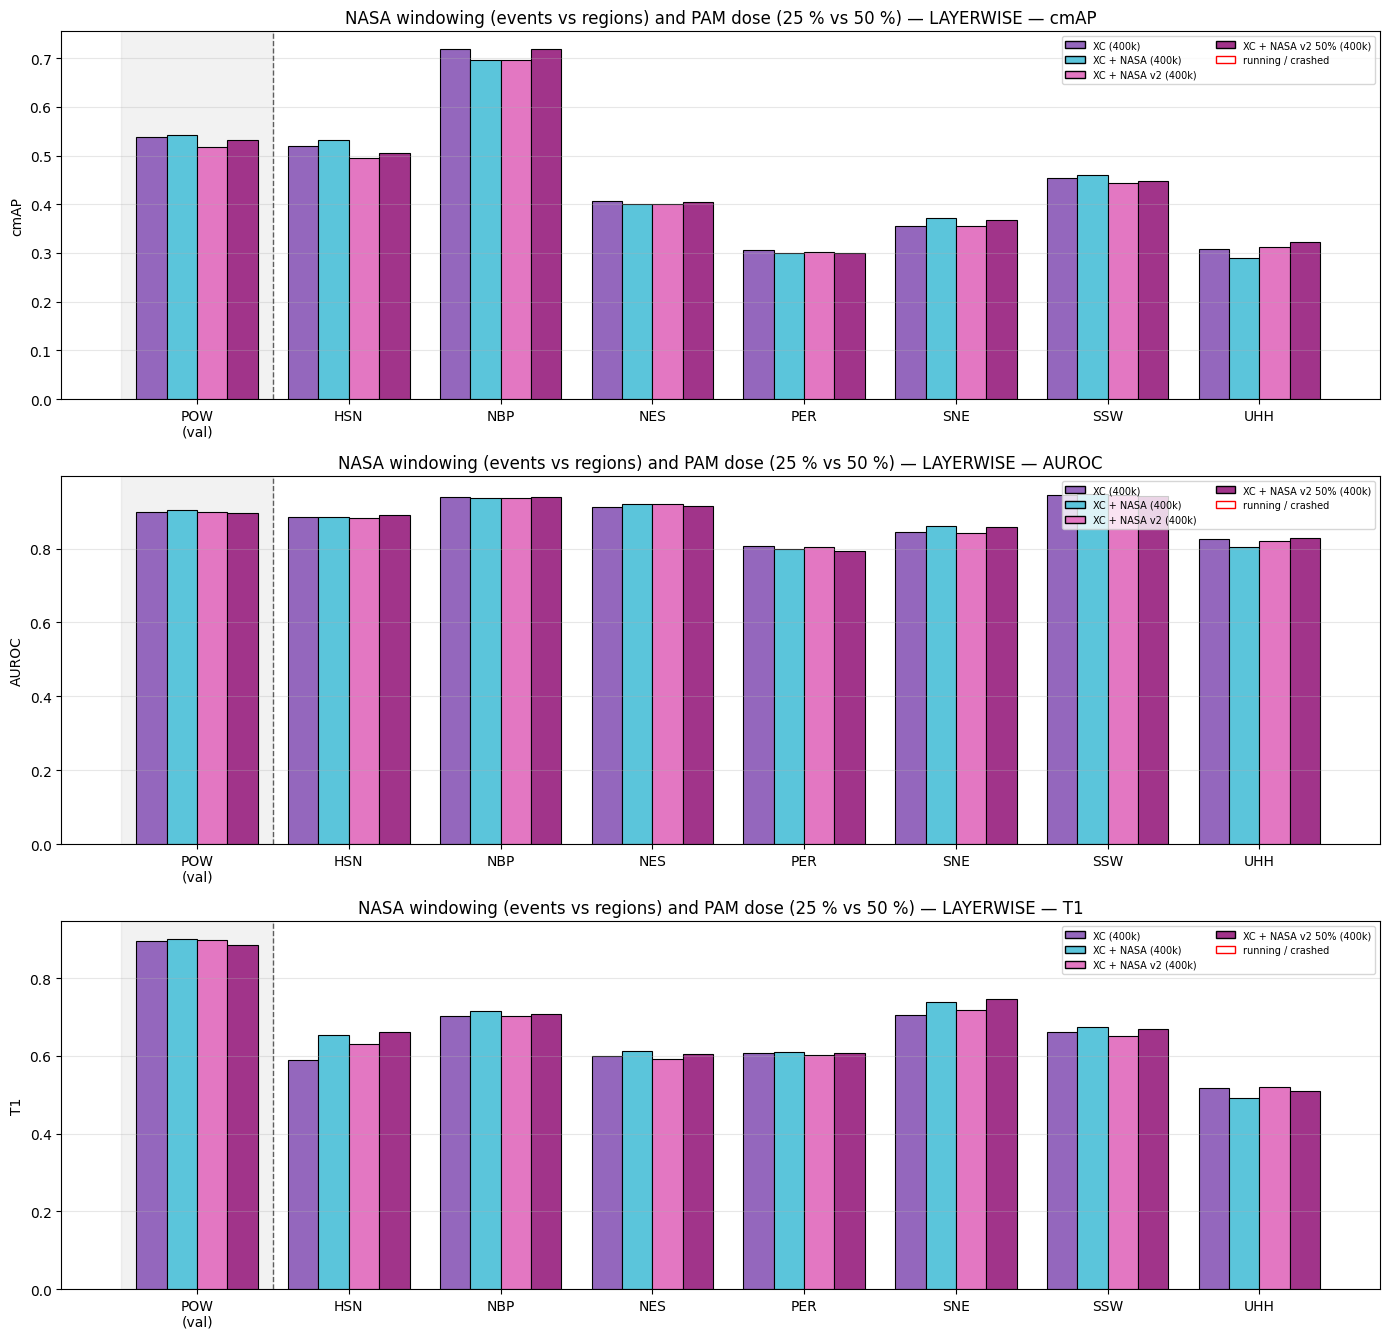

In [25]:
bar_plot(win_tables, win_states, win_ranges, WINDOWING,
         "NASA windowing (events vs regions) and PAM dose (25 % vs 50 %) — LAYERWISE")

In [26]:
# The contrasts this section exists for, using the section-3 machinery so the rows
# are directly comparable to the 2x2 (and to its noise floor of |Δ| <= 0.001 cmAP
# on the test mean):
#   three `+NASA` rows — each soundscape arm against the XC-only control of equal
#                        length, which is the only row that answers "does adding
#                        this soundscape help?"
#   `events -> regions` — the single-factor windowing change at fixed 25 % weight
#   `25% -> 50%`        — the single-factor dose change at fixed region store
# `events -> regions 50%` is deliberately absent: it moves both factors at once.
WIN_CONTRASTS = [
    ("+NASA", "events      | vs XC (400k)", XC_400K,         XC_NASA_400K),
    ("+NASA", "regions     | vs XC (400k)", XC_400K,         XC_NASA_400K_V2),
    ("+NASA", "regions 50% | vs XC (400k)", XC_400K,         XC_NASA_400K_V2_50),
    ("windowing", "events -> regions",      XC_NASA_400K,    XC_NASA_400K_V2),
    ("dose", "regions 25% -> 50%",          XC_NASA_400K_V2, XC_NASA_400K_V2_50),
]
win_decomp = pd.DataFrame(
    [_contrast(win_tables, a, b) for _, _, a, b in WIN_CONTRASTS],
    index=pd.MultiIndex.from_tuples([(f, lbl) for f, lbl, _, _ in WIN_CONTRASTS],
                                    names=["factor", "contrast"]))
win_decomp.columns = pd.MultiIndex.from_tuples(win_decomp.columns)
print("marginal effects on the test-set mean (POW excluded)")
print(win_decomp.round(4).to_string())

# POW is the val set and excluded above, but it is the one in-domain-ish subset and
# the checkpoint-selection metric, so it is worth naming separately here.
print("\nPOW (val), cmAP:",
      {b: round(win_tables["cmAP"].loc["POW", b], 4) for b in WINDOWING})


marginal effects on the test-set mean (POW excluded)
                                        cmAP        AUROC           T1     
                                       delta wins   delta wins   delta wins
factor    contrast                                                         
+NASA     events      | vs XC (400k) -0.0029  3/7 -0.0005  4/7  0.0158  6/7
          regions     | vs XC (400k) -0.0096  1/7 -0.0014  2/7  0.0047  3/7
          regions 50% | vs XC (400k) -0.0008  2/7  0.0010  5/7  0.0177  5/7
windowing events -> regions          -0.0067  2/7 -0.0009  2/7 -0.0111  1/7
dose      regions 25% -> 50%          0.0088  6/7  0.0024  4/7  0.0130  6/7

POW (val), cmAP: {'XC (400k)': np.float64(0.5377), 'XC + NASA (400k)': np.float64(0.5414), 'XC + NASA v2 (400k)': np.float64(0.5176), 'XC + NASA v2 50% (400k)': np.float64(0.5312)}


### Reading section 9

**The repetition asymmetry was not what made NASA null.** Cutting the
distinct-view repeat rate from ~330× to ~76×, with the curated granule set, the
mix weights, the schedule and the initialisation all held fixed, moves the test
mean the *wrong* way: `events → regions` is **−0.007 cmAP (3/7)**, and against the
XC-only control of the same length the region arm is **−0.010 (1/7)** where the
event arm is −0.003 (3/7). Both are still small — a few times the ±0.001
probe-seed floor and well under the 0.014 cmAP two XC-only runs differ by on
initialisation alone (section 3, `init`) — so the honest summary is that **v2 is
not an improvement, and NASA is inert-to-diluting under either windowing at 25 %
weight**. The
1/7 win count is the part that is hard to read as noise: only one test dataset
prefers the region store to the plain XC backbone.

Two details worth keeping:

* **POW moves furthest, and downward** — 0.518 for `v2` against 0.541 for the
  event arm and 0.538 for XC-only. POW is the validation set used to pick
  checkpoints, so a windowing change that costs 0.023 cmAP there is not a neutral
  reshuffling of the same data. The 50 % arm sits at 0.531, i.e. it recovers
  about half of that.
* **The layer-fusion profile barely moves**
  (`birdset_layer_weights_nasa.ipynb` §3, which covers the two 25 % arms).
  Test-mean centroids sit at 9.85 (XC only), 9.60 (events) and 9.79 (regions) of
  12 — a smaller spread than the 8.5–10.2 the external encoders and the 1M runs
  cover — so this is not the probe
  reading a differently shaped encoder. The features live at the same depth and
  are simply slightly worse on BirdSet.

**More PAM beats less PAM, and that is the clearest row in the section.** The dose
step from 25 % to 50 % on the same region store is worth **+0.009 cmAP (6/7),
+0.005 AUROC (6/7) and +0.012 T1 (6/7)** — the only contrast here that moves all
three metrics the same way with a win count that is not a coin flip, and ~9× the
±0.001 probe-seed floor on cmAP. It buys back what the windowing change cost:
against the XC-only control the 50 % arm is at parity on cmAP (−0.0006, 2/7) and
slightly ahead on the other two (AUROC +0.005 at 6/7, T1 +0.013 at 5/7), where the
region arm at 25 % was −0.010 cmAP (1/7).

**But cmAP is not monotone in PAM weight, so this is not a dose–response.**
0.4389 (no PAM) → 0.4290 (25 %) → 0.4383 (50 %). If the 25 % deficit were XC being
diluted, the 50 % arm — where XC falls to ~13 repeats per distinct view against
~20 — would have to be worse again, and it is the best of the three NASA arms. The
whole spread of the NASA arms against the control (−0.010 to −0.001 cmAP) also sits
inside the **0.014 cmAP** that two XC-only runs differ by on initialisation alone
(section 3, `init`), so with one pretraining run per cell the cmAP column cannot
separate these arms at all. The AUROC and T1 gains at 50 %, consistent at 6/7 and
5/7, are the part that looks like signal rather than spread. The T1 gain it shares
with the event arm (+0.012, 5/7); the AUROC gain is the only one any NASA arm here
has shown at all — the two 25 % arms are +0.0008 (4/7) and +0.0005 (3/7).

What this rules out and what it leaves. It rules out the cheapest mechanical
explanation of the NASA null — that the fixed-window store was starving the model
of distinct views — which was worth spending a run on precisely because it was
cheap to test and would have been an easy fix. It leaves the dose axis open in the
useful direction: 50 % is the highest PAM weight run so far, it is the best of the
NASA arms, and nothing here says the curve has turned over. It also leaves the
framing question untouched: BirdSet is a focal-recording
benchmark, and every arm here is being asked whether soundscape data helps on
focal audio.


## 10. Layerwise finetuning — the layerwise head with the encoder unfrozen

Section 7 unfroze the encoder under the **final-layer** prototype head. This
section does the same thing under the **layerwise** head
(`configs/experiment/sweeps/finetune/birdset/vit_layerwise.yaml`): `ViTProtoLayerwise`
with `module.freeze_backbone: false`, and nothing else changed from the frozen
layerwise probe of sections 2–3 — same transforms, same `base_lr` 3e-4 · 256/256,
`prototype_lr` / `layer_weights_lr` 1e-2, `layer_decay` 0.75, `drop_path` 0.1,
20 prototypes, 1250 steps at batch 256, bf16. So each of the two contrasts below
moves exactly one thing:

| contrast | what changes |
| --- | --- |
| `layerwise` → `layerwise-finetune` | the encoder becomes trainable |
| `finetune` → `layerwise-finetune` | the readout goes from the last block to a learned mix of all 12 |

`XC (1M)` and `XC + NASA (1M)`, seed 1, all 8 datasets. With the backbone
unfrozen `param_groups_lrd` applies its 0.75^(13−layer_id) decay to the encoder
while the prototypes and the 12 fusion weights keep their own fixed LRs.

**These runs are the only ones in the notebook on BirdSet's official label
spaces.** They were launched after the 2026-08-20 NES/PER/SNE repair, so they
score 89/132/56 classes there where every other head scores 88/131/55. That makes
them the right rows for the published comparison in section 11 — and it means the
NES/PER/SNE head deltas in this section are not pure head effects. The four other
tasks (HSN, NBP, SSW, UHH) and POW are unaffected.

In [27]:
# === SECTION 10: layerwise finetuning ===
lwft_tables, lwft_states, lwft_ranges = tables(lw_finetune_df, NEW_HEAD_BACKBONES)
print("Run states (red-edged bars below are still running):")
print(lwft_states.to_string())
print()
print(summary(lwft_tables, "layerwise-finetune").to_string())
print()
# `n_classes` is a per-(dataset, head) property, identical across the two
# backbones, so one value per dataset is taken rather than reindexed on a
# duplicated index.
def _n_classes(df, backbones=NEW_HEAD_BACKBONES):
    return (df[df["backbone"].isin(backbones)]
            .groupby("dataset")["n_classes"].first())


print("label space these runs scored (data.num_classes), vs the frozen layerwise probe:")
print(pd.DataFrame({"layerwise-finetune": _n_classes(lw_finetune_df),
                    "layerwise": _n_classes(layerwise_df),
                    "OFFICIAL": pd.Series(OFFICIAL_N_CLASSES)})
      .reindex(DATASETS).astype("Int64").to_string())
lwft_tables["cmAP"].round(4)

Run states (red-edged bars below are still running):
backbone   XC (1M) XC + NASA (1M)
dataset                          
POW       finished       finished
HSN       finished       finished
NBP       finished       finished
NES       finished       finished
PER       finished       finished
SNE       finished       finished
SSW       finished        running
UHH       finished       finished

                                                    cmAP   AUROC      T1
layerwise-finetune (test-set mean, POW excluded)                        
XC (1M)                                           0.4669  0.8866  0.6695
XC + NASA (1M)                                    0.4595  0.8865  0.6655

label space these runs scored (data.num_classes), vs the frozen layerwise probe:
     layerwise-finetune  layerwise  OFFICIAL
POW                  48         48        48
HSN                  21         21        21
NBP                  51         51        51
NES                  89         88        89
PER    

backbone,XC (1M),XC + NASA (1M)
dataset,,
POW,0.5473,0.5512
HSN,0.5421,0.5451
NBP,0.7724,0.7571
NES,0.4299,0.4171
PER,0.3379,0.3227
SNE,0.3705,0.3664
SSW,0.4754,0.4792
UHH,0.3402,0.3293


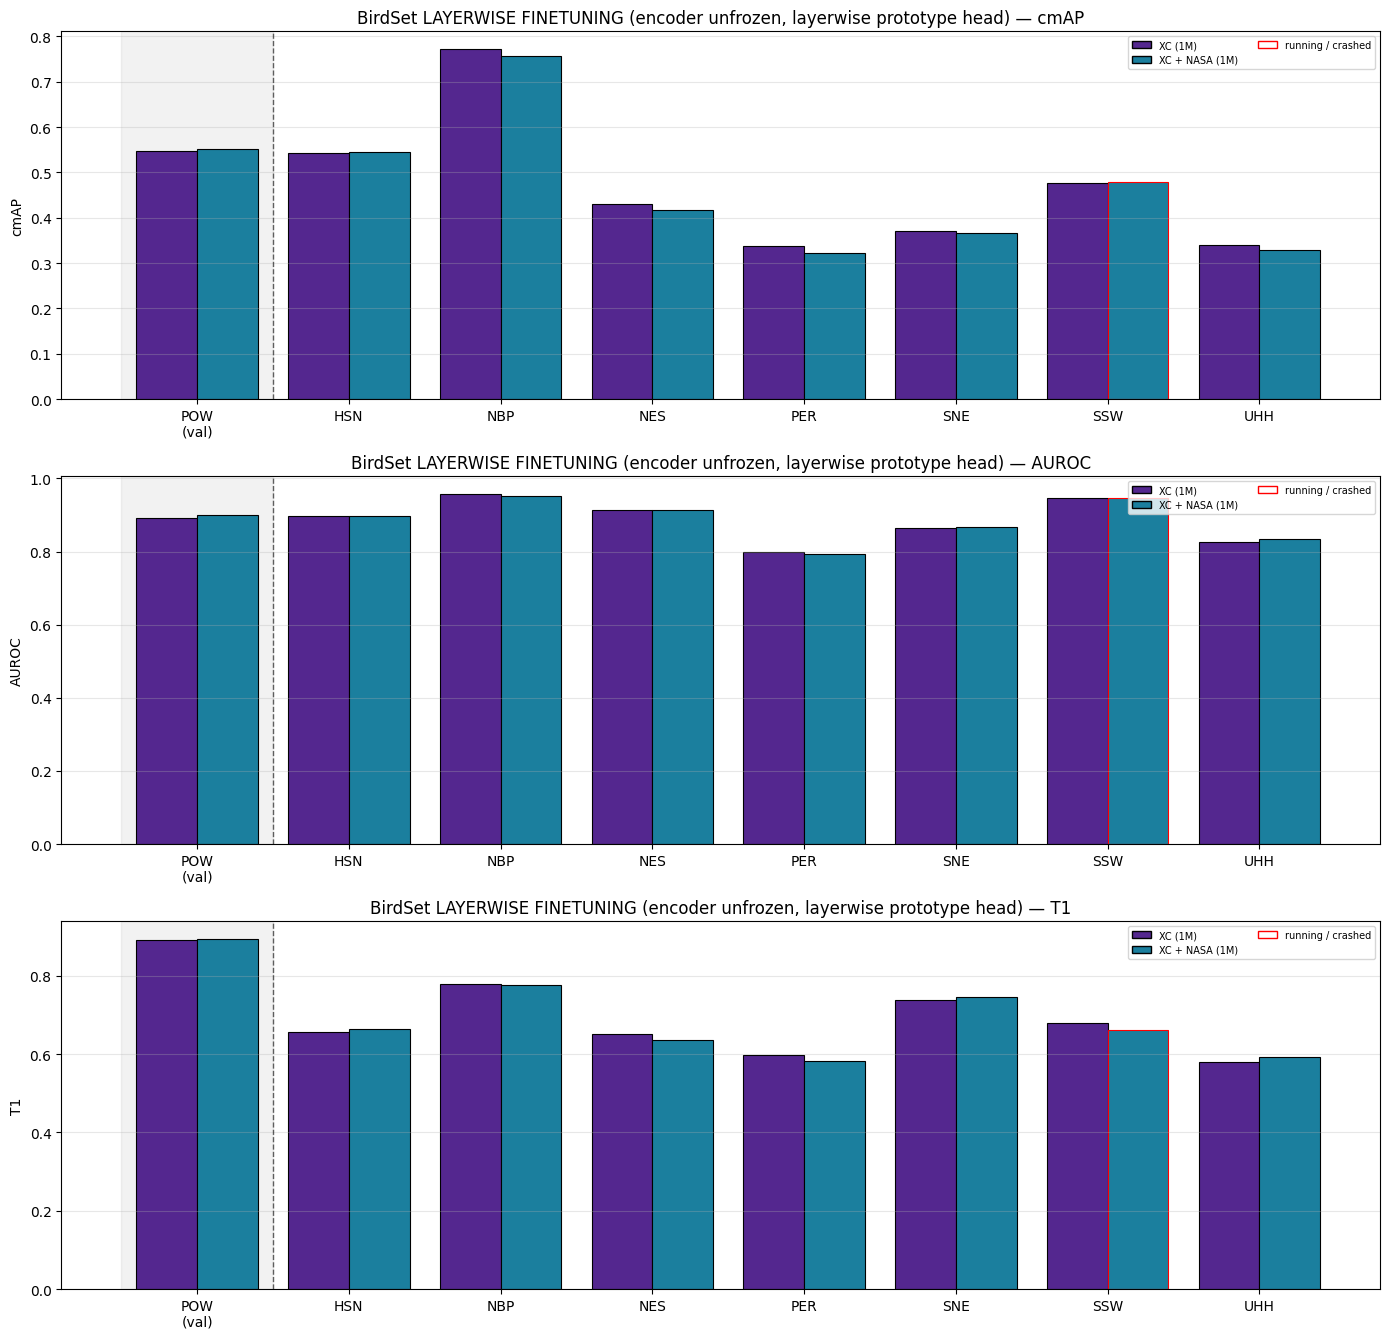

In [28]:
bar_plot(lwft_tables, lwft_states, lwft_ranges, NEW_HEAD_BACKBONES,
         "BirdSet LAYERWISE FINETUNING (encoder unfrozen, layerwise prototype head)")

In [29]:
# The two single-factor contrasts this section exists for, per backbone, using the
# section-3 `_contrast` machinery so the rows read against the same noise floor
# (|delta| <= 0.001 cmAP on the test mean, measured on the layerwise probe seeds).
#   `unfreeze`  layerwise      -> layerwise-finetune : the encoder becomes trainable
#   `readout`   finetune       -> layerwise-finetune : last block -> learned mix of 12
# `_by_head` slices the (backbone, head) column product down to head columns for a
# single backbone, which is the shape `_contrast` wants.
LWFT_HEADS = ["layerwise", "finetune", "layerwise-finetune"]
_all_heads = head_tables(NEW_HEAD_BACKBONES, LWFT_HEADS)[0]


def _by_head(backbone):
    return {m: _all_heads[m].xs(backbone, level="backbone", axis=1) for m in METRICS}


rows, index = [], []
for backbone in NEW_HEAD_BACKBONES:
    t = _by_head(backbone)
    rows.append(_contrast(t, "layerwise", "layerwise-finetune"))
    index.append(("unfreeze", f"layerwise -> lw-finetune | {backbone}"))
    rows.append(_contrast(t, "finetune", "layerwise-finetune"))
    index.append(("readout", f"finetune -> lw-finetune | {backbone}"))
# And the question every section asks, now under the new head.
rows.append(_contrast(lwft_tables, XC_1M, XC_NASA_1M))
index.append(("NASA", "+NASA | 1M steps, lw-finetune"))
lwft_decomp = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(
    index, names=["factor", "contrast"]))
lwft_decomp.columns = pd.MultiIndex.from_tuples(lwft_decomp.columns)
print("marginal effects on the test-set mean (POW excluded)")
print(lwft_decomp.round(4).to_string())
print("\nNOTE — the `unfreeze` and `readout` rows include the NES/PER/SNE "
      "label-space change\n(89/132/56 vs 88/131/55); the `NASA` row does not, "
      "since both its cells are post-repair.")
print("\nPOW (val), cmAP:", {b: round(lwft_tables["cmAP"].loc["POW", b], 4)
                              for b in NEW_HEAD_BACKBONES})

marginal effects on the test-set mean (POW excluded)
                                                      cmAP        AUROC           T1     
                                                     delta wins   delta wins   delta wins
factor   contrast                                                                        
unfreeze layerwise -> lw-finetune | XC (1M)         0.0065  4/7 -0.0055  2/7  0.0103  5/7
readout  finetune -> lw-finetune | XC (1M)          0.0035  6/7  0.0001  4/7  0.0040  5/7
unfreeze layerwise -> lw-finetune | XC + NASA (1M)  0.0025  3/7  0.0011  4/7 -0.0012  4/7
readout  finetune -> lw-finetune | XC + NASA (1M)  -0.0012  2/7 -0.0033  2/7 -0.0047  3/7
NASA     +NASA | 1M steps, lw-finetune             -0.0074  2/7 -0.0001  5/7 -0.0040  3/7

NOTE — the `unfreeze` and `readout` rows include the NES/PER/SNE label-space change
(89/132/56 vs 88/131/55); the `NASA` row does not, since both its cells are post-repair.

POW (val), cmAP: {'XC (1M)': np.float64(0.5473), 'XC

In [30]:
# Same two contrasts restricted to the four TEST datasets whose label space did NOT
# change (HSN, NBP, SSW, UHH), so `unfreeze` and `readout` are pure head effects.
# This is the clean version of the table above; it trades three datasets for the
# removal of the only confound in it.
# "Clean" = the frozen layerwise probe already scored the official class count on
# that dataset, so the repair did not move it and the head contrast is pure.
_probe_n = _n_classes(layerwise_df)
CLEAN_DATASETS = [d for d in TEST_DATASETS if _probe_n[d] == OFFICIAL_N_CLASSES[d]]
print(f"label space unchanged by the 2026-08-20 repair: {CLEAN_DATASETS}")
print(f"excluded (repaired): {[d for d in TEST_DATASETS if d not in CLEAN_DATASETS]}\n")


def _clean_contrast(tabs, a, b):
    out = {}
    for m in METRICS:
        d = tabs[m].loc[CLEAN_DATASETS, b] - tabs[m].loc[CLEAN_DATASETS, a]
        out[(m, "delta")] = d.mean()
        out[(m, "wins")] = f"{int((d > 0).sum())}/{len(CLEAN_DATASETS)}"
    return out


rows, index = [], []
for backbone in NEW_HEAD_BACKBONES:
    t = _by_head(backbone)
    rows.append(_clean_contrast(t, "layerwise", "layerwise-finetune"))
    index.append(("unfreeze", f"layerwise -> lw-finetune | {backbone}"))
    rows.append(_clean_contrast(t, "finetune", "layerwise-finetune"))
    index.append(("readout", f"finetune -> lw-finetune | {backbone}"))
clean = pd.DataFrame(rows, index=pd.MultiIndex.from_tuples(
    index, names=["factor", "contrast"]))
clean.columns = pd.MultiIndex.from_tuples(clean.columns)
print(f"marginal effects on the mean of {CLEAN_DATASETS} — no label-space confound")
clean.round(4)

label space unchanged by the 2026-08-20 repair: ['HSN', 'NBP', 'SSW', 'UHH']
excluded (repaired): ['NES', 'PER', 'SNE']

marginal effects on the mean of ['HSN', 'NBP', 'SSW', 'UHH'] — no label-space confound


cmAP        AUROC       \
                                                     delta wins   delta wins   
factor   contrast                                                              
unfreeze layerwise -> lw-finetune | XC (1M)         0.0132  3/4 -0.0008  1/4   
readout  finetune -> lw-finetune | XC (1M)          0.0047  4/4 -0.0009  2/4   
unfreeze layerwise -> lw-finetune | XC + NASA (1M)  0.0113  3/4  0.0014  3/4   
readout  finetune -> lw-finetune | XC + NASA (1M)  -0.0021  1/4 -0.0034  1/4   

                                                        T1       
                                                     delta wins  
factor   contrast                                                
unfreeze layerwise -> lw-finetune | XC (1M)         0.0231  3/4  
readout  finetune -> lw-finetune | XC (1M)          0.0072  3/4  
unfreeze layerwise -> lw-finetune | XC + NASA (1M)  0.0120  3/4  
readout  finetune -> lw-finetune | XC + NASA (1M)  -0.0048  2/4

In [31]:
# --- Removing the label-space confound instead of dropping three datasets ---
# The runs log per-class AP (`test_AP_per_class/{gbifID}`, `configs/module/metrics/
# map_per_class.yaml`), so the repair can be undone arithmetically: recompute the
# class mean over the 88/131/55 classes the frozen probes scored, by dropping the
# ONE class the 2026-08-20 repair restored. That makes the `unfreeze` / `readout`
# contrasts comparable on all 7 test datasets, rather than on the 4 unaffected ones.
#
# Only cmAP can be corrected this way — it is a mean over per-class APs, so a class
# can be removed from it. AUROC and T1 are not per-class means in this logging, so
# they keep the confound and the 4-dataset table above stays the clean read for them.
RESTORED_CLASS = {"NES": 5231482,   # runwre1, Campylorhynchus rufinucha
                  "PER": 5228935,   # scbwoo5, Celeus grammicus
                  "SNE": 9568685}   # pasfly,  Empidonax difficilis


def _cmap_excluding_restored(run_id, dataset):
    """cmAP of one run recomputed WITHOUT the class the repair restored."""
    ap = {k.rsplit("/", 1)[1]: v
          for k, v in api.run(f"{ENTITY}/{PROJECT}/{run_id}").summary.items()
          if k.startswith("test_AP_per_class/")}
    drop = str(RESTORED_CLASS[dataset])
    assert drop in ap, f"{dataset}: class {drop} not logged by {run_id}"
    return float(np.mean([v for k, v in ap.items() if k != drop]))


rows = []
for _, r in lw_finetune_df[lw_finetune_df["dataset"].isin(RESTORED_CLASS)].iterrows():
    corrected = _cmap_excluding_restored(r["run_ids"][-1], r["dataset"])
    rows.append({"dataset": r["dataset"], "backbone": r["backbone"],
                 "n_classes": r["n_classes"], "cmAP (as run)": r["cmAP"],
                 "AP of restored class": None, "cmAP (repair undone)": corrected,
                 "correction": corrected - r["cmAP"]})
correction = pd.DataFrame(rows).drop(columns="AP of restored class")
print("cmAP of the three repaired tasks, recomputed on the pre-repair class set")
print(correction.set_index(["dataset", "backbone"]).round(4).to_string())

# Apply it: a cmAP-only copy of the layerwise-finetune table on the old class set.
_corr = correction.set_index(["dataset", "backbone"])["correction"]
lwft_cmap_corr = lwft_tables["cmAP"].copy()
for (ds, b), v in _corr.items():
    lwft_cmap_corr.loc[ds, b] = lwft_tables["cmAP"].loc[ds, b] + v

_probe_cmap = tables(layerwise_df, NEW_HEAD_BACKBONES)[0]["cmAP"]
_ft_cmap = ft_tables["cmAP"]
out = {}
for b in NEW_HEAD_BACKBONES:
    ours = lwft_cmap_corr.loc[TEST_DATASETS, b]
    out[(b, "unfreeze  (vs layerwise)")] = ours - _probe_cmap.loc[TEST_DATASETS, b]
    out[(b, "readout   (vs finetune)")] = ours - _ft_cmap.loc[TEST_DATASETS, b]
corr_contrast = pd.DataFrame(out)
corr_contrast.loc["TEST MEAN"] = corr_contrast.mean()
corr_contrast.loc["wins"] = [f"{int((corr_contrast.loc[TEST_DATASETS, c] > 0).sum())}/7"
                             for c in corr_contrast.columns]
print("\ncmAP delta on all 7 test datasets, label-space confound removed")
print(corr_contrast.round(4).to_string())
print("\ntest-mean cmAP on the pre-repair class set (comparable to sections 2-3, 7):")
print(lwft_cmap_corr.loc[TEST_DATASETS].mean().round(4).to_string())

cmAP of the three repaired tasks, recomputed on the pre-repair class set
                        n_classes  cmAP (as run)  cmAP (repair undone)  correction
dataset backbone                                                                  
NES     XC (1M)                89         0.4299                0.4347      0.0048
PER     XC (1M)               132         0.3379                0.3397      0.0018
SNE     XC (1M)                56         0.3705                0.3728      0.0023
NES     XC + NASA (1M)         89         0.4171                0.4216      0.0045
PER     XC + NASA (1M)        132         0.3227                0.3244      0.0017
SNE     XC + NASA (1M)         56         0.3664                0.3681      0.0018

cmAP delta on all 7 test datasets, label-space confound removed
                           XC (1M)                                   XC + NASA (1M)                        
          unfreeze  (vs layerwise) readout   (vs finetune) unfreeze  (vs layerwise) readou

### Reading section 10

**Unfreezing the encoder under the layerwise head is the best cell in the
notebook, and it is still a small effect.** `XC (1M)` reaches cmAP **0.4669** on
the official label spaces, or **0.4682** once the repair is undone so it sits on
the same class set as sections 2–3 and 7. Against that basis:

* **`unfreeze` (frozen layerwise probe → layerwise finetune): +0.0077 cmAP (4/7)**
  on `XC (1M)`, **+0.0036 (3/7)** on `XC + NASA (1M)`. On the four datasets the
  label-space repair never touched (HSN, NBP, SSW, UHH) it reads larger — +0.0132
  and +0.0112, 3/4 each, though `SSW` on `XC + NASA (1M)` is still running there —
  and it costs AUROC on `XC (1M)` (**−0.0055, 2/7**) while
  gaining T1 (+0.0103, 5/7). Training 86M parameters for 1250 steps buys ~0.01 cmAP
  over reading the same weights frozen.
* **`readout` (final-layer finetune → layerwise finetune): +0.0048 cmAP (6/7)** on
  `XC (1M)` and **−0.0000 (2/7)** on `XC + NASA (1M)`. The win count is the
  interesting half: 6/7 and 4/4 on the unaffected subset, i.e. small but almost
  everywhere. Fusing all 12 blocks still helps a *trainable* encoder, which is not
  obvious — finetuning could have specialised the last block and made the fusion
  redundant.
* **The per-dataset pattern is not uniform.** `unfreeze` on `XC (1M)` is +0.029
  (UHH), +0.018 (NBP), +0.012 (NES), +0.008 (HSN) but −0.002 (SSW), −0.004 (SNE),
  −0.007 (PER). PER finetuning below its own frozen probe is the same signature
  section 7 flagged: an LR inherited from a probing recipe is too high for the
  smaller, harder tasks.
* **POW gets clearly worse.** 0.5473 / 0.5512 against **0.5865 / 0.5718** for the
  frozen layerwise probe — −0.039 on `XC (1M)`. POW is the validation set used to
  pick checkpoints and the one task where finetuning consistently loses to probing,
  under both finetuning heads (section 7 reads 0.5439 there).
* **NASA is still negative, and this is its largest margin under any head:**
  **−0.0075 cmAP (2/7)**, with AUROC flat (−0.0001, 5/7) and T1 −0.0040 (3/7). Both
  cells of that row are post-repair, so it is the one contrast in this section with
  no label-space caveat at all. Sections 3, 5, 7 and 9 all land in the
  same place; unfreezing the encoder does not give the soundscape data a route to
  pay off on BirdSet either.

**One cell is still running.** `SSW` on `XC + NASA (1M)` had not finished when this
was last executed (red edge in the plot, `running` in the state table), so every
number in the `XC + NASA (1M)` column — and the NASA row — will move slightly on the
next run. The `XC (1M)` column is complete.

**On the noise floor.** The ±0.001 cmAP figure from section 3 is a *probe*-seed
floor measured on a frozen backbone. These runs train the encoder, so their
run-to-run spread is unmeasured and can only be larger. Read +0.008 and +0.005
as "small and consistently signed", not as resolved effects — the win counts and
the agreement between the 7-dataset and 4-dataset versions are doing more work here
than the magnitudes.

**On the label-space correction.** The repair adds one genuinely hard class to each
of NES/PER/SNE — its AP is 0.005 (NES), 0.101 (PER), 0.245 (SNE), all well under
those tasks' cmAP — so scoring it *lowers* cmAP by 0.002–0.005 there. The
confound therefore runs against the new head, and the uncorrected `unfreeze` row
(+0.0065) understates it. The correction is arithmetic on logged per-class APs, not
a re-run, and it only applies to cmAP; AUROC and T1 keep the confound, which is why
the four-dataset table stays the clean read for those two.

## 11. Our finetuning against the published state of the art

Section 10's `layerwise-finetune` runs are the right rows to put next to the
literature, for one specific reason: they are the only sweep in this notebook that
scores **BirdSet's official label spaces** on all eight tasks (21 / 48 / 132 / 89 /
27 / 51 / 81 / 56 — the counts in Bird-MAE's own Table 2). Every other head is one
class short on NES/PER/SNE.

**What is being compared, and what is not.** The `{TASK}-test_5s` splits and the
metric implementations are shared, so the *right-hand side* of the comparison is
like-for-like. Three things are not:

* **Bird-MAE-B / Bird-MAE-L (FT)** — arXiv:2504.12880, Table 6 (MAP%) and Table 11
  (AUROC, T1). Genuine full fine-tuning of an XCL-1.7M-pretrained MAE. `-B` is the
  matched reference: ViT-B/16, 86M, Xeno-Canto, MAE — the same four choices we
  made. `-L` at 307M is the paper's headline. Caveat theirs: **HSN is their
  validation set** (`HSN_val` in their tables), tuned on, whereas it is a test set
  for us and for Perch 2.0.
* **Perch 2.0** — arXiv:2508.04665, Table 4, the `Random` variant. **Not a
  fine-tune**: a supervised EfficientNet-B3 trained on XC + iNaturalist +
  Tierstimmenarchiv + FSD50K whose prototype-learning head is applied to BirdSet
  as-is ("we forgo fine-tuning"). It is here because it is the number to beat, not
  because the protocol matches. Its POW column does not exist — POW is its
  validation set, as it is ours — and its published means are over exactly our
  seven `TEST_DATASETS`.
* **Ours** — the *test* split is BirdSet's, but the **train** split is not:
  `configs/data/datasets/train/birdset/*.yaml` builds each task's training set from
  our own Xeno-Canto v0.2.0 snapshot filtered to that task's species (`split: all`,
  whole recordings, no event extraction), where BirdSet's official recipe uses its
  XCL-derived, event-detected train split. Same species, same idea, different
  audio and a newer snapshot. So these are not leaderboard-legal numbers — read
  them as "our recipe lands in this band", not as a ranked entry.

Read the AUROC and T1 rows alongside cmAP rather than under it. Perch 2.0's own
paper argues ROC-AUC is the most stable BirdSet metric, and it is also where the
two published references and our runs disagree most.

**A frozen row joins this panel.** Section 12's block-diagonal probe is the same
prototypical layerwise head with the mixer's off-block weights pinned to zero and the
encoder left **frozen**. It is here because it has the same admission ticket as
section 10's runs — BirdSet's official label spaces on all eight tasks — which makes
it the first *frozen* readout in the notebook that can be set next to these published
numbers with no label-space caveat. The last paragraph of this section already argued
from the dense frozen probe that finetuning is barely part of our result; these two
rows are that argument on a clean label space. In the plot they are the pale shade of
their encoder's colour.

In [33]:
# === SECTION 11: vs published fine-tuning SOTA ===
# Our two `layerwise-finetune` backbones, the two block-diagonal FROZEN probes of
# section 12, and the three published reference series.
#
# Why a frozen probe is allowed into a finetuning panel. This section's admission
# ticket is BirdSet's official label spaces on all eight tasks, and the
# block-diagonal runs have them for the same reason section 10's do — they were
# launched after the 2026-08-20 repair. The dense layerwise probes are deliberately
# NOT added: on NES/PER/SNE they average an 89-class seed with an 88-class one, which
# is exactly the mixing this section exists to avoid. And the last paragraph of this
# section is the substantive reason to want a frozen row here at all — unfreezing the
# encoder is worth only ~0.008 cmAP (section 10), so the published FT numbers are not
# really being beaten by finetuning.
BD_SOTA_SERIES = [f"{b} {BLOCKDIAG}" for b in NEW_HEAD_BACKBONES]
SOTA_SERIES = FT_SOTA_SERIES + NEW_HEAD_BACKBONES + BD_SOTA_SERIES
sota_tables, sota_states, sota_ranges = tables(
    pd.concat([sota_df, lw_finetune_df,
               mix_df[mix_df["backbone"].isin(BD_SOTA_SERIES)]], ignore_index=True),
    SOTA_SERIES)

print("Run states ('reference' = a published number, not a run of ours):")
print(sota_states.to_string())
print()
print(summary(sota_tables, "finetuning vs published SOTA").to_string())
print("\nPOW is the val set and excluded from the means above; Perch 2.0 has no "
      "POW number\nat all (POW is their validation set too), which is why its POW "
      "cell is NaN.\nThe two `block-diag` rows are FROZEN layerwise probes "
      "(section 12), not finetunes.")
sota_tables["cmAP"].round(4)

Run states ('reference' = a published number, not a run of ours):
backbone Bird-MAE-B (paper, FT) Bird-MAE-L (paper, FT) Perch 2.0 (paper, pretrained head)   XC (1M) XC + NASA (1M) XC (1M) block-diag XC + NASA (1M) block-diag
dataset                                                                                                                                                        
POW                   reference              reference                          reference  finished       finished           finished                  finished
HSN                   reference              reference                          reference  finished       finished           finished                  finished
NBP                   reference              reference                          reference  finished       finished           finished                  finished
NES                   reference              reference                          reference  finished       finished           finished 

backbone,"Bird-MAE-B (paper, FT)","Bird-MAE-L (paper, FT)","Perch 2.0 (paper, pretrained head)",XC (1M),XC + NASA (1M),XC (1M) block-diag,XC + NASA (1M) block-diag
dataset,,,,,,,
POW,0.4524,0.5526,NaN,0.5473,0.5512,0.5939,0.5838
HSN,0.5206,0.5528,0.533,0.5421,0.5451,0.5028,0.5280
NBP,0.6286,0.7169,0.661,0.7724,0.7571,0.7457,0.7412
NES,0.3712,0.4150,0.403,0.4299,0.4171,0.4140,0.4072
PER,0.2758,0.3464,0.232,0.3379,0.3227,0.3687,0.3481
SNE,0.2804,0.3382,0.341,0.3705,0.3664,0.3964,0.3819
SSW,0.3283,0.4082,0.469,0.4754,0.4790,0.4866,0.4887
UHH,0.2848,0.3017,0.380,0.3402,0.3293,0.2999,0.3138


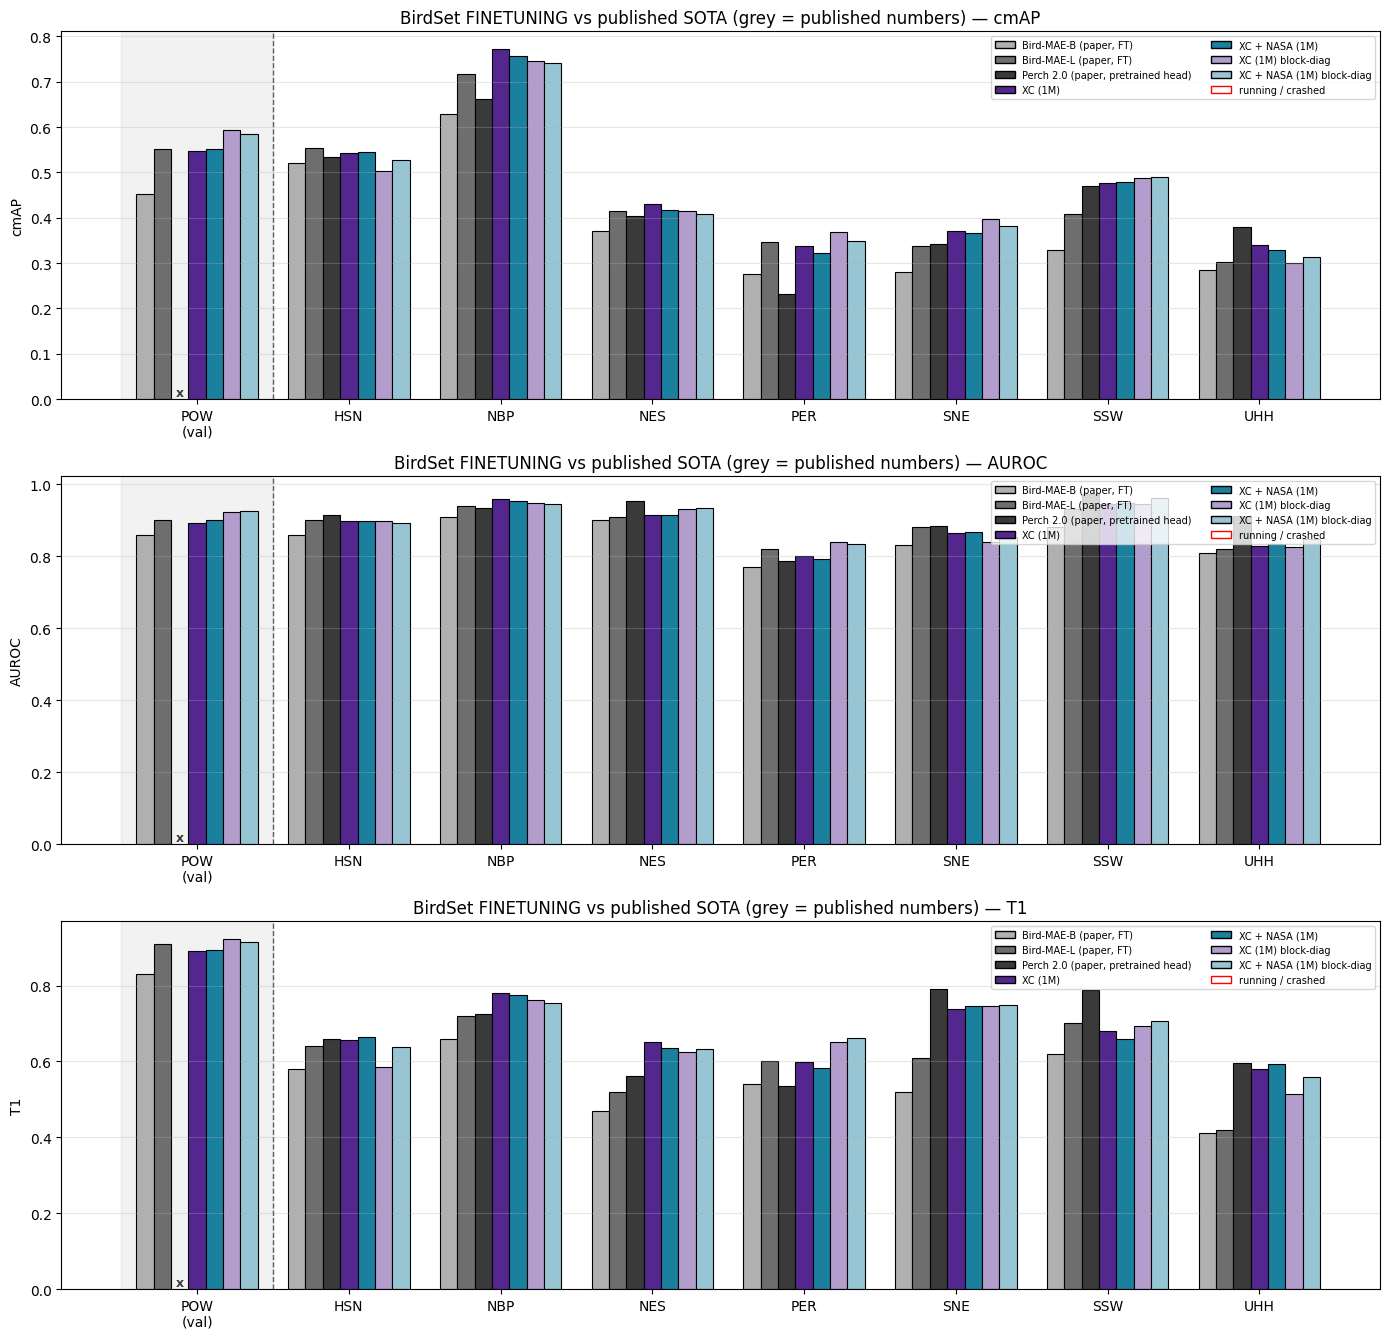

In [34]:
bar_plot(sota_tables, sota_states, sota_ranges, SOTA_SERIES,
         "BirdSet FINETUNING vs published SOTA (grey = published numbers)")

In [35]:
# Our best finetune and our best frozen block-diagonal probe against each published
# series, on the test-set mean and per dataset. `wins` counts the 7 test datasets we
# are ahead on. HSN is broken out separately because it is Bird-MAE's validation set,
# so their HSN number is the one row of theirs that is not a clean held-out score.
OURS_BEST = XC_1M                     # the stronger backbone under every head so far
OURS_BD = f"{XC_1M} {BLOCKDIAG}"      # the same encoder, frozen, block-diagonal mixer
OURS = [OURS_BEST, OURS_BD]
OURS_LABEL = {OURS_BEST: f"{XC_1M} lw-finetune",
              OURS_BD: f"{XC_1M} block-diag (frozen)"}

rows, index = [], []
for ours in OURS:
    for ref in FT_SOTA_SERIES:
        rec = {}
        for m in METRICS:
            mine = sota_tables[m].loc[TEST_DATASETS, ours]
            theirs = sota_tables[m].loc[TEST_DATASETS, ref]
            d = (mine - theirs).dropna()
            rec[(m, "ours")] = mine.reindex(d.index).mean()
            rec[(m, "theirs")] = theirs.reindex(d.index).mean()
            rec[(m, "delta")] = d.mean()
            rec[(m, "wins")] = f"{int((d > 0).sum())}/{len(d)}"
        rows.append(rec)
        index.append(f"{OURS_LABEL[ours]}  vs  {ref}")
vs = pd.DataFrame(rows, index=index)
vs.columns = pd.MultiIndex.from_tuples(vs.columns)
print("test-set mean (POW excluded), on the datasets both series report")
print(vs.round(4).to_string())

print("\nper-dataset cmAP delta, ours minus theirs (positive = we are ahead)")
for ours in OURS:
    print(f"\n{OURS_LABEL[ours]}")
    print(pd.DataFrame({ref: sota_tables["cmAP"][ours] - sota_tables["cmAP"][ref]
                        for ref in FT_SOTA_SERIES}).reindex(DATASETS).round(4).to_string())

# The two rows of ours, head to head: what unfreezing 86M parameters is worth against
# what constraining the mixer is worth, on the one label space both of them score.
print("\nours vs ours — lw-finetune minus block-diag (frozen), test-set mean")
print(pd.DataFrame({
    m: {"lw-finetune": sota_tables[m].loc[TEST_DATASETS, OURS_BEST].mean(),
        "block-diag (frozen)": sota_tables[m].loc[TEST_DATASETS, OURS_BD].mean(),
        "delta": (sota_tables[m].loc[TEST_DATASETS, OURS_BEST]
                  - sota_tables[m].loc[TEST_DATASETS, OURS_BD]).mean()}
    for m in METRICS}).round(4).to_string())

print("\nHSN alone — Bird-MAE tuned hyperparameters on HSN, so read their HSN "
      "number as a\nvalidation score and the six remaining test datasets as the "
      "fair subset:")
_no_hsn = [d for d in TEST_DATASETS if d != "HSN"]
print(pd.DataFrame({
    m: {s: sota_tables[m].loc[_no_hsn, s].mean() for s in SOTA_SERIES}
    for m in METRICS}).round(4).to_string())

test-set mean (POW excluded), on the datasets both series report
                                                                       cmAP                        AUROC                           T1                     
                                                                       ours  theirs   delta wins    ours  theirs   delta wins    ours  theirs   delta wins
XC (1M) lw-finetune  vs  Bird-MAE-B (paper, FT)                      0.4669  0.3842  0.0827  7/7  0.8866  0.8514  0.0352  7/7  0.6695  0.5429  0.1266  7/7
XC (1M) lw-finetune  vs  Bird-MAE-L (paper, FT)                      0.4669  0.4399  0.0270  5/7  0.8866  0.8857  0.0009  4/7  0.6695  0.6014  0.0680  5/7
XC (1M) lw-finetune  vs  Perch 2.0 (paper, pretrained head)          0.4669  0.4313  0.0356  6/7  0.8866  0.9079 -0.0213  2/7  0.6695  0.6650  0.0045  3/7
XC (1M) block-diag (frozen)  vs  Bird-MAE-B (paper, FT)              0.4592  0.3842  0.0749  6/7  0.8887  0.8514  0.0373  7/7  0.6538  0.5429  0.1110  7/7
XC (1

### Reading section 11

**Our recipe lands in the published SOTA band on cmAP and T1, and below it on
AUROC.** `XC (1M)` layerwise-finetuned, test-set mean over the seven tasks
(POW excluded, matching Perch 2.0's own means):

| | cmAP | AUROC | T1 |
| --- | --- | --- | --- |
| **`XC (1M)` lw-finetune (ours)** | **0.4669** | 0.8866 | 0.6695 |
| `XC + NASA (1M)` lw-finetune (ours) | 0.4595 | 0.8864 | 0.6650 |
| `XC (1M)` block-diag, **frozen** (ours) | 0.4592 | 0.8887 | 0.6538 |
| `XC + NASA (1M)` block-diag, **frozen** (ours) | 0.4584 | 0.8950 | **0.6713** |
| Bird-MAE-L (FT), 307M | 0.4399 | 0.8857 | 0.6014 |
| Perch 2.0 (pretrained head), EffNet-B3 | 0.4313 | **0.9079** | 0.6650 |
| Bird-MAE-B (FT), 86M — the matched arm | 0.3842 | 0.8514 | 0.5429 |

The first two rows are fine-tunes (section 10); the two `block-diag` rows are
**frozen** probes (section 12), in the panel because they share section 10's
official-label-space ticket.

* **Against `Bird-MAE-B (FT)`, the like-for-like arm** — same ViT-B/16, same 86M,
  same Xeno-Canto MAE pretraining — we are **+0.083 cmAP, +0.035 AUROC, +0.127 T1,
  all at 7/7 datasets**. That is the largest gap in the table and the one with the
  fewest confounds on the model side.
* **Against `Bird-MAE-L (FT)`, the paper's headline at 3.6× the parameters:**
  **+0.027 cmAP (5/7)** and **+0.068 T1 (5/7)**, with AUROC a dead heat (+0.0009,
  4/7). We are ahead on NBP (+0.056), SSW (+0.067), UHH (+0.039), SNE (+0.032),
  NES (+0.015) and behind on HSN (−0.011) and PER (−0.009). Dropping HSN — which is
  Bird-MAE's *validation* set, tuned on — widens it: 0.4544 vs 0.4211 over the
  remaining six.
* **Against `Perch 2.0`, the number to beat:** **+0.036 cmAP (6/7)** and T1 level
  (+0.005, 3/7), but **−0.021 AUROC (2/7)**. Per dataset we are ahead everywhere
  except UHH (−0.040), with the biggest margins on NBP (+0.111) and PER (+0.106).
  Perch's own paper argues ROC-AUC is the most stable BirdSet metric, and that is
  the one column where it stays clearly ahead of everything here.
* **The frozen block-diagonal probe lands in the same band as the fine-tunes**, which
  is the sharpest form of this section's last point. `XC (1M) block-diag` reads cmAP
  **0.4592** with the encoder never updated: **+0.019 (4/7)** over `Bird-MAE-L (FT)`,
  **+0.028 (5/7)** over Perch 2.0, **+0.075 (6/7)** over the matched `Bird-MAE-B (FT)`
  — and **+0.0030 AUROC** over Bird-MAE-L where our own finetune manages +0.0009. On
  `XC + NASA (1M)` the frozen probe is the best row in the whole table on **AUROC
  (0.8950)** and **T1 (0.6713)**, ahead of both of our fine-tunes. Its one real
  weakness is **HSN**, the only cell where a row of ours falls behind all three
  references (−0.050 vs Bird-MAE-L, −0.030 vs Perch) — the same HSN cost section 12
  measures for this head, landing on the one task Bird-MAE tuned on.

**The honest reading of that cmAP/AUROC split.** A large cmAP lead paired with an
AUROC deficit is what a *training-set* advantage looks like, not a representation
advantage: cmAP is a mean over per-class APs and rewards having seen enough of each
rare class, while AUROC is far less sensitive to that. Our train split is **not
BirdSet's** — each task's training set is built from our own Xeno-Canto v0.2.0
snapshot filtered to that task's species (whole recordings, `split: all`, no event
detection), where the official recipe uses BirdSet's XCL-derived, event-detected
split from an older snapshot. Same species, more and newer audio, especially for
the rare classes that dominate cmAP. So these rows are **not leaderboard-legal**,
and the cmAP margins should be read as "our recipe reaches this band" rather than
as a ranking.

**Finetuning is barely part of the result.** Our best *frozen* layerwise probe
already reads cmAP **0.4604** (section 3) — above Bird-MAE-L's fine-tuned 0.4399
and Perch 2.0's 0.4313 — and unfreezing the encoder adds only the +0.008 of
section 10. The `block-diag` rows now make that claim with no label-space asterisk
on it: **0.4592 frozen against 0.4669 finetuned** on the same encoder and on
BirdSet's official class counts on all eight tasks, a **+0.0078 cmAP** gain that
costs **−0.0021 AUROC**. Whatever puts us in this band, it is the prototypical layerwise readout
plus the train split, not 1250 steps of finetuning. That also means the comparison
is somewhat unfair in the other direction: Bird-MAE fine-tunes with a mean-pooled
linear head, so their FT row and ours differ in head as well as in weights.

**And NASA changes nothing here either.** `XC + NASA (1M)` is 0.0074 cmAP below
`XC (1M)` and flat on AUROC (−0.0002): the same null-to-negative NASA reading every
other section reports, now measured at the point where our numbers are at their
strongest. Under the frozen block-diagonal head it is −0.0008 cmAP and +0.0063
AUROC, i.e. it stops being negative without becoming positive — read that against
section 12's per-task deltas, not as a NASA gain.

**Provenance.** Bird-MAE numbers: arXiv:2504.12880, Table 6 (MAP%) and Table 11
(AUROC / T1-Acc, published to 2 dp). Perch 2.0: arXiv:2508.04665, Table 4, the
`Random` variant — the best of its three on all three metrics; `Phase I` and
`Peak-select` are within 0.001 cmAP (0.431 / 0.430) and within 0.006 AUROC. Perch's
tables also list `Audio ProtoPNet-5` at cmAP 0.423 (Table 3; its Table 4
per-dataset row means 0.424) / AUROC 0.896 / T1 0.623,
between Bird-MAE-L and Perch 2.0 on cmAP, and re-reports Bird-MAE-L (FT) rounded to
0.440 / 0.886 / 0.601 — consistent with the Bird-MAE tables used here.

## 12. The block-diagonal mixer — measuring the constraint the release head had to make

Every prototypical probe above uses the **dense** mixer: one
`nn.Linear(20·C → C)`, so each class's logit is a learned combination of *every*
prototype in the pool. That is quadratic in the class count — `20·C² + C` readout
weights — and it means prototypes are not really assigned to classes at all: at
PER's 132 classes each class reads 2 640 prototypes, of which the 20 laid out in
its own block are 0.8 %.

The full-XC release head could not keep it. At Xeno-Canto's 11 737 taxa the dense
mixer is **2.755 B parameters**, so `PrototypicalFloat` grew a `block_diagonal`
option: each class scores only its own 20 prototypes (`class_weight` `(C, 20)` plus
a bias), which is the standard PPNet formulation and `21·C` weights instead of
`20·C² + C`. Prototypes are laid out class-major, so the constraint is exactly the
dense mixer with every off-block weight pinned to zero — a strict subset of it, not
a different head.

**That constraint was never measured.** At BirdSet scale both mixers fit, so this
section runs the one experiment the release model cannot run on itself:
`configs/experiment/sweeps/layerwise/birdset/vit_blockdiag.yaml` is the layerwise
probe of sections 2–3 with `mixer: block_diagonal` as the only config change — same
encoders, same 20 prototypes per class, same `layer_norm`, same frozen backbone,
same 1250-step recipe, same seed. `proto_chunk` is deliberately left `null` so even
the compute path matches the dense probes.

**Coverage.** Three encoders, seed 1: `XC (400k)` on 7 of 8 tasks (HSN never ran),
`XC (1M)` and `XC + NASA (1M)` on all 8.

**Label spaces are clean here, and that is new.** These runs were launched after the
2026-08-20 NES/PER/SNE repair, and so were the seed-1 dense probes they are read
against (2026-08-19 for `XC (400k)`, 2026-08-21 for the two 1M encoders), so both
arms score 89/132/56 on those three tasks. The cell below asserts that rather than
trusting it — and it is what lets these runs into **section 11**, which admits only
the repaired era. It is also why they are pulled in their own cell next to the
loader, **seed 1 only**: the seed-averaged `layerwise_df` used everywhere above
averages a seed-1 post-repair run with a seed-2 pre-repair run on NES/PER/SNE for
the two 1M encoders, so its cmAP there is not taken over one class set.

One caveat is left standing rather than resolved: the block-diagonal runs were
launched from a newer working tree than their dense references (they log
`trainer.resume_from_state`, which the dense runs do not), and an uncommitted change
to how weight decay is applied to head parameters may therefore sit inside the
`dense → block-diag` contrast. Separating the two would need a dense re-probe on the
current tree.

In [36]:
# === SECTION 12: the block-diagonal mixer vs the dense mixer ===
# `mix_df` is pulled next to the main loader, because section 11 needs it too; the
# comment there is where the "why it cannot come through `HEADS`" and the "seed 1
# only" reasoning live.
_cols = pd.MultiIndex.from_product([BD_BACKBONES, [DENSE, BLOCKDIAG]])
print("run state per (dataset, encoder, mixer):")
print(mix_df.pivot_table(index="dataset", columns=["encoder", "mixer"],
                         values="state", aggfunc="first")
            .reindex(index=DATASETS, columns=_cols).fillna("—").to_string())
print("\nthe dense arm this is read against, by date (all post-repair on NES/PER/SNE):")
print(mix_df.pivot_table(index="dataset", columns=["encoder", "mixer"],
                         values="created", aggfunc="first")
            .reindex(index=DATASETS, columns=_cols).apply(
                lambda s: s.dt.strftime("%Y-%m-%d")).fillna("—").to_string())

# The one thing that would silently invalidate the whole contrast: the two mixers
# scoring a different number of classes on the same task. Both arms ran after the
# 2026-08-20 repair, so every cell should be at BirdSet's official count — asserted
# rather than assumed, because a mismatch is invisible in the numbers themselves.
_nc = (mix_df.pivot_table(index="dataset", columns=["encoder", "mixer"],
                          values="n_classes", aggfunc="first")
             .reindex(index=DATASETS, columns=_cols))
print("\ndata.num_classes per (dataset, encoder, mixer):")
print(_nc.astype("Int64").to_string())
print("\nBirdSet official:", {d: OFFICIAL_N_CLASSES[d] for d in DATASETS})
_bad = [d for d in DATASETS if set(_nc.loc[d].dropna()) - {OFFICIAL_N_CLASSES[d]}]
assert not _bad, f"label space is not the official one on {_bad}"
print("\nevery cell scores the official label space -> the mixer contrast below is a "
      "pure head\ncontrast, with no label-space era folded into it. It is also what "
      "lets the\nblock-diagonal probe into section 11, which admits only the repaired "
      "era.")

# What the constraint actually saves. `prototype_vectors` is (20*C, 768) in both arms
# and identical; only the mixer differs. The last row is the release head, and the
# reason `block_diagonal` exists at all.
_C = pd.Series(OFFICIAL_N_CLASSES).reindex(DATASETS)
XC_TAXA = 11_737     # configs/experiment/xc_classifier/vit_layerwise.yaml
readout = pd.DataFrame({"classes": _C, "dense": 20 * _C**2 + _C, "block_diag": 21 * _C})
readout.loc["XC-all"] = [XC_TAXA, 20 * XC_TAXA**2 + XC_TAXA, 21 * XC_TAXA]
readout["ratio"] = (readout["dense"] / readout["block_diag"]).round(1)
print("\nmixer parameters (the prototypes themselves are the same in both arms):")
print(readout.astype({"classes": int, "dense": int, "block_diag": int}).to_string())

run state per (dataset, encoder, mixer):
        XC (400k)              XC (1M)            XC + NASA (1M)           
            dense block-diag     dense block-diag          dense block-diag
dataset                                                                    
POW      finished   finished  finished   finished       finished   finished
HSN      finished          —  finished   finished       finished   finished
NBP      finished   finished  finished   finished       finished   finished
NES      finished   finished  finished   finished       finished   finished
PER      finished   finished  finished   finished       finished   finished
SNE      finished   finished  finished   finished       finished   finished
SSW      finished   finished  finished   finished       finished   finished
UHH      finished   finished  finished   finished       finished   finished

the dense arm this is read against, by date (all post-repair on NES/PER/SNE):
          XC (400k)                 XC (1M) 

In [37]:
mix_tables, mix_states, mix_ranges = tables(mix_df, BD_SERIES)
print(summary(mix_tables, "dense vs block-diagonal mixer").to_string())
print("\nCAREFUL with the two `XC (400k)` rows above: its block-diagonal arm has no "
      "HSN run, so\nthat mean is over 6 test datasets and its dense partner's over "
      "7. The contrast table\nbelow drops the unpaired cells instead.")
mix_tables["cmAP"].round(4)

                                                               cmAP   AUROC      T1
dense vs block-diagonal mixer (test-set mean, POW excluded)                        
XC (400k) dense                                              0.4386  0.8804  0.6263
XC (400k) block-diag                                         0.4272  0.8846  0.6403
XC (1M) dense                                                0.4607  0.8925  0.6571
XC (1M) block-diag                                           0.4592  0.8887  0.6538
XC + NASA (1M) dense                                         0.4569  0.8856  0.6671
XC + NASA (1M) block-diag                                    0.4584  0.8950  0.6713



CAREFUL with the two `XC (400k)` rows above: its block-diagonal arm has no HSN run, so
that mean is over 6 test datasets and its dense partner's over 7. The contrast table
below drops the unpaired cells instead.


backbone,XC (400k) dense,XC (400k) block-diag,XC (1M) dense,XC (1M) block-diag,XC + NASA (1M) dense,XC + NASA (1M) block-diag
dataset,,,,,,
POW,0.5377,0.5471,0.5809,0.5939,0.5708,0.5838
HSN,0.5202,NaN,0.5364,0.5028,0.5346,0.5280
NBP,0.7192,0.7215,0.7526,0.7457,0.7413,0.7412
NES,0.4067,0.4011,0.4174,0.4140,0.4169,0.4072
PER,0.3068,0.3272,0.3470,0.3687,0.3306,0.3481
SNE,0.3556,0.3695,0.3832,0.3964,0.3831,0.3819
SSW,0.4541,0.4492,0.4763,0.4866,0.4771,0.4887
UHH,0.3079,0.2947,0.3123,0.2999,0.3148,0.3138


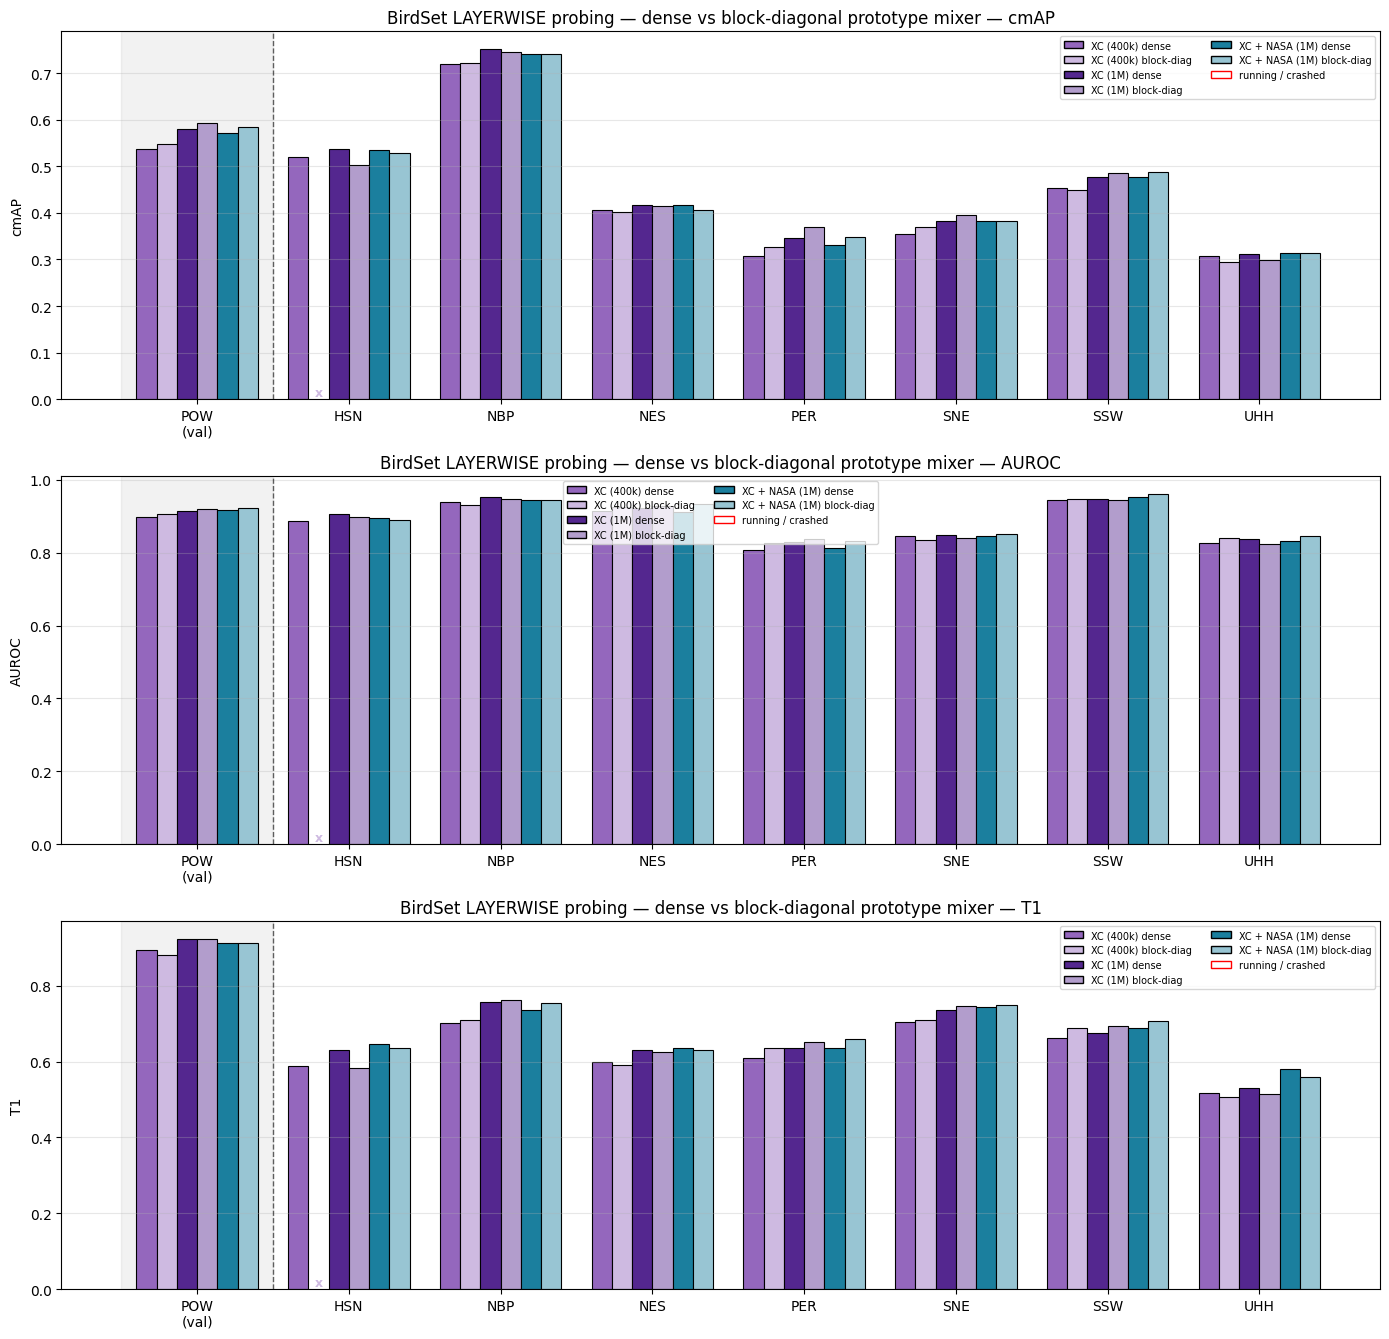

In [38]:
bar_plot(mix_tables, mix_states, mix_ranges, BD_SERIES,
         "BirdSet LAYERWISE probing — dense vs block-diagonal prototype mixer")

In [39]:
# The contrast the section exists for: block-diagonal minus dense, per encoder, on
# the test-set mean (POW excluded, as everywhere). Unpaired cells are DROPPED rather
# than counted — `XC (400k)` has no block-diagonal HSN run, so its row is over 6 test
# datasets and both of its means are recomputed on that same 6, which is why this
# table and not `summary` above is the readable one.
def _mixer_contrast(encoder):
    out = {}
    for m in METRICS:
        dense = mix_tables[m].loc[TEST_DATASETS, f"{encoder} {DENSE}"]
        block = mix_tables[m].loc[TEST_DATASETS, f"{encoder} {BLOCKDIAG}"]
        d = (block - dense).dropna()
        out[(m, "dense")] = dense.reindex(d.index).mean()
        out[(m, "block")] = block.reindex(d.index).mean()
        out[(m, "delta")] = d.mean()
        out[(m, "wins")] = f"{int((d > 0).sum())}/{len(d)}"
    return out


mix_decomp = pd.DataFrame([_mixer_contrast(b) for b in BD_BACKBONES], index=BD_BACKBONES)
mix_decomp.columns = pd.MultiIndex.from_tuples(mix_decomp.columns)
mix_decomp.index.name = "encoder — block-diag vs dense, test-set mean"
print("marginal effect of the mixer constraint, on the datasets both arms ran")
print(mix_decomp.round(4).to_string())
print("\nfor scale: the probe-seed noise floor is |delta| <= 0.001 cmAP on the test "
      "mean (section 3),\nand two XC-only 400k runs differ by 0.014 cmAP on "
      "initialisation alone (section 3, `init`).")

# Per dataset, because the test mean hides that this is not a uniform shift — and
# POW is included here (it is excluded from the means, but it is the checkpoint-
# selection metric, so a head that moves it is worth seeing).
print("\nper-dataset delta (block-diag - dense); POW is the val set:")
for m in METRICS:
    print(f"\n{m}")
    print(pd.DataFrame({b: mix_tables[m][f"{b} {BLOCKDIAG}"] - mix_tables[m][f"{b} {DENSE}"]
                        for b in BD_BACKBONES}).reindex(DATASETS).round(4).to_string())

# Does the mixer change the NASA answer? Every other section reports null-to-negative
# for the NASA mix; if the constrained head reversed that, it would matter.
print("\n(XC + NASA) - (XC) at 1M steps, under each mixer — the section-3 NASA row, "
      "re-read:")
print(pd.DataFrame({
    mx: {m: (mix_tables[m].loc[TEST_DATASETS, f"{XC_NASA_1M} {mx}"]
             - mix_tables[m].loc[TEST_DATASETS, f"{XC_1M} {mx}"]).mean()
         for m in METRICS}
    for mx in (DENSE, BLOCKDIAG)}).round(4).to_string())

marginal effect of the mixer constraint, on the datasets both arms ran
                                                cmAP                        AUROC                           T1                     
                                               dense   block   delta wins   dense   block   delta wins   dense   block   delta wins
encoder — block-diag vs dense, test-set mean                                                                                       
XC (400k)                                     0.4250  0.4272  0.0022  3/6  0.8795  0.8846  0.0052  4/6  0.6323  0.6403  0.0079  4/6
XC (1M)                                       0.4607  0.4592 -0.0016  3/7  0.8925  0.8887 -0.0038  2/7  0.6571  0.6538 -0.0033  4/7
XC + NASA (1M)                                0.4569  0.4584  0.0015  2/7  0.8856  0.8950  0.0094  6/7  0.6671  0.6713  0.0042  4/7

for scale: the probe-seed noise floor is |delta| <= 0.001 cmAP on the test mean (section 3),
and two XC-only 400k runs differ by 0.014 c

### Reading section 12

**The constraint is free on the mean.** Block-diagonal minus dense on the test-set
mean, seed 1, paired on the datasets both arms ran:

| encoder | cmAP | AUROC | T1 |
| --- | --- | --- | --- |
| `XC (400k)` (6 tasks — no block-diag HSN) | **+0.0022** (3/6) | +0.0052 (4/6) | +0.0079 (4/6) |
| `XC (1M)` | **−0.0016** (3/7) | −0.0038 (2/7) | −0.0033 (4/7) |
| `XC + NASA (1M)` | **+0.0015** (2/7) | +0.0094 (6/7) | +0.0042 (4/7) |

Three encoders, three different signs, every cmAP row inside ±0.002. That is two or
three times the ±0.001 probe-seed floor and about a seventh of the 0.014 cmAP two
XC-only 400k runs differ by on initialisation alone (section 3, `init`), so the
headline question answers cleanly: **pinning the off-block mixer weights to zero —
95 % of the mixer at 21-class HSN, 99.2 % at 132-class PER — does not cost
measurable accuracy on BirdSet.** That is what the release head needed. The same
cell shows what it buys: at 11 737 XC taxa the dense mixer it replaces would be
2.755 B parameters against 246 k here, an 11 178× reduction, for no measurable loss.

**The zero on the mean is cancellation, not absence.** Averaged over the encoders
that ran each task, sorted by class count:

| task | classes | mean Δ cmAP | sign across encoders |
| --- | --- | --- | --- |
| HSN | 21 | −0.020 | 0+/2− |
| UHH | 27 | −0.009 | 0+/3− |
| POW (val) | 48 | +0.012 | 3+/0− |
| NBP | 51 | −0.002 | 1+/2− |
| SNE | 56 | +0.009 | 2+/1− |
| SSW | 81 | +0.006 | 2+/1− |
| NES | 89 | −0.006 | 0+/3− |
| PER | 132 | +0.020 | 3+/0− |

`PER` gains ~+0.02 cmAP on all three encoders and `POW` ~+0.012 on all three, while
`HSN` and `UHH` lose on every encoder that ran them. Single-factor per-task effects
reproduced across three different frozen backbones are not seed noise. Spearman
between class count and the mean delta is **+0.75** over the seven test sets, which
fits a plain mechanism: the dense mixer is a free readout over a shared
over-complete prototype pool and grows as `20·C²` while the budget stays at 1250
steps, so on the many-class tasks it is the *head* that overfits and constraining it
helps, while on 21-class HSN the extra 8 841-weight readout is cheap and genuinely
useful. `NES` at 89 classes is the counterexample — negative on all three encoders —
so read the trend as a hint, not a law.

**Two consequences worth carrying forward.**

* **POW moves, and POW picks checkpoints.** +0.0094 / +0.0131 / +0.0131 cmAP on the
  three encoders, positive every time. The validation signal this project selects on
  shifts with the head even where the test mean does not, which is the same warning
  section 9 raised from the other direction.
* **It redistributes exactly the two tasks section 11 is behind on.** `HSN` and
  `PER` are the only test sets where our layerwise finetune trails `Bird-MAE-L (FT)`,
  and this head moves them in opposite directions: PER +0.0217, HSN −0.0335 on
  `XC (1M)`. No conclusion in the notebook changes, but where the per-task strength
  sits does.

**And it does not rescue NASA.** Section 3's NASA row re-read under the new head:
−0.0008 cmAP against −0.0038 dense, +0.0063 AUROC against −0.0070, +0.0175 T1
against +0.0100, at 1M steps. cmAP moves from small-negative to indistinguishable
from zero and AUROC changes sign, but neither reaches the size a real data effect
would need — the same null-to-negative reading as sections 3, 5, 8, 9 and 11, now
under a fifth head.

**What this section does not separate.** The block-diagonal runs were launched from a
newer working tree than their dense references, which also carries an uncommitted
change to head-parameter weight decay (`prototype_vectors` exempted from decay, the
head split into decay / no-decay groups). So every delta above is "block-diagonal
head as it runs today vs dense head as it ran in August", not the mixer in
isolation. A dense re-probe on the current tree is what would close that; it has not
been run.